In [3]:
import pandas as pd
import numpy as np
import datetime
import sys
from tqdm.auto import tqdm
sys.path.append("/var/www/python/Prod/nighthawk/")
sys.path.append("/var/www/python/Qingcheng/Darwin/")

from nighthawk.util import dataframe_functions, sql_functions, bigquery_functions
from utils_darwin import ve_portfolio_constructor_darwin
from nighthawk.data.network import node

import re

from nighthawk.data.pipeline.var_handler import loadwindgen_vh, wind_vh
from multiprocessing import Pool
from tqdm import tqdm
import gc
import cvxpy as cp
from itertools import groupby
from collections import defaultdict

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)

In [4]:

opexchange = 'SPP'
start_dt = '2020-01-01'
end_dt = '2026-08-04'

file_loc = '/mnt/disks/filedisk2a/Jessica/portfolio_analysis/portfolio_scaling_up_2025/'

In [2]:

dataset_name = 'spp'
bids_table_name = 'darwin_v2_bids_table'
# temp_bids_table_name = 'temp_darwin_v2_bids_table'
bids_table_bkt_name = 'darwin_v2_bids_table_with_bkts'
physical_var_bkt_table_name = 'darwin_v2_physical_variable_bkt_table'
bids_overall_table_name = 'darwin_v2_bids_overall'
prediction_table_name = 'darwin_v2_prediction'

# segment_combined_bids_table_bkt_name = 'darwin_v2_segment_combined_bids_table_with_bkts'


## prepare darwin prediction table, reference table, nogo table, holdout table

In [68]:

def get_darwin_prediction(opexchange, start_dt, end_dt, quantile_table_darwin, backtest=False): 
    if opexchange == 'SPP':
        y_list_str = "'rt_total', 'da_total'"
    else:
        y_list_str = "'rt_total_da_total'"

    quantiles = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85,
                         0.9, 0.95, 0.97, 0.99]
    chosen_quantile_phrase = ['_q%d' % (ql * 100) for ql in quantiles]
    
    darwin_select_str = """
                        d.dt,hr,node_num,
                        rt_total_mean, da_total_mean,
                        rt_total_q1,rt_total_q3,rt_total_q5,rt_total_q10,rt_total_q15,rt_total_q20,rt_total_q30,rt_total_q40,rt_total_q50,rt_total_q60,rt_total_q70,rt_total_q80,rt_total_q85,rt_total_q90,rt_total_q95,rt_total_q97,rt_total_q99,
                        da_total_q1,da_total_q3,da_total_q5,da_total_q10,da_total_q15,da_total_q20,da_total_q30,da_total_q40,da_total_q50,da_total_q60,da_total_q70,da_total_q80,da_total_q85,da_total_q90,da_total_q95,da_total_q97,da_total_q99
    """
    darwin_select_str = ','.join(
        ['d.dt', 'hr', 'node_num'] + ['rt_total_mean', 'da_total_mean'] + [
            re.sub(r'\W +', '', x) for x in darwin_select_str.split(',') for qp in chosen_quantile_phrase
            if
            re.sub(r'\W +', '', x).endswith(qp)])

    if backtest: 
        darwin_query = f"""
                SELECT {darwin_select_str}
                     FROM {quantile_table_darwin} as d 
                WHERE d.dt >= '{start_dt}' and d.dt <= '{end_dt}'
                            and d.keep_list = 'All' and d.y_list in ({y_list_str})
        """
    else:
        darwin_query = f"""
                        SELECT {darwin_select_str}
                             FROM {quantile_table_darwin} as d 
                             INNER JOIN 
                             (SELECT dt, max(run_number) as run_number FROM {quantile_table_darwin} as d2 WHERE d2.dt >= '{start_dt}' and d2.dt <= '{end_dt}' GROUP BY dt) rn
                             ON d.dt = rn.dt AND d.run_number = rn.run_number
                        WHERE d.dt >= '{start_dt}' and d.dt <= '{end_dt}'
                                    and d.keep_list = 'All' and d.y_list in ({y_list_str})
        """
    darwin_df = bigquery_functions.download_df_from_bq(darwin_query)
    darwin_df['dt'] = darwin_df['dt'].astype(str)
    darwin_df['hr'] = darwin_df['hr'].astype(int)
    darwin_df['node_num'] = darwin_df['node_num'].astype(int)
    darwin_df = darwin_df.groupby(['dt', 'hr', 'node_num']).max().reset_index()

    return darwin_df

In [69]:
quantile_table_darwin = 'movetocloud-999.Darwin_Production.SPP_prediction'
darwin_df_1 = get_darwin_prediction(opexchange, start_dt, end_dt, quantile_table_darwin)

quantile_table_darwin = 'movetocloud-999.Darwin_Production.SPP_prediction_original'
darwin_df_2 = get_darwin_prediction(opexchange, start_dt, end_dt, quantile_table_darwin)

quantile_table_darwin = 'movetocloud-999.Darwin.SPP_prediction'
darwin_df_3 = get_darwin_prediction(opexchange, start_dt, end_dt, quantile_table_darwin, backtest=True)

dt_df = pd.concat([darwin_df_2[['dt']].drop_duplicates().assign(priority=1), 
darwin_df_1[['dt']].drop_duplicates().assign(priority=2), 
darwin_df_3[['dt']].drop_duplicates().assign(priority=3)]).drop_duplicates('dt', keep='first')

darwin_df = pd.concat([dt_df.loc[dt_df['priority'] == 1, ['dt']].merge(darwin_df_2), 
dt_df.loc[dt_df['priority'] == 2, ['dt']].merge(darwin_df_1), 
dt_df.loc[dt_df['priority'] == 3, ['dt']].merge(darwin_df_3)])
darwin_df = darwin_df.sort_values(['dt', 'hr', 'node_num']).reset_index(drop=True)


In [70]:
darwin_df.to_csv(file_loc + 'darwin_prediction.csv', index=False)
# bigquery_functions.upload_to_bq_from_dataframe_large(valuationModel, dataset_name = dataset_name, 
#                                                      table_name = prediction_table_name, 
#                                                      partition_column = 'dt', write_disposition = 'WRITE_APPEND')

In [10]:
# go nogo: 'full_backtest_go_nogo_days.csv'
# http://127.0.0.1:8000/user/jessica/notebooks/var/www/python/Jessica/Fourier_backtest/p0_1_generate_nogo_days.ipynb

In [85]:
darwin_df = pd.read_csv(file_loc + 'darwin_prediction.csv')
darwin_df['dt'] = darwin_df['dt'].astype(str)
darwin_df['hr'] = darwin_df['hr'].astype(int)
darwin_df['node_num'] = darwin_df['node_num'].astype(int)

In [86]:
# reference
# # get op_rate and ref price
ref_df = darwin_df[['dt', 'node_num']].drop_duplicates()
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['node_num'] = ref_df['node_num'].astype(int)
ref_df = dataframe_functions.cross_join(ref_df, pd.DataFrame({'hr': range(1, 25)}))
ve_port = ve_portfolio_constructor_darwin.VEPortfolioConstructorDarwin(opexchange)
ref_df = ve_port.get_oprate_lmp_price_and_ref_value(ref_df)
if opexchange == 'SPP': 
    node_obj = node.Node(ref_df['node_num'].unique().tolist(), opexchange)
    node_detail = node_obj.get_reserve_zones()
    ref_df = ref_df.merge(node_detail[['node_num', 'reserve_zone']].drop_duplicates())
    ref_df['reserve_zone'] = ref_df['reserve_zone'].astype(int)
ref_df.to_csv(file_loc + 'reference_df.csv', index=False)


Getting OpRate info
Getting LMP info
Getting Reference Value info


In [87]:
from nighthawk.viz.giraffe.apps.ve_bidding.bidding_analysis.go_nogo_risk_cut_check import (
    prepare_go_nogo_df, go_nogo_criteria)

nogo_start_dt = '2020-01-01'
nogo_end_dt = '2026-08-05'

go_nogo_df = prepare_go_nogo_df(opexchange, nogo_start_dt, nogo_end_dt)
go_nogo_df['reason'] = go_nogo_df.apply(go_nogo_criteria, opexchange=opexchange, axis=1)
go_nogo_df['go'] = np.where(go_nogo_df['reason'] == '', 1, 0)
go_nogo_df['nogo'] = np.where(go_nogo_df['reason'] == '', 0,
                       np.where(go_nogo_df['reason'].str.contains('Tier1'), 1, 2))
go_nogo_df[['dt', 'hr', 'nogo']].to_csv(file_loc + 'go_nogo_days.csv', index=False)


               dt  hr  spp_north_statelevel_hdd_forecast_f  \
0      2020-01-01   1                                35.37   
1      2020-01-01   2                                35.37   
2      2020-01-01   3                                35.37   
3      2020-01-01   4                                35.37   
4      2020-01-01   5                                35.37   
...           ...  ..                                  ...   
57811  2026-08-05  20                                 0.00   
57812  2026-08-05  21                                 0.00   
57813  2026-08-05  22                                 0.00   
57814  2026-08-05  23                                 0.00   
57815  2026-08-05  24                                 0.00   

       spp_north_statelevel_cdd_forecast_f  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                        

In [11]:

from nighthawk.data.pipeline.common_functions import hddcdd
from nighthawk.data.pipeline.var_handler.load_vh import *
from nighthawk.data.pipeline.var_handler.loadwindgen_vh import *
from nighthawk.data.pipeline.var_handler.naturalgas_vh import *
from nighthawk.data.pipeline.var_handler.wind_vh import *
from nighthawk.data.pipeline.var_handler.weather_vh import *
from nighthawk.util import dataframe_functions, sql_functions


In [12]:

def prepare_bkt_df(opexchange, start_dt, end_dt):

    # slack_node
    if opexchange == 'MISO':
        hub_node = 1656  # minnesota hub node.
    elif opexchange == 'PJM':
        hub_node = 3104
    elif opexchange == 'SPP':
        hub_node = 636
        node_list = [636, 635]
        hub_list =['henry', 'panHandle']

    go_nogo_df = pd.DataFrame()
    if opexchange == 'SPP':
        # we will populate this dataframe
        go_nogo_df = dataframe_functions.create_allDtHr_dataframe(pd.DataFrame({'dt': [start_dt, end_dt]}))

        spp_state_config_dict = {
            "spp_north": ['NE', 'SD', 'ND'],
            "spp_south": ['OK', 'KS'],
            "spp": ['NE', 'SD', 'ND', 'OK', 'KS'],  # north:south = 1.07:2.07
        }
        n_day = 365 * 20
        start_dt_ = (pd.to_datetime(start_dt) - pd.to_timedelta(str(n_day) + 'D')).strftime('%Y-%m-%d')
        hddcdd_df = hddcdd.Hddcdd(opexchange).get_agg_statelevel_hddcdd_for_ve(start_dt_, end_dt, config_dict=spp_state_config_dict,
            pivot=True)
        hddcdd_df = hddcdd_df[['dt'] + [col for col in hddcdd_df.columns if col.endswith('_forecast_f')]]
        hddcdd_df = dataframe_functions.create_allDtHr_dataframe(pd.DataFrame({'dt': [start_dt_, end_dt]}))[
            ['dt']].drop_duplicates().merge(hddcdd_df, on=['dt'], how='left')
        hddcdd_df = hddcdd_df.set_index('dt').interpolate(method='linear', axis=0).bfill().ffill().reset_index()
#         for col in ['spp_statelevel_hdd_forecast_f', 'spp_statelevel_cdd_forecast_f']:
#             new_col_name = 'Perc_' + str(n_day) + 'D_' + col
#             hddcdd_df[new_col_name] = hddcdd_df[col].rolling(n_day, min_periods=n_day).apply(
#                 lambda x: pd.Series(x).rank(pct=True).iloc[-1])
        # print(hddcdd_df)
        go_nogo_df = pd.merge(go_nogo_df, hddcdd_df, on='dt', how='left')

        # gas price
        n_day = 720
        start_dt_ = (pd.to_datetime(start_dt) - pd.to_timedelta(str(n_day) + 'D')).strftime('%Y-%m-%d')
        gas_daily_df = sql_functions.download_df_from_sql_db(f""" SELECT dt, henryHub as natural_gas_henry_f, panHandleHub as natural_gas_panhandle_f FROM 
                        odessa_VirtualStrategy_MISO.iceVariables where dt BETWEEN '{start_dt_}' and '{end_dt}'
                        """)
        gas_daily_df['dt'] = gas_daily_df['dt'].astype(str)
        gas_daily_df['natural_gas_henry_f'] = gas_daily_df['natural_gas_henry_f'].replace(0, np.nan)
        gas_daily_df['natural_gas_panhandle_f'] = gas_daily_df['natural_gas_panhandle_f'].replace(0, np.nan)
        gas_daily_df['natural_gas_mix_f'] = gas_daily_df[
            ['natural_gas_henry_f', 'natural_gas_panhandle_f']].max(axis=1)
        gas_daily_df = dataframe_functions.create_allDtHr_dataframe(pd.DataFrame({'dt': [start_dt_, end_dt]}))[
            ['dt']].drop_duplicates().merge(gas_daily_df, on=['dt'], how='left')
        gas_daily_df = gas_daily_df.set_index('dt').interpolate(method='linear',
                                                                axis=0).bfill().ffill().reset_index()
#         # generate derived gas variables
#         gas_var = 'natural_gas_mix_f'
#         n_day = 720
#         gas_daily_df['99Perc_' + gas_var + str(180)] = gas_daily_df[gas_var].rolling(n_day, min_periods=n_day).quantile(
#             0.99) * 1.8
#         n_day = 7
#         gas_daily_df[str(n_day) + 'DMean_' + gas_var + '140plus2'] = gas_daily_df[gas_var].rolling(n_day,
#                                                                                                    min_periods=n_day).mean() * 1.4 + 2
#         col_name = ['dt', 'natural_gas_panhandle_f', 'natural_gas_henry_f', 'natural_gas_mix_f', '99Perc_natural_gas_mix_f180',
#                     '7DMean_natural_gas_mix_f140plus2']
#         gas_daily_df = gas_daily_df[col_name]
        # rename columns
        go_nogo_df = pd.merge(go_nogo_df, gas_daily_df, on='dt', how='left')
        # print(gas_daily_df)

        # load
#         start_dt_minus1, end_dt_plus1 = custom.get_extended_dts_given_derived_variable_flags(start_dt, end_dt,
#                                                                                              n_day_pctl_flag=True,
#                                                                                              n_day_pctl=[730], )
        load_obj = load.Load(opexchange)
#         load_total = load_obj.get_total_load(start_dt_minus1, end_dt_plus1, var_spec=['f'], impute=True)
        load_total = load_obj.get_total_load(start_dt, end_dt, var_spec=['f', 'a'], impute=True)

#         bz_load = load_obj.get_broadzonal_load(start_dt_minus1, end_dt_plus1,
#                                                var_spec=['f'], pivot=True, impute=True)
#         load_total = load_total.merge(bz_load, on=['dt', 'hr'])
#         dcols = [col for col in load_total.columns if (col not in ('dt', 'hr')) & ('Perc' not in col)]
#         load_total = custom.create_derived_variables(load_total, dcols, start_dt, end_dt,
#                                                      n_day_pctl_flag=True, n_day_pctl=[730],
#                                                      hourly_pctl_flag=True)
        # print(load_total)
        go_nogo_df = pd.merge(go_nogo_df, load_total, left_on=['dt', 'hr'], right_on=['dt', 'hr'], how='left')

        # wind
        wind_total, _ = get_data_and_mapping_for_total_market_wind(node_list, opexchange, start_dt, end_dt,
                                                                   var_spec=['f', 'a'], impute=True,
                                                                   n_day_pctl_flag=False, n_day_pctl=[30])
        # print(wind_total)
        go_nogo_df = pd.merge(go_nogo_df, wind_total, left_on=['dt', 'hr'], right_on=['dt', 'hr'], how='left')

        # lwg
        lwg_total, _ = get_data_and_mapping_for_total_lwg(node_list, opexchange, start_dt, end_dt,
                                                                     n_day_pctl_flag=False, n_day_pctl=[730])
#         lwg_total = lwg_total[['dt', 'hr'] + [col for col in lwg_total.columns if col.endswith('_forecast_f')]]
#         bz_lwg, _ = get_data_and_mapping_for_broadzonal_lwg(node_list, opexchange,
#                                                                        start_dt, end_dt,
#                                                                        n_day_pctl_flag=True, n_day_pctl=[730])
#         bz_lwg = bz_lwg[['dt', 'hr'] + [col for col in bz_lwg.columns if col.endswith('_forecast_f')]]
        # print(lwg_total)
        # print(bz_lwg)
        go_nogo_df = pd.merge(go_nogo_df, lwg_total, left_on=['dt', 'hr'], right_on=['dt', 'hr'], how='left')
#         go_nogo_df = pd.merge(go_nogo_df, bz_lwg, left_on=['dt', 'hr'], right_on=['dt', 'hr'], how='left')


        # agg appt and temperature
#         agg_naming_list = ['miso_north_plus_spp_north',
#                            'miso_south_plus_spp_south', ]
#         variable_list = ['temperature_degf']
#         config_list = [{'variable': variable, 'agg_naming': agg_naming} for variable in variable_list for
#                        agg_naming
#                        in agg_naming_list]
#         agg_appt_df, _ = get_data_and_mapping_for_citylevel_aggregated_weather(node_list,
#                                                                                opexchange, start_dt, end_dt,
#                                                                                config_list,
#                                                                                n_day_pctl_flag=True,
#                                                                                n_day_pctl=[730],
#                                                                                window_zscore_flag=True,
#                                                                                hourly_pctl_flag=True)
#         agg_appt_df['dt'] = agg_appt_df['dt'].astype(str)
#         go_nogo_df = pd.merge(go_nogo_df, agg_appt_df, left_on=['dt', 'hr'], right_on=['dt', 'hr'], how='left')
        # print(agg_appt_df)

        wind_error, _ = get_data_and_mapping_for_wind_error(node_list, opexchange, start_dt, end_dt)
        load_error, _ = get_data_and_mapping_for_load_error(node_list, opexchange, start_dt, end_dt)
        go_nogo_df = pd.merge(go_nogo_df, wind_error, left_on=['dt', 'hr'], right_on=['dt', 'hr'], how='left')
        go_nogo_df = pd.merge(go_nogo_df, load_error, left_on=['dt', 'hr'], right_on=['dt', 'hr'], how='left')
#         print(go_nogo_df)
#         print(go_nogo_df.columns)

    return go_nogo_df


In [13]:
inf = float("inf")
bucket_cutoffs = {
                'spp_load_total_forecast_f': [-inf, 0, 22000, 24000, 26000, 28000, 30000, 33000, 40000, 43000, 48000, 55000, inf],
                'spp_load_total_actual_a': [-inf, 0, 22000, 24000, 26000, 28000, 30000, 33000, 40000, 43000, 48000, 55000, inf],
                'spp_load_error_f': [-inf, -5000, -2000, -1000, 0, 1000, 2000, 5000, inf],
                'spp_load_error_a': [-inf, -5000, -2000, -1000, 0, 1000, 2000, 5000, inf],
    
                'spp_wind_total_forecast_f': [-inf, 0, 1000, 3000, 5000, 8000, 11000, 15000, 18000, 20000, 24000, 27000, 30000, inf],
                'spp_wind_total_actual_a': [-inf, 0, 1000, 3000, 5000, 8000, 11000, 15000, 18000, 20000, 24000, 27000, 30000, inf],
                'spp_wind_error_f': [-inf, -5000, -2000, -1000, -500, 500, 1000, 2000, 6000, inf], 
                'spp_wind_error_a': [-inf, -5000, -2000, -1000, -500, 500, 1000, 2000, 6000, inf],
    
    
                'spp_loadwindgen_forecast_f': [-inf, -5000, 0, 10000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000,
                                             inf],
                'spp_loadwindgen_actual_a': [-inf, -5000, 0, 10000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000,
                                             inf],
    
                'natural_gas_henry_f': [-inf, 1, 2, 3, 4, 6, 15, 50, 100, inf],
                'natural_gas_panhandle_f': [-inf, 1, 2, 3, 4, 6, 15, 50, 100, inf],
                'natural_gas_mix_f': [-inf, 1, 2, 3, 4, 6, 15, 50, 100, inf],
                
                'spp_north_statelevel_hdd_forecast_f': [-inf, -0.1, 0.1, 10, 15, 20, 30, 40, 50, 60, 70, inf],                
                'spp_south_statelevel_hdd_forecast_f': [-inf, -0.1, 0.1, 10, 15, 20, 30, 40, 50, 60, 70, inf],
                'spp_statelevel_hdd_forecast_f': [-inf, -0.1, 0.1, 10, 15, 20, 30, 40, 50, 60, 70, inf],

                'spp_north_statelevel_cdd_forecast_f': [-inf, -0.1, 0.1, 10, 15, 20, 25, 30, inf],
                'spp_south_statelevel_cdd_forecast_f': [-inf, -0.1, 0.1, 10, 15, 20, 25, 30, inf],
                'spp_statelevel_cdd_forecast_f': [-inf, -0.1, 0.1, 10, 15, 20, 25, 30, inf],
            }

bkt_data_df = prepare_bkt_df(opexchange, start_dt, end_dt)
bkt_data_df = bkt_data_df.set_index(['dt', 'hr']).interpolate(method='linear',
                                                        axis=0).bfill().ffill().reset_index()
for bucket_var, cutoff_val in bucket_cutoffs.items():
    # print(bucket_var)
    bkt_data_df[bucket_var + '_bkt'] = pd.cut(bkt_data_df[bucket_var], cutoff_val).astype(str)
    bkt_data_df[bucket_var + '_bkt'] = bkt_data_df[bucket_var + '_bkt'].str.replace('.0', '',
                                                                                    regex=False)  # round to integer
    bkt_data_df[bucket_var + '_bkt_label'] = pd.cut(bkt_data_df[bucket_var], cutoff_val, labels=False)
    bkt_data_df[bucket_var + '_bkt_label'] = np.where(bkt_data_df[bucket_var + '_bkt_label'].isnull(), -1,
                                                      bkt_data_df[bucket_var + '_bkt_label'])
    bkt_data_df[bucket_var + '_bkt_label'] = bkt_data_df[bucket_var + '_bkt_label'].astype(int)
    
bigquery_functions.upload_to_bq_from_dataframe_large(bkt_data_df, dataset_name = dataset_name, 
                                                     table_name = physical_var_bkt_table_name, 
                                                     partition_column = 'dt', write_disposition = 'WRITE_APPEND')

KeyboardInterrupt: 

## Terrence

In [4]:
from itertools import combinations
import numpy as np
def _get_segment_by_hr_node(row, dart='da', first_candidate = 'high', max_quantiles=8, min_quantiles=3, min_gap=5, by='first'):

    best_subset = None
    best_score = float('inf')  # lower std of gaps = more even
    
    candidates_dict = row.to_dict()
    candidates_dict = {k: v for k, v in candidates_dict.items() if ((dart.lower() + '_total_q') in k) and (not k.endswith('_total_q1')) and (not k.endswith('_total_q99'))}

    # Sort items by value, keep keys
    if first_candidate == 'high': 
        reverse_bool = True
    else:
        reverse_bool = False
    sorted_items = sorted(candidates_dict.items(), key=lambda x: x[1], reverse=reverse_bool)
    
    # Check min_gap
    selected_sorted_items = []
    for k, v in sorted_items:
        if not selected_sorted_items:
            selected_sorted_items.append((k, v))
        elif abs(v - selected_sorted_items[-1][1]) >= min_gap:
            selected_sorted_items.append((k, v))    

    keys = [k for k, v in selected_sorted_items]
    values = [v for k, v in selected_sorted_items]
    n = len(values)
    if n >= min_quantiles: 
        k = min(max_quantiles, n)
        if by =='even': 
            for idx_comb in combinations(range(1, n-1), k-2):
                selected_values = [values[0]] + [values[i] for i in idx_comb] + [values[n-1]]
                # Evaluate evenness: std of gaps
                score = np.std(np.diff(selected_values))
                if score < best_score:
                    best_score = score
                    best_subset = [keys[i] for i in idx_comb]
        elif by =='first': 
            best_subset = [keys[i] for i in range(k)]
    else:
        keys = [k for k, v in sorted_items]
        values = [v for k, v in sorted_items]
        n = len(values)
        for idx_comb in combinations(range(1, n-1), min_quantiles-2):
            selected_values = [values[0]] + [values[i] for i in idx_comb] + [values[n-1]]
            score = np.std(np.diff(selected_values))
            if score < best_score:
                best_score = score
                best_subset = [keys[i] for i in idx_comb]

    result = pd.DataFrame({'quantile': best_subset})
    result['dt'] = row['dt']
    result['hr'] = row['hr']
    result['node_num'] = row['node_num']
    return result



In [5]:
    
# segments_clear_prob = pd.DataFrame({'segment': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
#                                     'clearProb': [0.97, 0.95, 0.9, 0.85, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05, 0.03], })

def get_segment_option(option, valuation_df=None): 
    # darwin
    if option == 'darwin': 
        segments = pd.DataFrame({'quantile_DA': ['da_total_q95', 'da_total_q90', 'da_total_q80',
                                                 'da_total_q70', 'da_total_q60', 'da_total_q50', 'da_total_q40', 'da_total_q30',
                                                 'da_total_q20', 'da_total_q10', 'da_total_q5'],
                                 'decSegment': [2, 3, 5, 
                                                6, 7, 8, 9, 10, 
                                                11, 13, 14],
                                 'incSegment': [14, 13, 11, 
                                                10, 9, 8, 7, 6, 
                                                5, 3, 2]})
    if option == 'darwin_aggressive':
        segments_inc = pd.DataFrame({'quantile_DA': ['da_total_q80',
                                         'da_total_q70', 'da_total_q60', 'da_total_q50', 'da_total_q40', 'da_total_q30',
                                         'da_total_q20', 'da_total_q15', 'da_total_q10', 'da_total_q5', 'da_total_q3'],
                         'decSegment': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
                         'incSegment': [11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]})
        segments_dec = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q95', 'da_total_q90', 'da_total_q85', 'da_total_q80',
                                                 'da_total_q70', 'da_total_q60', 'da_total_q50', 'da_total_q40', 'da_total_q30',
                                                 'da_total_q20'],
                                 'decSegment': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
                                 'incSegment': [15, 14, 13, 12, 11, 10, 9, 8, 7, 6 ,5]})
        
        segments = pd.concat([segments_inc.assign(incdec='Increment'), segments_dec.assign(incdec='Decrement')])


    if option == 'reduced_aggressive':
        segments_inc = pd.DataFrame({'quantile_DA': [
                                         'da_total_q70', 'da_total_q50', 'da_total_q30',
                                         'da_total_q20', 'da_total_q15', 'da_total_q10', 'da_total_q5', 'da_total_q3'],
                         'decSegment': [6, 8, 10, 11, 12, 13, 14, 15],
                         'incSegment': [10, 8, 6, 5, 4, 3, 2, 1]})
        segments_dec = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q95', 'da_total_q90', 'da_total_q85', 'da_total_q80',
                                                 'da_total_q70', 'da_total_q50', 'da_total_q30'],
                                 'decSegment': [1, 2, 3, 4, 5, 6, 8, 10,],
                                 'incSegment': [15, 14, 13, 12, 11, 10, 8, 6,]})
        
        segments = pd.concat([segments_inc.assign(incdec='Increment'), segments_dec.assign(incdec='Decrement')])
    
    if option == 'reduced_aggressive_2':
        segments_inc = pd.DataFrame({'quantile_DA': [
                                         'da_total_q60', 'da_total_q40', 'da_total_q30',
                                         'da_total_q20', 'da_total_q15', 'da_total_q10', 'da_total_q5', 'da_total_q3'],
                         'decSegment': [7, 9, 10, 11, 12, 13, 14, 15],
                         'incSegment': [9, 7, 6, 5, 4, 3, 2, 1]})
        segments_dec = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q95', 'da_total_q90', 'da_total_q85', 'da_total_q80',
                                                 'da_total_q70', 'da_total_q60', 'da_total_q40'],
                                 'decSegment': [1, 2, 3, 4, 5, 6, 7, 9,],
                                 'incSegment': [15, 14, 13, 12, 11, 10, 9, 7,]})
        
        segments = pd.concat([segments_inc.assign(incdec='Increment'), segments_dec.assign(incdec='Decrement')])
        
    if option == 'reduced_aggressive_3':
        segments_inc = pd.DataFrame({'quantile_DA': [
                                         'da_total_q50', 'da_total_q40', 'da_total_q30',
                                         'da_total_q20', 'da_total_q15', 'da_total_q10', 'da_total_q5', 'da_total_q3'],
                         'decSegment': [8, 9, 10, 11, 12, 13, 14, 15],
                         'incSegment': [8, 7, 6, 5, 4, 3, 2, 1]})
        segments_dec = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q95', 'da_total_q90', 'da_total_q85', 'da_total_q80',
                                                 'da_total_q70', 'da_total_q60', 'da_total_q50'],
                                 'decSegment': [1, 2, 3, 4, 5, 6, 7, 8,],
                                 'incSegment': [15, 14, 13, 12, 11, 10, 9, 8,]})
        
        segments = pd.concat([segments_inc.assign(incdec='Increment'), segments_dec.assign(incdec='Decrement')])
        
        
    if option == 'reduced_segmentauto':
        segment_inc = valuation_df.apply(lambda row: _get_segment_by_hr_node(row, dart='da', first_candidate = 'low', max_quantiles=8, min_quantiles=3, min_gap=20, by='first'), axis=1)
        segment_inc = pd.concat(segment_inc.tolist(), ignore_index=True)

        segment_dec = valuation_df.apply(lambda row: _get_segment_by_hr_node(row, dart='da', first_candidate = 'high', max_quantiles=8, min_quantiles=3, min_gap=20, by='first'), axis=1)
        segment_dec = pd.concat(segment_dec.tolist(), ignore_index=True)

        segments = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q95', 'da_total_q90', 'da_total_q85', 'da_total_q80',
                                                 'da_total_q70', 'da_total_q60', 'da_total_q50', 'da_total_q40', 'da_total_q30',
                                                 'da_total_q20', 'da_total_q15', 'da_total_q10', 'da_total_q5', 'da_total_q3'],
                                 'decSegment': list(range(1, 16)),
                                 'incSegment': list(range(15, 0, -1))}).merge(pd.concat([segment_inc.assign(incdec = 'Increment'), 
                                segment_dec.assign(incdec = 'Decrement')]).rename(columns = {'quantile': 'quantile_DA'}))

        
    if option == 'reduced_segmentauto_2':
        segment_inc = valuation_df.apply(lambda row: _get_segment_by_hr_node(row, dart='da', first_candidate = 'low', max_quantiles=8, min_quantiles=3, min_gap=20, by='even'), axis=1)
        segment_inc = pd.concat(segment_inc.tolist(), ignore_index=True)

        segment_dec = valuation_df.apply(lambda row: _get_segment_by_hr_node(row, dart='da', first_candidate = 'high', max_quantiles=8, min_quantiles=3, min_gap=20, by='even'), axis=1)
        segment_dec = pd.concat(segment_dec.tolist(), ignore_index=True)

        segments = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q95', 'da_total_q90', 'da_total_q85', 'da_total_q80',
                                                 'da_total_q70', 'da_total_q60', 'da_total_q50', 'da_total_q40', 'da_total_q30',
                                                 'da_total_q20', 'da_total_q15', 'da_total_q10', 'da_total_q5', 'da_total_q3'],
                                 'decSegment': list(range(1, 16)),
                                 'incSegment': list(range(15, 0, -1))}).merge(pd.concat([segment_inc.assign(incdec = 'Increment'), 
                                segment_dec.assign(incdec = 'Decrement')]).rename(columns = {'quantile': 'quantile_DA'}))
    
    # darwin
    if option == 'darwin_rt': 
        segments = pd.DataFrame({'quantile_RT': ['rt_total_q95', 'rt_total_q90', 'rt_total_q80',
                                                 'rt_total_q70', 'rt_total_q60', 'rt_total_q50', 'rt_total_q40', 'rt_total_q30',
                                                 'rt_total_q20', 'rt_total_q10', 'rt_total_q5'],
                                 'decSegment': [2, 3, 5, 
                                                6, 7, 8, 9, 10, 
                                                11, 13, 14],
                                 'incSegment': [14, 13, 11, 
                                                10, 9, 8, 7, 6, 
                                                5, 3, 2]})

    if option == 'reduced_aggressive_rt':
        segments_inc = pd.DataFrame({'quantile_RT': [
                                         'rt_total_q70', 'rt_total_q50', 'rt_total_q30',
                                         'rt_total_q20', 'rt_total_q15', 'rt_total_q10', 'rt_total_q5', 'rt_total_q3'],
                         'decSegment': [6, 8, 10, 11, 12, 13, 14, 15],
                         'incSegment': [10, 8, 6, 5, 4, 3, 2, 1]})
        segments_dec = pd.DataFrame({'quantile_RT': ['rt_total_q97', 'rt_total_q95', 'rt_total_q90', 'rt_total_q85', 'rt_total_q80',
                                                 'rt_total_q70', 'rt_total_q50', 'rt_total_q30'],
                                 'decSegment': [1, 2, 3, 4, 5, 6, 8, 10,],
                                 'incSegment': [15, 14, 13, 12, 11, 10, 8, 6,]})
        
        segments = pd.concat([segments_inc.assign(incdec='Increment'), segments_dec.assign(incdec='Decrement')])
#     # 
#     if option == 'reduced_skewed': 
#         # if right skew, bid price increases generally, and dec becomes more aggressive and inc becomes more conservative
#         segments_r = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q90', 'da_total_q80', 
#                                                    'da_total_q70', 'da_total_q50', 'da_total_q30',
#                                                  'da_total_q10'],
#                                  'decSegment': [1, 3, 5, 
#                                                 6, 8, 10, 
#                                                 13],
#                                  'incSegment': [15, 13, 11, 
#                                                 10, 8, 6, 
#                                                 3]}).assign(skew='right')
#         segments_m = pd.DataFrame({'quantile_DA': ['da_total_q95', 'da_total_q85', 
#                                                  'da_total_q70', 'da_total_q50', 'da_total_q30',
#                                                  'da_total_q15', 'da_total_q5'],
#                                  'decSegment': [2, 4, 
#                                                 6, 8, 10, 
#                                                 12, 14],
#                                  'incSegment': [14, 12, 
#                                                 10, 8, 6, 
#                                                 4, 2]}).assign(skew='no')
#         segments_l = pd.DataFrame({'quantile_DA': ['da_total_q90', 
#                                                    'da_total_q70', 'da_total_q50', 'da_total_q30',
#                                                    'da_total_q20', 'da_total_q10', 'da_total_q3'],
#                                  'decSegment': [3, 
#                                                 6, 8, 10, 
#                                                 11, 13, 15],
#                                  'incSegment': [13, 
#                                                 10, 8, 6, 
#                                                 5, 3, 1]}).assign(skew='left')
#         segments = valuation_df[['dt', 'hr', 'node_num', 'da_total_q10', 'da_total_q50', 'da_total_q90']].copy()
#         segments['skew'] = segments['da_total_q90'] + segments['da_total_q10'] -2*segments['da_total_q50']
#         segments['skew']= np.where(segments['skew'] >= 5, 'right', np.where(segments['skew'] <= -5, 'left', 'no'))
#         segments = segments.merge(pd.concat([segments_r, segments_m, segments_l]))
#         segments = segments[['dt', 'hr', 'node_num', 'quantile_DA', 'decSegment', 'incSegment']]
        
#     if option == 'reduced_skewed_2': 
#         # if right skew, bid price increases generally, and dec becomes more aggressive and inc becomes more conservative
#         segments_r = pd.DataFrame({'quantile_DA': ['da_total_q95', 'da_total_q90', 'da_total_q80', 
#                                                    'da_total_q70', 'da_total_q50', 'da_total_q30',
#                                                  'da_total_q15', 'da_total_q5'],
#                                  'decSegment': [2, 3, 5, 
#                                                 6, 8, 10, 
#                                                 12, 14],
#                                  'incSegment': [14, 13, 11, 
#                                                 10, 8, 6, 
#                                                 4, 2]}).assign(skew='right')
# #         segments_m = pd.DataFrame({'quantile_DA': ['da_total_q95', 'da_total_q85', 
# #                                                  'da_total_q70', 'da_total_q50', 'da_total_q30',
# #                                                  'da_total_q15', 'da_total_q5'],
# #                                  'decSegment': [2, 4, 
# #                                                 6, 8, 10, 
# #                                                 12, 14],
# #                                  'incSegment': [14, 12, 
# #                                                 10, 8, 6, 
# #                                                 4, 2]}).assign(skew='no')
#         segments_l = pd.DataFrame({'quantile_DA': ['da_total_q95', 'da_total_q85', 
#                                                    'da_total_q70', 'da_total_q50', 'da_total_q30',
#                                                    'da_total_q20', 'da_total_q10', 'da_total_q5'],
#                                  'decSegment': [2, 4, 
#                                                 6, 8, 10, 
#                                                 11, 13, 14],
#                                  'incSegment': [14, 12, 
#                                                 10, 8, 6, 
#                                                 5, 3, 2]}).assign(skew='left')
#         segments = valuation_df[['dt', 'hr', 'node_num', 'da_total_q10', 'da_total_q50', 'da_total_q90']].copy()
#         segments['skew'] = segments['da_total_q90'] + segments['da_total_q10'] -2*segments['da_total_q50']
#         segments['skew']= np.where(segments['skew'] >= 0, 'right', 'left')
#         segments = segments.merge(pd.concat([segments_r, segments_l]))
#         segments = segments[['dt', 'hr', 'node_num', 'quantile_DA', 'decSegment', 'incSegment']]
    return segments

In [6]:

def get_pre_limits_option(option, constraints_option, condition_label, bid_price_col='DAQuantile', segments_clear_prob=pd.DataFrame()): 
    inf = float("inf")
    
    if option == 'darwin': 
        para = {'maxDecPrice': 200, 'minIncPrice': -50, 'PowerROC': 1,
    'minExpectedProfit': 0.7, 'maximumROR': 500, 'minimumROR': 250, 'maximumROC': 100,
    'MinExpectedReturnOnCollateral': 0, 'maxSegmentNum': 8,
    'objectiveFunction': 'expectedProfit',
    'constraints_option': constraints_option, 'PortionOfFullRisk': 1,
    'segments_clear_prob': segments_clear_prob, 'data_location': None,
    'nodeSelection_label': 'Darwin',
    'valuationModel_label': '',
    'condition_label': condition_label, 'cumulativeRisk_ceil': -0.1, 'bid_price_col': bid_price_col
    }
    
    if option == 'reduced':
        para = {'maxDecPrice': inf, 'minIncPrice': -inf, 'PowerROC': 1,
    'minExpectedProfit': 0.7, 'maximumROR': 500, 'minimumROR': 250, 'maximumROC': 100,
    'MinExpectedReturnOnCollateral': 0, 'maxSegmentNum': 8,
    'objectiveFunction': 'expectedProfit',
    'constraints_option': constraints_option, 'PortionOfFullRisk': 1,
    'segments_clear_prob': segments_clear_prob, 'data_location': None,
    'nodeSelection_label': 'Darwin',
    'valuationModel_label': '',
    'condition_label': condition_label, 'cumulativeRisk_ceil': -0.1, 'bid_price_col': bid_price_col
    }
        
    if option == 'flexible':
        
        para = {'maxDecPrice': inf, 'minIncPrice': -inf, 'PowerROC': 1,
        'minExpectedProfit': 0, 'maximumROR': inf, 'minimumROR': 100, 'maximumROC': inf,
        'MinExpectedReturnOnCollateral': 0, 'maxSegmentNum': 8,
        'objectiveFunction': 'expectedProfit',
        'constraints_option': constraints_option, 'PortionOfFullRisk': 1,
        'segments_clear_prob': segments_clear_prob, 'data_location': None,
        'nodeSelection_label': 'Darwin',
        'valuationModel_label': '',
        'condition_label': condition_label, 'cumulativeRisk_ceil': -0.1, 'bid_price_col': bid_price_col
        }
        
    if option == 'reducedNodalRisk':
        para = {'maxDecPrice': inf, 'minIncPrice': -inf, 'PowerROC': 1,
            'minExpectedProfit': 0.7, 'maximumROR': 500, 'minimumROR': 250, 'maximumROC': 100,
            'MinExpectedReturnOnCollateral': 0, 'maxSegmentNum': 8,
            'objectiveFunction': 'expectedProfit',
            'constraints_option': constraints_option, 'PortionOfFullRisk': 1,
            'segments_clear_prob': segments_clear_prob, 'data_location': None,
            'nodeSelection_label': 'Darwin',
            'valuationModel_label': '',
            'condition_label': condition_label, 'cumulativeRisk_ceil': -0.1, 'bid_price_col': bid_price_col
            }
    return para

In [7]:
from nighthawk.data.pipeline.common_functions import wind, loadwindgen, custom


In [8]:
def scale_by_wind(bid_date, opexchange):
    """
    decide portfolio scale factor based on wind level and save it to scaleFactorWind table

    :author: jessica_xia
    :date: 2022-10-07
    :param bid_date: str, YYYY-MM-DD
    :param opexchange:
    :return: float, portfolio scale factor based on wind level
    """

    wind_start_dt = (pd.to_datetime(bid_date) - pd.to_timedelta('120D')).strftime('%Y-%m-%d')
    wind_obj = wind.Wind(opexchange)
    daily_wind_df = wind_obj.get_total_wind(wind_start_dt, bid_date, var_spec=['f'], impute=True)

    # daily wind
    col = 'daily_total_wind_forecast_f'
    n_day = 120
    perc_col_name = str(n_day) + 'DPerc_' + col
    scale_col_name = 'scale_by_' + perc_col_name
    daily_wind_df = daily_wind_df.groupby(['dt'])['spp_wind_total_forecast_f'].agg(['mean']).reset_index()
    daily_wind_df.columns = ['dt', col]
    daily_wind_df[perc_col_name] = daily_wind_df[col].rolling(n_day, min_periods=1).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1])

    # create daily scale factor
    daily_wind_df[scale_col_name] = daily_wind_df[perc_col_name].apply(_wind_scale_factor)
    daily_wind_df = daily_wind_df.round(4)
    daily_wind_df = daily_wind_df[daily_wind_df['dt'] == bid_date].reset_index(drop=True)

    # save to sql
    table_fullname = "Darwin_" + opexchange.upper() + ".scaleFactorWind"
    sql_functions.replace_into_sql_table(daily_wind_df, table_fullname)

    # get return value
    wind_scale_factor = daily_wind_df[scale_col_name].values[0]
#     print("wind scale factor = ", wind_scale_factor)

    return wind_scale_factor

def _wind_scale_factor(row):
    """
    decide portfolio scale factor given daily wind percentile

    :author: jessica_xia
    :date: 2022-10-07
    :param row: 120DPec_daily_wind variable ranging from 0 to 1
    :return: int, wind scale factor
    """

    if row <= 0.05:
        return 0.4
    elif row <= 0.3:
        return 0.8
    elif row <= 0.9:
        return 1
    else:
        # 05/10/2022: change from 1.05 to 1.25
        return 1.25

In [9]:
def get_constraints_option(option, data=None): 
    if option == 'darwin': 
        total_wind_df = \
            wind_vh.get_data_and_mapping_for_total_market_wind(node_list=[636], opexchange='SPP',
                                                       start_dt=(pd.to_datetime(data) - pd.to_timedelta(
                                                           '1 D')).strftime('%Y-%m-%d'),
                                                       end_dt=(pd.to_datetime(data) + pd.to_timedelta(
                                                           '1 D')).strftime('%Y-%m-%d'),
                                                       var_spec=['f'], impute=True,
                                                       ramp_flag=True, ramp_periods=[2])[0]
        total_lwg_df = \
            loadwindgen_vh.get_data_and_mapping_for_total_lwg([636], "SPP",
                                                          start_dt=(pd.to_datetime(data) - pd.to_timedelta(
                                                              '35 D')).strftime('%Y-%m-%d'),
                                                          end_dt=(pd.to_datetime(data) + pd.to_timedelta(
                                                              '1 D')).strftime('%Y-%m-%d'),
                                                          n_day_pctl_flag=True)[0]

        return ['Darwin', {'max_mw_per_segment': 5,
                                   'totalRiskAllowed': 10000,
                                   'total_mw_limit': 20000,
                                   'nodal_mw_limit': 700,
                                   'nodal_hrly_mw_limit': 60,
                                   'nodal_hrly_incdec_mw_limit': 40,
                                   'totalCollateralAllowed': 700000,
                                   'inc_upper_perc_limit': 0.7,
                                   'dec_upper_perc_limit': 0.7,
                                   'hrly_inc_mw_limit': 450,
                                   'hrly_inc_upper_perc_limit_extreme_physical_condition': {
                                       'BackwardRampNoSlope2_spp_wind_total_forecast_f': -3000,
                                       'hrly_inc_upper_perc_limit': 0.1, 'physical_var_df': total_wind_df},
                                   'hrly_dec_upper_perc_limit_extreme_physical_condition': {
                                       'Perc_30D_spp_loadwindgen_forecast_f': 0.02, 'hrly_dec_upper_perc_limit': 0.2,
                                       'physical_var_df': total_lwg_df},
                                   }
                      ]
    
    if option == 'darwinTripleRisk': 
        total_wind_df = \
            wind_vh.get_data_and_mapping_for_total_market_wind(node_list=[636], opexchange='SPP',
                                                       start_dt=(pd.to_datetime(data) - pd.to_timedelta(
                                                           '1 D')).strftime('%Y-%m-%d'),
                                                       end_dt=(pd.to_datetime(data) + pd.to_timedelta(
                                                           '1 D')).strftime('%Y-%m-%d'),
                                                       var_spec=['f'], impute=True,
                                                       ramp_flag=True, ramp_periods=[2])[0]
        total_lwg_df = \
            loadwindgen_vh.get_data_and_mapping_for_total_lwg([636], "SPP",
                                                          start_dt=(pd.to_datetime(data) - pd.to_timedelta(
                                                              '35 D')).strftime('%Y-%m-%d'),
                                                          end_dt=(pd.to_datetime(data) + pd.to_timedelta(
                                                              '1 D')).strftime('%Y-%m-%d'),
                                                          n_day_pctl_flag=True)[0]

        return ['Darwin', {'max_mw_per_segment': 5,
                                   'totalRiskAllowed': 30000,
                                   'total_mw_limit': 20000,
                                   'nodal_mw_limit': 700,
                                   'nodal_hrly_mw_limit': 60,
                                   'nodal_hrly_incdec_mw_limit': 40,
                                   'totalCollateralAllowed': 700000,
                                   'inc_upper_perc_limit': 0.7,
                                   'dec_upper_perc_limit': 0.7,
                                   'hrly_inc_mw_limit': 450,
                                   'hrly_inc_upper_perc_limit_extreme_physical_condition': {
                                       'BackwardRampNoSlope2_spp_wind_total_forecast_f': -3000,
                                       'hrly_inc_upper_perc_limit': 0.1, 'physical_var_df': total_wind_df},
                                   'hrly_dec_upper_perc_limit_extreme_physical_condition': {
                                       'Perc_30D_spp_loadwindgen_forecast_f': 0.02, 'hrly_dec_upper_perc_limit': 0.2,
                                       'physical_var_df': total_lwg_df},
                                   }
                      ]
    
    if option == 'darwinWind': 
        total_wind_df = \
            wind_vh.get_data_and_mapping_for_total_market_wind(node_list=[636], opexchange='SPP',
                                                       start_dt=(pd.to_datetime(data) - pd.to_timedelta(
                                                           '1 D')).strftime('%Y-%m-%d'),
                                                       end_dt=(pd.to_datetime(data) + pd.to_timedelta(
                                                           '1 D')).strftime('%Y-%m-%d'),
                                                       var_spec=['f'], impute=True,
                                                       ramp_flag=True, ramp_periods=[2])[0]
        total_lwg_df = \
            loadwindgen_vh.get_data_and_mapping_for_total_lwg([636], "SPP",
                                                          start_dt=(pd.to_datetime(data) - pd.to_timedelta(
                                                              '35 D')).strftime('%Y-%m-%d'),
                                                          end_dt=(pd.to_datetime(data) + pd.to_timedelta(
                                                              '1 D')).strftime('%Y-%m-%d'),
                                                          n_day_pctl_flag=True)[0]
        
        wind_scale_factor = scale_by_wind(data, opexchange)

        return ['Darwin', {'max_mw_per_segment': 5,
                                   'totalRiskAllowed': 10000*wind_scale_factor,
                                   'total_mw_limit': 20000,
                                   'nodal_mw_limit': 700,
                                   'nodal_hrly_mw_limit': 60,
                                   'nodal_hrly_incdec_mw_limit': 40,
                                   'totalCollateralAllowed': 700000,
                                   'inc_upper_perc_limit': 0.7,
                                   'dec_upper_perc_limit': 0.7,
                                   'hrly_inc_mw_limit': 450,
                                   'hrly_inc_upper_perc_limit_extreme_physical_condition': {
                                       'BackwardRampNoSlope2_spp_wind_total_forecast_f': -3000,
                                       'hrly_inc_upper_perc_limit': 0.1, 'physical_var_df': total_wind_df},
                                   'hrly_dec_upper_perc_limit_extreme_physical_condition': {
                                       'Perc_30D_spp_loadwindgen_forecast_f': 0.02, 'hrly_dec_upper_perc_limit': 0.2,
                                       'physical_var_df': total_lwg_df},
                                   }
                      ]
    
    if option == 'reduced': 
        total_wind_df = \
            wind_vh.get_data_and_mapping_for_total_market_wind(node_list=[636], opexchange='SPP',
                                                       start_dt=(pd.to_datetime(data) - pd.to_timedelta(
                                                           '1 D')).strftime('%Y-%m-%d'),
                                                       end_dt=(pd.to_datetime(data) + pd.to_timedelta(
                                                           '1 D')).strftime('%Y-%m-%d'),
                                                       var_spec=['f'], impute=True,
                                                       ramp_flag=True, ramp_periods=[2])[0]
        return ['Reduced', {'max_mw_per_segment': 5,
                                   'totalRiskAllowed': 10000,
                                   'total_mw_limit': 20000,
                                   'nodal_mw_limit': 700,
                                   'nodal_hrly_mw_limit': 60,
                                   'nodal_hrly_incdec_mw_limit': 40,
                                   'totalCollateralAllowed': 700000,
                                   'inc_upper_perc_limit': 0.7,
                                   'dec_upper_perc_limit': 0.7,
                                   'hrly_inc_mw_limit': 450,
                                   'hrly_inc_upper_perc_limit_extreme_physical_condition': {
                                       'BackwardRampNoSlope2_spp_wind_total_forecast_f': -3000,
                                       'hrly_inc_upper_perc_limit': 0.1, 'physical_var_df': total_wind_df},
#                                    'hrly_dec_upper_perc_limit_extreme_physical_condition': {
#                                        'Perc_30D_spp_loadwindgen_forecast_f': 0.02, 'hrly_dec_upper_perc_limit': 0.2,
#                                        'physical_var_df': total_lwg_df},
                                   }
                      ]
    


In [10]:
def _calculate_cumulative_return_and_risk_for_one_day(quantileDataFrame: pd.DataFrame, prediction: str,
                                                      segments: pd.DataFrame) -> pd.DataFrame:
    """
    This function is used to calculate 'cumulativeReturn', 'cumulativeRisk', based on quantile prediction for DA and RT LMP.

    Input: quantileDataFrame
    Output: for each DA quantile we choose as bid_price, what are the expected return (named as cumulativeReturn) and
    expected loss (named as cumulativeRisk). We create new columns of "DA_MiddlePoint" and "RT_MiddlePoint" to represent
    expected mean prediction for a given quantile range. For example, we have da_total_q30 and da_total_q40, then for this
    DA quantile range(30-40), we use the average of 2 value to represent the expected value of DA.

    please refer to:
    https://docs.google.com/spreadsheets/d/1gNdY3maluNnSEzvARbywviuRlg5fhx5YNAqdz0unBVQ/edit#gid=663368892

    "If we bid at DA quantile, what are the expected gain and loss for this segment of bid"
    In this function, we start with quantile prediction for DA and RT LMP, using the middle point of 2 quantile to represent
    probability distribution. Calculate the 'cumulativeReturn', which is defined as sum of expected return, and 'cumulativeRisk',
    which is defined as expected loss, for all bidding price as chosen DA quantiles.

    However, since the pivot stage is super memory consuming, this function is designed to run for a single date only.
    Which means the quantileDataFrame is of only one bid_date/dt.
    In the future, we might want to use a bigquery approach.

    :author: Yiming
    :date: 2021-11-09
    :param quantileDataFrame: df with dt, hr, node_num, da_total_q1, rt_total_q99 for only one day
    :param prediction: 'total' or 'congestion'
    :param segments: df with all segment that we want to bid on, see below for default
    :return: df with 'cumulativeReturn', 'cumulativeRisk' for dt, hr, node_num, incdec level
    """
    quantile_df = quantileDataFrame.copy()

    da_quantile_df = quantile_df[
        ['dt', 'hr', 'node_num'] + [x for x in quantile_df.columns if "da" in x and "_q" in x and prediction in x]]

    da_quantile_df = pd.melt(da_quantile_df, id_vars=['dt', 'hr', 'node_num'],
                             value_vars=da_quantile_df.columns,
                             var_name='quantile_DA', value_name='DAQuantile')

    rt_quantile_df = quantile_df[
        ['dt', 'hr', 'node_num'] + [x for x in quantile_df.columns if "rt" in x and "_q" in x and prediction in x]]
    rt_quantile_df = pd.melt(rt_quantile_df, id_vars=['dt', 'hr', 'node_num'],
                             value_vars=rt_quantile_df.columns,
                             var_name='quantile_RT', value_name='RTQuantile')
    raw_lmp_data = quantile_df.loc[:, quantile_df.columns.isin(
        ['holdout', 'dt', 'hr', 'node_num', 'node_name', 'zone', 'da_total', 'da_congestion', 'rt_total',
         'rt_congestion',
         'da_slack', 'rt_slack', 'da_total_mean', 'rt_total_mean', 'da_congestion_mean', 'rt_congestion_mean',
         'rt_congestion_sum_5worst_365d_pos', 'rt_congestion_sum_10worst_365d_pos',
         'rt_congestion_sum_5worst_365d_neg', 'rt_congestion_sum_10worst_365d_neg'
         ])]

    uncorrelated_nodes_df = quantile_df.loc[:, quantile_df.columns.isin(
        ['nodeSelection', 'evaluationModel', 'portfolio', 'opexchange', 'dt', 'hr', 'node_num', \
         'op_rate_dec_a', 'op_rate_inc_a', 'op_rate_dec_f', 'op_rate_inc_f', 'bid_ref_price', 'offer_ref_price',
         'rt_credit_exposure_quantile'])]
    # ercot uses: 'rt_credit_exposure_quantile'
    # other markets use: ['op_rate_dec_a', 'op_rate_inc_a', 'op_rate_dec_f', 'op_rate_inc_f', 'bid_ref_price', 'offer_ref_price']

    da_quantile_df = pd.merge(da_quantile_df, uncorrelated_nodes_df, left_on=['dt', 'hr', 'node_num'], \
                              right_on=['dt', 'hr', 'node_num'], how='inner')
    rt_quantile_df = pd.merge(rt_quantile_df, uncorrelated_nodes_df[['dt', 'hr', 'node_num']], \
                              left_on=['dt', 'hr', 'node_num'], right_on=['dt', 'hr', 'node_num'], how='inner')
    raw_lmp_data = pd.merge(raw_lmp_data, uncorrelated_nodes_df, left_on=['dt', 'hr', 'node_num'], \
                            right_on=['dt', 'hr', 'node_num'], how='inner')

    rt_quantile_df = rt_quantile_df.sort_values(['dt', 'hr', 'node_num'])
    rt_quantile_df['RTProbability'] = pd.to_numeric(
        rt_quantile_df['quantile_RT'].str.extract(r'(\d+)')[0]) / 100

    rt_quantile_df['RT_MiddlePoint'] = (rt_quantile_df.groupby(['dt', 'hr', 'node_num'])[
                                            'RTQuantile'].shift(1) + rt_quantile_df['RTQuantile']) / 2
    rt_quantile_df['RTweight'] = rt_quantile_df['RTProbability'] - \
                                 rt_quantile_df.groupby(['dt', 'hr', 'node_num'])['RTProbability'].shift(
                                     1)
    rt_quantile_df = rt_quantile_df[rt_quantile_df['quantile_RT'] != 'quantile1RT']

    da_quantile_df = da_quantile_df.sort_values(['dt', 'hr', 'node_num'])
    da_quantile_df['DAProbability'] = pd.to_numeric(
        da_quantile_df['quantile_DA'].str.extract(r'(\d+)')[0]) / 100
    da_quantile_df['DA_MiddlePoint'] = (da_quantile_df.groupby(['dt', 'hr', 'node_num'])[
                                            'DAQuantile'].shift(1) + da_quantile_df['DAQuantile']) / 2
    da_quantile_df['DAweight'] = da_quantile_df['DAProbability'] - \
                                 da_quantile_df.groupby(['dt', 'hr', 'node_num'])['DAProbability'].shift(
                                     1)
    da_quantile_df = da_quantile_df[da_quantile_df['quantile_DA'] != 'quantile1DA']
    da_quantile_df['DecSegment'] = da_quantile_df.sort_values('DAQuantile', ascending=False).groupby(
        ['node_num', 'dt', 'hr']).cumcount() + 1
    da_quantile_df['IncSegment'] = da_quantile_df.sort_values('DAQuantile', ascending=True).groupby(
        ['node_num', 'dt', 'hr']).cumcount() + 1
    #     dataFramesForAllVarPortfolio = {'raw_lmp_data':raw_lmp_data,'da_quantile_df':da_quantile_df,\
    #                                     'rt_quantile_df':rt_quantile_df}

    daQuantileDF = da_quantile_df
    rtQuantileDF = rt_quantile_df

    LMPDF = raw_lmp_data.loc[:, raw_lmp_data.columns.isin(
        ['node_num', 'dt', 'hr', 'da_total', 'rt_total', 'da_congestion',
         'rt_congestion', 'da_slack', 'rt_slack', 'da_total_mean', 'rt_total_mean', 'da_congestion_mean',
         'rt_congestion_mean', 'node_name', 'zone', 'rt_congestion_sum_5worst_365d_pos',
         'rt_congestion_sum_10worst_365d_pos',
         'rt_congestion_sum_5worst_365d_neg', 'rt_congestion_sum_10worst_365d_neg'])]

    #  Steps to create an inc and dec row for all nodes, dates and hours.
    newDF = daQuantileDF[['dt', 'hr', 'node_num']]
    newDF = newDF.drop_duplicates()
    newDF['id'] = 1
    segments['id'] = 1
    incDecDataFrame = pd.DataFrame({'incdec': ['Increment', 'Decrement']})
    incDecDataFrame['id'] = 1

    mergedDF = pd.merge(newDF, incDecDataFrame, left_on=['id'], right_on=['id'], how='inner')
    mergedDF = mergedDF.drop(['id'], axis=1)
    mergedDF = pd.merge(mergedDF, LMPDF, left_on=['dt', 'hr', 'node_num'], right_on=['dt', 'hr', 'node_num'],
                        how='outer')

    #  Merging with DA quantile
    mergedDF = pd.merge(mergedDF, daQuantileDF, left_on=['dt', 'hr', 'node_num'], right_on=['dt', 'hr', 'node_num'],
                        how='outer')

    #  Merging with RT quantile
    mergedDF = pd.merge(mergedDF, rtQuantileDF, left_on=['dt', 'hr', 'node_num'], right_on=['dt', 'hr', 'node_num'],
                        how='outer')

    # print("Calculating Upside and downside")

    # For each node and bid segment, calculate upside and downside for each DA and RT quantile
    mergedDF['return'] = np.where(mergedDF['incdec'] == 'Decrement',
                                  mergedDF['RT_MiddlePoint'] - mergedDF['DA_MiddlePoint'] - mergedDF[
                                      'op_rate_dec_f'],
                                  mergedDF['DA_MiddlePoint'] - mergedDF['RT_MiddlePoint'] - mergedDF[
                                      'op_rate_inc_f'])
    mergedDF['return'] = np.where(mergedDF['return'] < 0, 0, mergedDF['return'])
    mergedDF['return'] = mergedDF['return'] * mergedDF['RTweight'] * mergedDF['DAweight']

    mergedDF['risk'] = np.where(mergedDF['incdec'] == 'Decrement',
                                mergedDF['DA_MiddlePoint'] - mergedDF['RT_MiddlePoint'] + mergedDF['op_rate_dec_f'],
                                mergedDF['RT_MiddlePoint'] - mergedDF['DA_MiddlePoint'] + mergedDF['op_rate_inc_f'])
    mergedDF['risk'] = np.where(mergedDF['risk'] < 0, 0, -1 * mergedDF[
        'risk'])  # Need to from 0 to 0.5 (0.5 is average risk in backtest, as a few very profitable bids were getting cut out because of this.
    mergedDF['risk'] = mergedDF['risk'] * mergedDF['RTweight'] * mergedDF['DAweight']
    # print("Done with calculating upside and downside")

    mergedDF['interrimSegment'] = np.where(mergedDF['incdec'] == 'Decrement', mergedDF['DecSegment'],
                                           mergedDF['IncSegment'])
    mergedDF = mergedDF.drop(['DecSegment', 'IncSegment'], axis=1)
    # Sum total risk and return across all RT Quantiles for each node, date, hour, segment / DA Quantile.
    # The other variables included in the groupby are constant across the above, but included so they carry through to the resulting dataframe

    # Yiming added 2021-11-30, seems column with all nan will not run this step correctly
    mergedDF = mergedDF.dropna(axis=1, how='all')

    mergedDF = mergedDF.groupby(
        [x for x in mergedDF.columns if x not in ['return', 'risk', 'quantile_RT',
                                                  'RTQuantile', 'RTProbability', 'RT_MiddlePoint', 'RTweight', ]])[[
        'return', 'risk']].sum().reset_index()

    # print("Now calculating Cumulative Risk and Cumulative Return") 
    # Cumulate as all dec below dec price will clear, and inc above that price will clear.
    temporaryDataFrame = \
        mergedDF.sort_values(['interrimSegment'], ascending=False).groupby(['node_num', 'dt', 'hr', 'incdec'],
                                                                           as_index=True, group_keys=False)[['return', 'risk']].apply(
            lambda x: x.cumsum())
    temporaryDataFrame.columns = ['cumulativeReturn', 'cumulativeRisk']
    mergedDF = pd.concat([mergedDF, temporaryDataFrame], axis=1)
    del temporaryDataFrame
    gc.collect()

    # TODO: we moved this line here to reduce the df size Yiming 2021-11-11
    mergedCols = [col for col in segments.columns if col in ['dt', 'hr', 'node_num', 'incdec', 'quantile_DA']]
    mergedDF = pd.merge(mergedDF, segments, left_on=mergedCols, right_on=mergedCols, how='inner')

    return mergedDF


In [11]:

def calculate_ROR(mergedDF_or_date, maxDecPrice=150, minIncPrice=-50,
                  PowerROC=1, minExpectedProfit: float = 1.0, maximumROR=500, minimumROR=0,
                  maximumROC=100,
                  MinExpectedReturnOnCollateral=0,
                  maxSegmentNum=6, portfolio=None, constraints_option=None,
                  segments_clear_prob=pd.DataFrame(),
                  data_location='/mnt/disks/filedisk1/PJM/Darwin',
                  nodeSelection_label='curie_raw_node1_lookback30_nodeeachside2_newmethod',
                  valuationModel_label='',
                  condition_label=0, cumulativeRisk_ceil: float = -0.1, bid_price_col = 'DAQuantile'):
    """
    This function will calculate ROR, ROC etc from a return_and_rick df which constains 'cumulativeReturn', 'cumulativeRisk'
    Input is the result from calculate_cumulative_return_and_risk()
    Output is for each row, 'ROR', 'ROC', 'RORSq' will be added.

    Simple definations:
        - mergedDF['ROR'] = -100 * mergedDF['cumulativeReturn'] / mergedDF['cumulativeRisk']

        - mergedDF['ROC'] = (mergedDF['expectedProfit']) * 100 / mergedDF['collateral']

        - mergedDF['RORSq'] = (mergedDF['ROR'] ** 2) * (mergedDF['ROC'] ** PowerROC)

    :authors: Yiming
    :date: 2021-11-09
    :param mergedDF_or_date: mergedDF is a return_and_rick df which constains cumsum reutrn and risk, date can be a string like "2021-01-01"
    :param maxDecPrice: maximum dec price allowed
    :param minIncPrice: minimum inc price allowed
    :param PowerROC: do we use ROC^1 or ROC^2 when calculate RORSq
    :param minExpectedProfit: will REMOVE segments with those lower value
    :param maximumROR: cap for ROR
    :param maximumROC: cap for ROC
    :param MinExpectedReturnOnCollateral: floor for ROC
    :param maxSegmentNum: how many segments we consider for each dt, hr, node_num, incdec
    :param totalRiskAllowed: The MOST important variable to control total mw
    :param portfolio: name for the portfolio construction method
    :param constraints_option: what other options we can put in for waston, can be some parameters
    :param segments_clear_prob: to calculate expected DA investment
    :param data_location: where do we save data for nodeSelection and return_and_risk
    :param nodeSelection_label: for example, "raw_node2_lookback30_nodeeachside3"
    :param valuationModel_label: for example, "RF_30d_reweight"
    :param condition_label: 0 for training, 1 for holdout, 2 for production
    :return: df with ROR, ROC, RORSq calculated and capped or floored
    """
    if type(mergedDF_or_date) == str:
        date = mergedDF_or_date
        evaluationModel_temp = pd.read_csv(data_location + '/return_and_risk/' + date + '.csv', )
        nodeSelection_temp = pd.read_csv(data_location + '/nodeSelection/' + date + '.csv', )
        if valuationModel_label:
            nodeSelection_temp = nodeSelection_temp[nodeSelection_temp['valuationModel'] == valuationModel_label]
        mergedDF = pd.merge(nodeSelection_temp[(nodeSelection_temp['nodeSelection'] == nodeSelection_label)],
                            evaluationModel_temp,
                            left_on=['dt', 'node_num'], right_on=['dt', 'node_num'], how='inner',
                            suffixes=("", '_duplicated'))
        mergedDF['opexchange'] = opexchange
        mergedDF['holdout'] = condition_label
        if constraints_option:
            mergedDF['option'] = constraints_option[0]
        else:
            mergedDF['option'] = 'default'
        mergedDF['portfolio'] = portfolio

    else:
        mergedDF = mergedDF_or_date

    if opexchange.upper() == 'SPP':
        node_obj = node.Node([int(i) for i in mergedDF['node_num'].unique()], opexchange)
        node_rz_mapping = node_obj.get_reserve_zones()[['node_num', 'reserve_zone']]
        mergedDF = mergedDF.merge(node_rz_mapping, how='left', on='node_num')

    if opexchange.upper() == 'ERCOT':
        mergedDF[['source_num', 'sink_num']] = mergedDF['node_num'].str.split("_", expand=True)
        mergedDF[['source_num', 'sink_num']] = mergedDF[['source_num', 'sink_num']].astype(int)

        path_obj = path.Path(mergedDF[['source_num', 'sink_num']].drop_duplicates(), opexchange)
        path_city_zone_mapping = path_obj.get_path_details()[
            ['source_num', 'sink_num', 'source_city_zone', 'sink_city_zone']].drop_duplicates()
        mergedDF = mergedDF.merge(path_city_zone_mapping,
                                  # ['source_num', 'sink_num', 'source_city_zone', 'sink_city_zone']
                                  how='left',
                                  on=['source_num', 'sink_num'])

        mergedDF.drop(columns=['source_num', 'sink_num'], inplace=True)

    # print(mergedDF.columns)

    # print(mergedDF)
    mergedDF = mergedDF.rename(columns={bid_price_col: 'bid_price'})

    # Cap bid price
    mergedDF['bid_price'] = np.where(
        ((mergedDF['incdec'] == 'Decrement') & (mergedDF['bid_price'] >= maxDecPrice)),
        maxDecPrice, mergedDF['bid_price'])
    mergedDF['bid_price'] = np.where(
        ((mergedDF['incdec'] == 'Increment') & (mergedDF['bid_price'] <= minIncPrice)),
        minIncPrice, mergedDF['bid_price'])

    mergedDF['segment'] = np.where(mergedDF['incdec'] == 'Decrement', mergedDF['decSegment'],
                                   mergedDF['incSegment'])
    # Calculate collateral, ROR, ROC. ROR and ROC have a floor(0), and a cap.

    if opexchange == 'ERCOT':
        # collateral here is per bid MW: (max(0, bid_price) + abs(rt_credit_exposure_quantile))
        mergedDF['collateral'] = (
                mergedDF['bid_price'].clip(lower=0) + mergedDF['rt_credit_exposure_quantile'].abs())

    else:
        mergedDF['collateral'] = np.where(mergedDF['incdec'] == 'Decrement', abs(mergedDF['bid_ref_price']),
                                          abs(mergedDF['offer_ref_price']))
    mergedDF['expectedProfit'] = mergedDF['cumulativeReturn'] + mergedDF['cumulativeRisk']

    # mergedDF.expectedProfitSubgroupRank.value_counts()

    # Applying min expected profit limit
    # Here we directly filter out rows with less than minExpectedProfit
    mergedDF = mergedDF[mergedDF['expectedProfit'] >= minExpectedProfit]

    # Applying a ceil for cumulative risk because
    # 1) cumulative risk could be 0, which results in NA bid_mw for watson portfolio construction
    # 2) cumulativeRisk and cumulativeReturn could be very close to 0, in which case we do not want to bid
    # cumulativeRisk_ceil = -0.1
    mergedDF['cumulativeRisk'] = mergedDF['cumulativeRisk'] + cumulativeRisk_ceil
    mergedDF['ROR'] = -100 * mergedDF['cumulativeReturn'] / mergedDF['cumulativeRisk']
    mergedDF['ROR'] = np.where(mergedDF['ROR'] < 0, 0,
                               np.where(mergedDF['ROR'] > maximumROR, maximumROR, mergedDF['ROR']))
    mergedDF = mergedDF[mergedDF['ROR'] >= minimumROR]

    mergedDF['ROC'] = (mergedDF['expectedProfit']) * 100 / mergedDF['collateral']

    # Floor on ROC to avoid bids where we expect to hold collateral for little expected return.
    mergedDF['ROC'] = np.where(mergedDF['ROC'] < MinExpectedReturnOnCollateral, 0, mergedDF['ROC'])

    mergedDF['ROC'] = np.where(mergedDF['ROC'] < 0, 0,
                               np.where(mergedDF['ROC'] > maximumROC, maximumROC, mergedDF[
                                   'ROC']))  # ROC floor effectively takes out negative return bids
    # print(mergedDF['ROC'].max())
    mergedDF['RORSq'] = (mergedDF['ROR'] ** 2) * (mergedDF['ROC'] ** PowerROC)

    mergedDF['RORSqSubgroupRank'] = mergedDF.groupby(['dt', 'hr', 'node_num', 'incdec'])['RORSq'].rank(
        ascending=False)
    mergedDF = mergedDF[mergedDF['RORSqSubgroupRank'] <= maxSegmentNum]

    if segments_clear_prob.empty and bid_price_col == 'DAQuantile':
        segments_clear_prob = pd.DataFrame({'segment': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
                                'clearProb': [0.97, 0.95, 0.9, 0.85, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05, 0.03], })
    mergedDF['segment'] = mergedDF['segment'].astype(int)
    mergedCols = [col for col in segments_clear_prob.columns if col in ['dt', 'hr', 'node_num', 'incdec', 'segment']]
    mergedDF = mergedDF.merge(segments_clear_prob, on=mergedCols)

    # print(mergedDF.columns)
    return mergedDF


In [12]:
def _get_daily_terence_portfolio(mergedDF_or_date, maxDecPrice=150, minIncPrice=-50, PowerROC=1,
                                 minExpectedProfit=1.0, maximumROR=500, maximumROC=100, minimumROR=0,
                                 MinExpectedReturnOnCollateral=0, maxSegmentNum=6,
                                 objectiveFunction='RORSq',
                                 constraints_option=None, PortionOfFullRisk=1,
                                 segments_clear_prob=pd.DataFrame(),
                                 data_location='/mnt/disks/filedisk1/PJM/Darwin',
                                 nodeSelection_label='curie_raw_node1_lookback30_nodeeachside2_newmethod',
                                 valuationModel_label='', condition_label=0, cumulativeRisk_ceil: float = -0.1,
                                 solver_options: dict = None, bid_price_col='DAQuantile'
                                 ):
    """
    Calculate Terence portfolio for a day.

    Input mergedDF_or_date can be a date str like "2022-01-01", then we will go to data_location provided to read the file. Usually this file is calculated
    from calculate_cumulative_return_and_risk. Or the df readed can be directly provided as parameter mergedDF_or_date.

    One line summary:
        - Terence portfolio is constructed in the following way: firstly calculate a df with 'RORSq' for each segment/row,
        using calculate_ROR. Then with objectiveFunction='RORSq' for example, we also apply some constraints like total mw limit,
        nodal mw limit, hourly limit or so through "constraints_option". Solve this linear programming problem and get "bid_mw"
        which maximize "objectiveFunction".

    :authors: Yiming
    :date: 2021-11-23
    :param mergedDF_or_date: mergedDF is a return_and_rick df which constains cumsum reutrn and risk, date can be a string like "2021-01-01"
    :param maxDecPrice: maximum dec price allowed
    :param minIncPrice: minimum inc price allowed
    :param PowerROC: do we use ROC^1 or ROC^2 when calculate RORSq
    :param minExpectedProfit: will REMOVE segments with those lower value
    :param maximumROR: cap for ROR
    :param maximumROC: cap for ROC
    :param MinExpectedReturnOnCollateral: floor for ROC
    :param maxSegmentNum: how many segments we consider for each dt, hr, node_num, incdec
    :param objectiveFunction: objective function when we do linear programming
    :param constraints_option: what constraints do we use when we do linear programming
    :param PortionOfFullRisk: what portion of portfolio we want to have, default is 1
    :param segments_clear_prob: to calculate expected DA investment
    :param data_location: where do we save data for nodeSelection and return_and_risk
    :param nodeSelection_label: for example, "raw_node2_lookback30_nodeeachside3"
    :param valuationModel_label: for example, "RF_30d_reweight"
    :param condition_label: 0 for training, 1 for holdout, 2 for production
    :return: segment level portfolio constructed
    """

    if solver_options is None:
        solver_options = dict()

    mergedDF = calculate_ROR(mergedDF_or_date=mergedDF_or_date, maxDecPrice=maxDecPrice,
                                  minIncPrice=minIncPrice, PowerROC=PowerROC, minExpectedProfit=minExpectedProfit,
                                  maximumROR=maximumROR, maximumROC=maximumROC, minimumROR=minimumROR,
                                  MinExpectedReturnOnCollateral=MinExpectedReturnOnCollateral,
                                  maxSegmentNum=maxSegmentNum,
                                  portfolio='Terence', constraints_option=constraints_option,
                                  segments_clear_prob=segments_clear_prob, data_location=data_location,
                                  nodeSelection_label=nodeSelection_label,
                                  valuationModel_label=valuationModel_label, condition_label=condition_label,
                                  cumulativeRisk_ceil=cumulativeRisk_ceil, bid_price_col=bid_price_col)
#     print(mergedDF['segment'].unique())
    # print(mergedDF.columns)
    #        print(objectiveFunction+'is the objectiveFunction')
    # Yiming 2021-11-23 We want to explicitly filter out those 0 expected return rows or so

    mergedDF = mergedDF[mergedDF[objectiveFunction] > 0]
    df = mergedDF.sort_values(by=objectiveFunction, ascending=False).copy()  # .head(topHowMany).copy()

    bid_date = df['dt'].unique()[0]

    constraint_name = constraints_option[0]
    constraint_param = constraints_option[1]
    mergedDF['portfolio'] = 'Darwin_' + constraint_name

    constraints = {}

    # the constraint that we have in watson
    if 'max_mw_per_segment' in constraint_param.keys():
        max_mw_per_segment = constraint_param['max_mw_per_segment']
        df['bid_mw_max'] = max_mw_per_segment
        u = df[['bid_mw_max']]

    # the constraint that we have in watson
    if 'totalRiskAllowed' in constraint_param.keys():
        totalRiskAllowed = constraint_param['totalRiskAllowed']  # 10000
        constraints['totalRiskAllowed'] = [-df[['cumulativeRisk']].round(1).values.reshape(1, -1),
                                           totalRiskAllowed * np.ones((1, 1)), ]

    # limit the total 4D risk (added on 2024-08-08 mainly for ERCOT)
    if '4DRiskAllowed' in constraint_param.keys():

        paraset = constraint_param['4DRiskAllowed']
        # a dict of params like: {'daily_pricing_metrics_df': daily_pricing_metrics_df, 'daily_allowed_limit': 10000}

        daily_pricing_metrics_df = paraset['daily_pricing_metrics_df'].query("dt == @bid_date")[
            ['dt', 'hr', 'node_num', 'rt_congestion_worst_4d']].drop_duplicates(ignore_index=True)

        if not daily_pricing_metrics_df.empty:

            daily_allowed_limit = paraset['daily_allowed_limit']

            df = df.merge(daily_pricing_metrics_df,
                          on=['dt', 'hr', 'node_num'],
                          how='left')

            missing_daily_pricing_metrics_df = df[df['rt_congestion_worst_4d'].isna()][
                ['dt', 'node_num']].drop_duplicates(ignore_index=True)

            if not missing_daily_pricing_metrics_df.empty:
                print(
                    f"\nFor Date: {missing_daily_pricing_metrics_df['dt'].unique()[0]}, num of nodes where rt_congestion_worst_4d is NULL={missing_daily_pricing_metrics_df['node_num'].nunique()}")

            # wherever rt_congestion_worst_4d is absent, assume it is -500 USD and then calculate risk on that node_num
            df['rt_congestion_worst_4d'] = df['rt_congestion_worst_4d'].fillna(-500)

            # 4DRisk = max((bid_price - rt_congestion_worst_4d), 0)
            df['4DRisk'] = (df['bid_price'] - df['rt_congestion_worst_4d']).clip(lower=0)

            constraints['4DRiskAllowed'] = [df['4DRisk'].round(1).values.reshape(1, -1),
                                            daily_allowed_limit * np.ones((1, 1)),
                                            ['basic']]

    if 'nodal_mw_limit' in constraint_param.keys():
        nodal_mw_limit = constraint_param['nodal_mw_limit']  # 750
        node_mw_dummy_df = pd.get_dummies(
            df['node_num'], drop_first=False).sort_index(axis=1)
        constraints['nodal_mw_limit'] = [node_mw_dummy_df.T.values,
                                         nodal_mw_limit * np.ones((len(node_mw_dummy_df.columns), 1)),
                                         node_mw_dummy_df.columns.astype(str).tolist()]

    if 'nodal_hrly_mw_limit' in constraint_param.keys():
        nodal_hrly_mw_limit = constraint_param['nodal_hrly_mw_limit']  # 50
        df['dummy_nodenum_hr'] = 'Hr' + \
                                 df['hr'].astype(str) + 'Node' + df['node_num'].astype(str)
        node_hrly_mw_dummy_df = pd.get_dummies(
            data=df['dummy_nodenum_hr'], drop_first=False).sort_index(axis=1)
        df.drop(columns=['dummy_nodenum_hr'], inplace=True)
        constraints['nodal_hrly_mw_limit'] = [node_hrly_mw_dummy_df.T.values,
                                              nodal_hrly_mw_limit * np.ones(
                                                  (len(node_hrly_mw_dummy_df.columns), 1)),
                                              node_hrly_mw_dummy_df.columns.astype(str).tolist()]

    if 'total_mw_limit' in constraint_param.keys():
        total_mw_limit = constraint_param['total_mw_limit']  # 21000  # 15000
        constraints['total_mw_limit'] = [np.ones(df.shape[0]).reshape(1, -1),
                                         total_mw_limit * np.ones((1, 1)),
                                         ['basic']]

    # collateral related
    if 'totalCollateralAllowed' in constraint_param.keys():
        totalCollateralAllowed = constraint_param[
            'totalCollateralAllowed']  # 1800000  # to be modified based on year

        if opexchange == 'ERCOT':
            constraints['totalCollateralAllowed'] = [
                np.where(df['incdec'] == 'Decrement', df['collateral'], 0).reshape(1, -1),
                totalCollateralAllowed * np.ones((1, 1)),
                ['basic']]

        else:
            constraints['totalCollateralAllowed'] = [np.where(df['incdec'] == 'Decrement',
                                                              abs(df['bid_ref_price']),
                                                              abs(df['offer_ref_price'])).reshape(1, -1),
                                                     totalCollateralAllowed * np.ones((1, 1)),
                                                     ['basic']]

    # segment inc/dec collateral
    if 'incCollateralAllowed' in constraint_param.keys():
        incCollateralAllowed = constraint_param['incCollateralAllowed']
        if opexchange == 'ERCOT':
            df['incSegmentCollateral'] = np.where(df['incdec'] == 'Increment', 0, df['collateral'])

        else:
            df['incSegmentCollateral'] = np.where(df['incdec'] == 'Increment', abs(df['offer_ref_price']), 0)

        incSegmentCollateral = df[['incSegmentCollateral']]
        df.drop(columns=['incSegmentCollateral'], inplace=True)
        constraints['incCollateralAllowed'] = [incSegmentCollateral.values.reshape(1, -1),
                                               incCollateralAllowed * np.ones((1, 1)),
                                               ['inc_collateral']]

    if 'decCollateralAllowed' in constraint_param.keys():
        decCollateralAllowed = constraint_param['decCollateralAllowed']

        if opexchange == 'ERCOT':
            df['decSegmentCollateral'] = np.where(df['incdec'] == 'Decrement', df['collateral'], 0)
        else:
            df['decSegmentCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['bid_ref_price']), 0)

        decSegmentCollateral = df[['decSegmentCollateral']]
        df.drop(columns=['decSegmentCollateral'], inplace=True)
        constraints['decCollateralAllowed'] = [decSegmentCollateral.values.reshape(1, -1),
                                               decCollateralAllowed * np.ones((1, 1)),
                                               ['dec_collateral']]

    # investment related
    if 'totalInvestmentAllowed' in constraint_param.keys():
        totalInvestmentAllowed = constraint_param[
            'totalInvestmentAllowed']  # 100000 approximately 95th quantile of net DA investment from Curie protfolio in last 1 year
        constraints['totalInvestmentAllowed'] = [np.where(df['incdec'] == 'Decrement',
                                                          -df['clearProb'] * df['bid_price'],
                                                          df['clearProb'] * df['bid_price']).reshape(1, -1),
                                                 totalInvestmentAllowed * np.ones((1, 1)),
                                                 ['basic']]

    # DEC investment is somewhat special. because:_ we can have a limit of $-100k and decInvestment should be greater than this number.
    # hence signs are carefully inverted by using ( * -1). i.e summation(a) >= limit is equivalent to -summation(a) <= - limit
    if 'decInvestmentAllowed' in constraint_param.keys():
        decInvestmentAllowed = constraint_param['decInvestmentAllowed']  # given could be -100k
        df['decSegmentInvestment'] = np.where(df['incdec'] == 'Decrement',
                                              -1 * (-df['clearProb'] * df['bid_price']), 0)
        decSegmentInvestment = df[['decSegmentInvestment']]
        df.drop(columns=['decSegmentInvestment'], inplace=True)
        constraints['decInvestmentAllowed'] = [decSegmentInvestment.values.reshape(1, -1),
                                               -1 * decInvestmentAllowed * np.ones((1, 1)),
                                               ['dec_investment']]

    if 'incInvestmentAllowed' in constraint_param.keys():
        incInvestmentAllowed = constraint_param['incInvestmentAllowed']  # given could be 100k
        df['incSegmentInvestment'] = np.where(df['incdec'] == 'Increment', df['clearProb'] * df['bid_price'], 0)
        incSegmentInvestment = df[['incSegmentInvestment']]
        df.drop(columns=['incSegmentInvestment'], inplace=True)
        constraints['incInvestmentAllowed'] = [incSegmentInvestment.values.reshape(1, -1),
                                               incInvestmentAllowed * np.ones((1, 1)),
                                               ['inc_investment']]

    if 'dec_mw_limit' in constraint_param.keys():
        dec_mw_limit = constraint_param['dec_mw_limit']
        dec_dummy_df = pd.get_dummies(
            df['incdec'], drop_first=False).sort_index(axis=1)
        constraints['dec_mw_limit'] = [dec_dummy_df[['Decrement']].values.reshape(1, -1),
                                       dec_mw_limit * np.ones((1, 1)),
                                       ['dec_mw']]

    if 'inc_mw_limit' in constraint_param.keys():
        inc_mw_limit = constraint_param['inc_mw_limit']
        inc_dummy_df = pd.get_dummies(
            df['incdec'], drop_first=False).sort_index(axis=1)
        constraints['inc_mw_limit'] = [inc_dummy_df[['Increment']].values.reshape(1, -1),
                                       inc_mw_limit * np.ones((1, 1)),
                                       ['inc_mw']]
    # nodal hourly inc/dec dummy
    if 'nodal_hrly_incdec_mw_limit' in constraint_param.keys():
        nodal_hrly_incdec_mw_limit = constraint_param['nodal_hrly_incdec_mw_limit']
        df['dummy_nodenum_hr_incdec'] = 'Hr' + \
                                        df['hr'].astype(str) + 'Node' + df['node_num'].astype(str) + df[
                                            'incdec'].astype(str)
        nodal_hrly_incdec_mw_dummy = pd.get_dummies(
            data=df['dummy_nodenum_hr_incdec'], drop_first=False).sort_index(axis=1)
        df.drop(columns=['dummy_nodenum_hr_incdec'], inplace=True)
        constraints['nodal_hrly_incdec_mw_limit'] = [nodal_hrly_incdec_mw_dummy.T.values,
                                                     nodal_hrly_incdec_mw_limit *
                                                     np.ones((len(nodal_hrly_incdec_mw_dummy.columns), 1)),
                                                     nodal_hrly_incdec_mw_dummy.columns.tolist()]

    # incdec percentage dummy
    if 'inc_upper_perc_limit' in constraint_param.keys():
        inc_upper_perc_limit = constraint_param['inc_upper_perc_limit']
        inc_perc_dummy = pd.get_dummies(df['incdec'], drop_first=False).sort_index(axis=1)
        inc_perc_dummy['inc_percentage'] = (1 - inc_upper_perc_limit) * inc_perc_dummy[
            'Increment'] - inc_upper_perc_limit * \
                                           inc_perc_dummy['Decrement']
        constraints['inc_upper_perc_limit'] = [inc_perc_dummy[['inc_percentage']].values.reshape(1, -1),
                                               0 * np.ones((1, 1)),
                                               ['inc_percentage']]

    if 'dec_upper_perc_limit' in constraint_param.keys():
        dec_upper_perc_limit = constraint_param['dec_upper_perc_limit']
        dec_perc_dummy = pd.get_dummies(df['incdec'], drop_first=False).sort_index(axis=1)
        dec_perc_dummy['dec_percentage'] = (1 - dec_upper_perc_limit) * dec_perc_dummy[
            'Decrement'] - dec_upper_perc_limit * dec_perc_dummy['Increment']
        constraints['dec_upper_perc_limit'] = [dec_perc_dummy[['dec_percentage']].values.reshape(1, -1),
                                               0 * np.ones((1, 1)),
                                               ['dec_percentage']]

    # res zonal mw
    if 'reszone_mw_limit' in constraint_param.keys():
        reszone_list = sorted(list(df['reserve_zone'].unique()))
        reszone_mw_limit = constraint_param['reszone_mw_limit']  # input is a dictionary, specific for SPP
        reszone_mw_limit = [reszone_mw_limit[reszone] for reszone in reszone_list]
        reszone_dummy = pd.get_dummies(df['reserve_zone'], drop_first=False).sort_index(axis=1)
        constraints['reszone_mw_limit'] = [reszone_dummy.T.values,
                                           np.array(reszone_mw_limit).reshape([len(reszone_mw_limit), 1]),
                                           reszone_dummy.columns.tolist()]

    # ERCOT: load zonal MW limit (added on 2024-07-30)
    if 'load_zone_mw_limit' in constraint_param.keys():
        '''
        Code explained by an example:

        @load_zone_list (obtained from portfolio df) = ['SOUTH_SOUTH', 'WEST_WEST']
        @load_zone_mw_limit_dict (obtained from user-provided constraints) = {'SOUTH_SOUTH': 10000, 'WEST_NORTH': 500}
        @load_zone_mw_limit = [10000, 9999999]
        '''

        # create a sorted list of all zones in the portfolio df:
        load_zone_list = sorted(list(df['zone'].unique()))

        # now get the input dict for the zonal limits
        load_zone_mw_limit_dict = constraint_param['load_zone_mw_limit']
        # @load_zone_mw_limit_dict is a dictionary

        # create a list of zonal limits where each entry corresponds to a zone in @load_zone_list
        # if limit is not provided for any zone, set it to 9999999 (very high limit)
        load_zone_mw_limit = [load_zone_mw_limit_dict.get(zone, 9999999) for zone in load_zone_list]

        # get one-hot encoding for "zone" col in portfolio df
        load_zone_dummy = pd.get_dummies(df['zone'], drop_first=False).sort_index(axis=1)

        # modify constraints dict to include zonal MW limit
        constraints['load_zone_mw_limit'] = [load_zone_dummy.T.values,
                                             np.array(load_zone_mw_limit).reshape([len(load_zone_mw_limit), 1]),
                                             load_zone_dummy.columns.tolist()]

    # city zonal MW limit (added on 2024-08-08 mainly for ERCOT)
    if 'city_zone_mw_limit' in constraint_param.keys():
        '''
        Code explained by an example:

        @city_zone_list (obtained from portfolio df) = ['SOUTH_SOUTH', 'WEST_WEST']
        @city_zone_mw_limit_dict (obtained from user-provided constraints) = {'CZ_ABILENE': 100, 'CZ_DFW': 500}
        @city_zone_mw_limit = [100, 500]
        '''

        # create a sorted list of all city zones in the portfolio df
        city_zone_list = sorted(list(pd.unique(df[['source_city_zone', 'sink_city_zone']].values.ravel('K'))))

        # now get the input dict for the zonal limits
        city_zone_mw_limit_dict = constraint_param['city_zone_mw_limit']
        # @city_zone_mw_limit_dict is a dictionary smth like: {'CZ_ABILENE': 100, 'CZ_DFW': 500}

        # create a list of city zonal limits where each entry corresponds to a city zone in @city_zone_list
        # if limit is not provided for any zone, set it to 9999999 (very high limit)
        city_zone_mw_limit = [city_zone_mw_limit_dict.get(city_zone, 9999999) for city_zone in city_zone_list]
        # a list obtained from @city_zone_mw_limit_dict: like [100, 500] corresponding to CZ_ABILENE, CZ_DFW etc

        '''Get one-hot encoding for "source_city_zone" and "sink_city_zone" cols COMBINED in portfolio df'''

        # "source_city_zone" and "sink_city_zone" cols have same set of categorical values like: CZ_ZBILENE, CZ_DFW etc
        df_city_zones = pd.concat([df['source_city_zone'], df['sink_city_zone']])
        # append the two cols to one another while maintaining their row index numbers
        # if len(df) = L; len(df_city_zones) = 2L

        # now create one-hot encoding for the combined series
        city_zone_dummy = pd.get_dummies(df_city_zones).sort_index(axis=1)
        # len(city_zone_dummy) = 2L; cols are like: CZ_ABILENE, CZ_AUSTIN with values either 0 or 1

        # combine the same row index numbers together: this action sums up the 1s and 0s together
        city_zone_dummy = city_zone_dummy.groupby(level=0).sum()
        # len(city_zone_dummy) after groupby = L; cols are like: CZ_ABILENE, CZ_AUSTIN with values either 0 or 1 or 2

        # since we are interested in one-hot encoding, we cap the lower and upper bounds of the dummy df
        city_zone_dummy = city_zone_dummy.clip(lower=0, upper=1)
        # len(city_zone_dummy) = L; cols are like: CZ_ABILENE, CZ_AUSTIN with values either 0 or 1

        # modify constraints dict to include zonal MW limit
        constraints['city_zone_mw_limit'] = [city_zone_dummy.T.values,
                                             np.array(city_zone_mw_limit).reshape([len(city_zone_mw_limit), 1]),
                                             city_zone_dummy.columns.tolist()]

    # worst value based nodal limit
    if 'worst_value_based_nodal_limit' in constraint_param.keys():
        paraset = constraint_param['worst_value_based_nodal_limit']
        daily_limit = paraset['daily_limit']
        hourly_limit = paraset['hourly_limit']
        dec_threshold = paraset['dec_threshold']
        inc_threshold = paraset['inc_threshold']
        remaining_percentage = paraset['remaining_percentage']

        df['rt_congestion_sum_10worst_365d'] = np.where(df['incdec'] == 'Increment',
                                                        df['rt_congestion_sum_10worst_365d_pos'],
                                                        -1 * df['rt_congestion_sum_10worst_365d_neg'])
        # daily limit
        df['rt_congestion_sum_10worst_365d_based_nodel_limit'] = daily_limit
        df['rt_congestion_sum_10worst_365d_based_nodel_limit'] = np.where(
            ((df['incdec'] == 'Increment') & (df['rt_congestion_sum_10worst_365d'] > inc_threshold)),
            round(daily_limit * remaining_percentage),
            df['rt_congestion_sum_10worst_365d_based_nodel_limit'])
        df['rt_congestion_sum_10worst_365d_based_nodel_limit'] = np.where(
            ((df['incdec'] == 'Decrement') & (df['rt_congestion_sum_10worst_365d'] > dec_threshold)),
            round(daily_limit * remaining_percentage),
            df['rt_congestion_sum_10worst_365d_based_nodel_limit'])

        df['dummy_nodenum_incdec'] = 'Node' + df['node_num'].astype(str) + df['incdec'].astype(str)
        nodal_incdec_mw_dummy = pd.get_dummies(
            data=df['dummy_nodenum_incdec'], drop_first=False).sort_index(axis=1)

        # df.drop(columns=['nodal_incdec_mw_dummy'], inplace=True)
        constraints['worst_value_based_nodal_limit'] = [nodal_incdec_mw_dummy.T.values,
                                                        df[['dummy_nodenum_incdec',
                                                            'rt_congestion_sum_10worst_365d_based_nodel_limit']].groupby(
                                                            ['dummy_nodenum_incdec']).mean().sort_index(
                                                            axis=1).values,
                                                        nodal_incdec_mw_dummy.columns.tolist()]

        # hourly limit
        df['rt_congestion_sum_10worst_365d_based_nodel_hourly_limit'] = hourly_limit
        df['rt_congestion_sum_10worst_365d_based_nodel_hourly_limit'] = np.where(
            ((df['incdec'] == 'Increment') & (df['rt_congestion_sum_10worst_365d'] > inc_threshold)),
            round(hourly_limit * remaining_percentage),
            df['rt_congestion_sum_10worst_365d_based_nodel_hourly_limit'])
        df['rt_congestion_sum_10worst_365d_based_nodel_hourly_limit'] = np.where(
            ((df['incdec'] == 'Decrement') & (df['rt_congestion_sum_10worst_365d'] > dec_threshold)),
            round(hourly_limit * remaining_percentage),
            df['rt_congestion_sum_10worst_365d_based_nodel_hourly_limit'])
        df['dummy_nodenum_hr_incdec'] = 'Hr' + \
                                        df['hr'].astype(str) + 'Node' + df['node_num'].astype(str) + df[
                                            'incdec'].astype(str)
        nodal_hrly_incdec_mw_dummy = pd.get_dummies(
            data=df['dummy_nodenum_hr_incdec'], drop_first=False).sort_index(axis=1)
        # df.drop(columns=['dummy_nodenum_hr_incdec'], inplace=True)
        constraints['nodal_hrly_incdec_mw_limit'] = [nodal_hrly_incdec_mw_dummy.T.values,
                                                     df[['dummy_nodenum_hr_incdec',
                                                         'rt_congestion_sum_10worst_365d_based_nodel_hourly_limit']].groupby(
                                                         ['dummy_nodenum_hr_incdec']).mean().sort_index(
                                                         axis=1).values,
                                                     nodal_hrly_incdec_mw_dummy.columns.tolist()]

    if 'hrly_inc_upper_perc_limit_extreme_physical_condition' in constraint_param.keys():

        paraset = constraint_param['hrly_inc_upper_perc_limit_extreme_physical_condition']
        extreme_physical_condition = paraset['BackwardRampNoSlope2_spp_wind_total_forecast_f']
        hrly_inc_upper_perc_limit = paraset['hrly_inc_upper_perc_limit']
        physical_var_df_temp = paraset['physical_var_df'][
            ['dt', 'hr', 'BackwardRampNoSlope2_spp_wind_total_forecast_f']]

        df = df.merge(physical_var_df_temp, how='left', on=['dt', 'hr'])

        if (df['BackwardRampNoSlope2_spp_wind_total_forecast_f'] <= extreme_physical_condition).sum() > 0:
            df['extreme_physical_condition'] = np.where(
                df['BackwardRampNoSlope2_spp_wind_total_forecast_f'] <= extreme_physical_condition,
                1, 0)
            df['dummy_hr_inc_extreme'] = 'Hr' + \
                                         df['hr'].astype(str) + '_' + df['incdec'] + '_' + 'Extreme' + \
                                         df['extreme_physical_condition'].astype(int).astype(str)
            hr_inc_extreme_dummy_df = pd.get_dummies(
                data=df['dummy_hr_inc_extreme'], drop_first=False).sort_index(axis=1)
            df.drop(columns=['dummy_hr_inc_extreme', 'extreme_physical_condition',
                             'BackwardRampNoSlope2_spp_wind_total_forecast_f'], inplace=True)

            extreme_condition_cols = [col for col in hr_inc_extreme_dummy_df.columns if col.endswith('1')]
            hr_inc_extreme_dummy_df = hr_inc_extreme_dummy_df[extreme_condition_cols]

            for extreme_hr in np.unique([col.split('_')[0] for col in extreme_condition_cols]):
                var_name = extreme_hr + '_' + 'inc_extreme_perc'
                inc_col = extreme_hr + '_Increment_Extreme1'
                dec_col = extreme_hr + '_Decrement_Extreme1'
                if inc_col in hr_inc_extreme_dummy_df.columns:
                    dec_vec = hr_inc_extreme_dummy_df[dec_col].astype(float) \
                        if dec_col in hr_inc_extreme_dummy_df.columns else 0.0
                    hr_inc_extreme_dummy_df[var_name] = \
                        (1 - hrly_inc_upper_perc_limit) * hr_inc_extreme_dummy_df[inc_col].astype(float) - \
                        hrly_inc_upper_perc_limit * dec_vec
                # the raw indicator columns must go either way - left in place, each becomes its own
                # constraint row with a limit of 0, which would zero that hour outright
                hr_inc_extreme_dummy_df.drop(
                    columns=[col for col in (inc_col, dec_col) if col in hr_inc_extreme_dummy_df.columns],
                    inplace=True)
            if len(hr_inc_extreme_dummy_df.columns) > 0:
                constraints['extreme_hrly_inc_perc_limit'] = [hr_inc_extreme_dummy_df.T.values,
                                                              0 * np.ones(
                                                                  (len(hr_inc_extreme_dummy_df.columns), 1)),
                                                              hr_inc_extreme_dummy_df.columns.tolist()]

    if 'hrly_dec_upper_perc_limit_extreme_physical_condition' in constraint_param.keys():
        paraset = constraint_param['hrly_dec_upper_perc_limit_extreme_physical_condition']
        extreme_physical_condition = paraset['Perc_30D_spp_loadwindgen_forecast_f']
        hrly_dec_upper_perc_limit = paraset['hrly_dec_upper_perc_limit']
        physical_var_df_temp = paraset['physical_var_df'][
            ['dt', 'hr', 'Perc_30D_spp_loadwindgen_forecast_f']]

        df = df.merge(physical_var_df_temp, how='left', on=['dt', 'hr'])

        if (df['Perc_30D_spp_loadwindgen_forecast_f'] <= extreme_physical_condition).sum() > 0:
            df['extreme_physical_condition'] = np.where(
                df['Perc_30D_spp_loadwindgen_forecast_f'] <= extreme_physical_condition,
                1, 0)
            df['dummy_hr_dec_extreme'] = 'Hr' + \
                                         df['hr'].astype(str) + '_' + df['incdec'] + '_' + 'Extreme' + \
                                         df['extreme_physical_condition'].astype(int).astype(str)
            hr_dec_extreme_dummy_df = pd.get_dummies(
                data=df['dummy_hr_dec_extreme'], drop_first=False).sort_index(axis=1)
            df.drop(columns=['dummy_hr_dec_extreme', 'extreme_physical_condition',
                             'Perc_30D_spp_loadwindgen_forecast_f'], inplace=True)
            extreme_condition_cols = [col for col in hr_dec_extreme_dummy_df.columns if col.endswith('1')]
            hr_dec_extreme_dummy_df = hr_dec_extreme_dummy_df[extreme_condition_cols]

            # Same fix as the inc block above: an absent side is 0 volume, never the complement of the
            # other side.
            #   - no dec rows in the hour -> the cap cannot bind, so no row is needed
            #   - no inc rows in the hour -> any dec would be 100% of the hour, so dec is forced to 0
            for extreme_hr in np.unique([col.split('_')[0] for col in extreme_condition_cols]):
                var_name = extreme_hr + '_' + 'dec_extreme_perc'
                inc_col = extreme_hr + '_Increment_Extreme1'
                dec_col = extreme_hr + '_Decrement_Extreme1'
                if dec_col in hr_dec_extreme_dummy_df.columns:
                    inc_vec = hr_dec_extreme_dummy_df[inc_col].astype(float) \
                        if inc_col in hr_dec_extreme_dummy_df.columns else 0.0
                    hr_dec_extreme_dummy_df[var_name] = \
                        (1 - hrly_dec_upper_perc_limit) * hr_dec_extreme_dummy_df[dec_col].astype(float) - \
                        hrly_dec_upper_perc_limit * inc_vec
                hr_dec_extreme_dummy_df.drop(
                    columns=[col for col in (inc_col, dec_col) if col in hr_dec_extreme_dummy_df.columns],
                    inplace=True)
            if len(hr_dec_extreme_dummy_df.columns) > 0:
                constraints['extreme_hrly_dec_perc_limit'] = [hr_dec_extreme_dummy_df.T.values,
                                                              0 * np.ones(
                                                                  (len(hr_dec_extreme_dummy_df.columns), 1)),
                                                              hr_dec_extreme_dummy_df.columns.tolist()]

    if 'hrly_inc_mw_limit' in constraint_param.keys():
        hrly_inc_mw_limit = constraint_param['hrly_inc_mw_limit']
        df['dummy_hr_incdec'] = 'Hr' + \
                                df['hr'].astype(str) + df[
                                    'incdec'].astype(str)
        hrly_inc_mw_dummy = pd.get_dummies(
            data=df['dummy_hr_incdec'], drop_first=False)
        dec_cols = [col for col in hrly_inc_mw_dummy.columns if col.endswith('Decrement')]
        hrly_inc_mw_dummy = hrly_inc_mw_dummy.drop(columns=dec_cols).sort_index(axis=1)
        df.drop(columns=['dummy_hr_incdec'], inplace=True)

        constraints['hrly_incdec_mw_limit'] = [hrly_inc_mw_dummy.T.values,
                                               hrly_inc_mw_limit *
                                               np.ones((len(hrly_inc_mw_dummy.columns), 1)),
                                               hrly_inc_mw_dummy.columns.tolist()]

    c = -df[objectiveFunction].values.round(1).reshape(-1, 1)

    for constraint in constraints.keys():
        assert constraints[constraint][0].shape[1] == df.shape[
            0], "# of columns of A does not equal to numder of x variables"
        assert constraints[constraint][0].shape[0] == constraints[constraint][1].shape[
            0], "# of rows of A is not equal to rows of b for constraint --->" + constraint

    A_ub = np.vstack([constraints[constraint][0] for constraint in constraints.keys()])
    b_ub = np.vstack([constraints[constraint][1] for constraint in constraints.keys()])
    para = {'c': c, 'A_ub': A_ub, \
            'b_ub': b_ub, \
            'bounds': [(0, i) for i in u.values.flatten()]}

    def run_lin_prog(params_):
        x = cp.Variable(params_['c'].shape[0])
        prob = cp.Problem(cp.Minimize(params_['c'].T @ x), [
            params_['A_ub'] @ x <= params_['b_ub'].flatten(),
            np.array(
                [pp[0] for pp in params_['bounds']]).flatten() <= x,
            x <= np.array(
                [pp[1] for pp in params_['bounds']]).flatten()])
        try:
            prob.solve(solver=cp.ECOS, **solver_options)
            # GLPK in my experience was the fastest open source solver for our problems. GLPK >> OSQP >> ECOS >> CVXOPT
        except Exception as e:
            # raise an exception if ECOS does not find a solution for ERCOT, else use GLPK solver
            if opexchange == 'ERCOT':
                raise e

            prob.solve(solver=cp.GLPK, verbose=False)

        return x.value

    try:
        # try to get a bid_mw allocation using the optimization process, and round off bid_mw to 1 decimal place
        df['bid_mw'] = run_lin_prog(para).round(1)
    except Exception as e:
        # in case optimization process was not complete, return None after printing the error message
        if type(mergedDF_or_date) == str:
            bid_date = mergedDF_or_date
        else:
            bid_date = mergedDF_or_date['dt'].unique()[0]

        print(f"BID DATE: {bid_date}. Exception occured: {e}")
        return None

    mergedDF = df.copy()
    # Terence part ends

    # delete the portfolio df to conserve space
    del df

    # Scale down bid_mw to portion of full portfolio wanted
    mergedDF['bid_mw'] = PortionOfFullRisk * mergedDF['bid_mw']

    mergedDF = mergedDF.drop(['interrimSegment', 'decSegment', 'incSegment'], axis=1)

    if opexchange == 'ERCOT':

        # for ercot, we round off the bid MW to nearest integer
        mergedDF['bid_mw'] = mergedDF['bid_mw'].round()

        # we put a min bid MW cutoff of 1 MW as this is a market requirement
        mergedDF = mergedDF[mergedDF['bid_mw'] > 1]

        allVariablePortfolio = mergedDF.loc[:, mergedDF.columns.isin(
            ['holdout', 'nodeSelection', 'evaluationModel', 'portfolio', 'option', 'opexchange', 'dt', 'hr',
             'node_num', 'incdec', 'node_name', 'zone', 'source_city_zone', 'sink_city_zone',
             'segment', 'bid_price', 'bid_mw', 'bid_ref_price', 'offer_ref_price',
             'op_rate_dec_f', 'op_rate_inc_f', 'op_rate_dec_a', 'op_rate_inc_a',
             'bid_ref_price', 'offer_ref_price', 'collateral',
             'da_total', 'da_congestion', 'rt_total', 'rt_congestion',
             'cumulativeReturn', 'cumulativeRisk', 'expectedProfit', 'ROR', 'ROC', 'RORSq',
             'da_total', 'rt_total',
             'da_congestion', 'rt_congestion', 'da_slack', 'rt_slack', 'da_total_mean', 'rt_total_mean',
             'da_congestion_mean', 'rt_congestion_mean', 'rt_congestion_sum_5worst_365d_pos',
             'rt_congestion_sum_10worst_365d_pos',
             'rt_congestion_sum_5worst_365d_neg', 'rt_congestion_sum_10worst_365d_neg',
             'rt_congestion_worst_4d', '4DRisk'
             ])]

    else:
        allVariablePortfolio = mergedDF.loc[:, mergedDF.columns.isin(
            ['holdout', 'nodeSelection', 'evaluationModel', 'portfolio', 'option', 'opexchange', 'dt', 'hr',
             'node_num',
             'incdec', \
             'node_name', 'zone', 'segment', 'bid_price', 'bid_mw', 'bid_ref_price', 'offer_ref_price',
             'op_rate_dec_f',
             'op_rate_inc_f', 'op_rate_dec_a',
             'op_rate_inc_a', 'bid_ref_price', 'offer_ref_price',
             'da_total', 'da_congestion', 'rt_total', 'rt_congestion',
             'cumulativeReturn', 'cumulativeRisk', 'expectedProfit', 'ROR', 'ROC', 'RORSq',
             'da_total', 'rt_total',
             'da_congestion', 'rt_congestion', 'da_slack', 'rt_slack', 'da_total_mean', 'rt_total_mean',
             'da_congestion_mean', 'rt_congestion_mean', 'rt_congestion_sum_5worst_365d_pos',
             'rt_congestion_sum_10worst_365d_pos',
             'rt_congestion_sum_5worst_365d_neg', 'rt_congestion_sum_10worst_365d_neg'
             ])]

    return allVariablePortfolio


In [13]:
def get_rt_prediction_segments_clear_prob(df):
    segments_clear_prob = df[['dt', 'hr', 'node_num'] + [col for col in df.columns if 'rt_total_q' in col]].melt(['dt', 'hr', 'node_num'])
    segments_clear_prob = segments_clear_prob.merge(df[['dt', 'hr', 'node_num'] + [col for col in df.columns if 'da_total_q' in col]], on=['dt', 'hr', 'node_num'])
    
    segments_clear_prob = segments_clear_prob.rename(columns={'variable': 'quantile_RT', 'value': 'RTQuantile'})
    da_quantile_cols = [c for c in segments_clear_prob.columns if c.startswith("da_total_q")]
    def nearest_quantile(row):
        # find column whose value is closest to 'value'
        diffs = {col: abs(row["RTQuantile"] - row[col]) for col in da_quantile_cols}
        return min(diffs, key=diffs.get)   # returns the column name with min diff

    segments_clear_prob["quantile_DA"] = segments_clear_prob.apply(nearest_quantile, axis=1)
    segments_clear_prob = dataframe_functions.cross_join(segments_clear_prob[['dt', 'hr', 'node_num', 'quantile_RT', 'RTQuantile', 'quantile_DA']], pd.DataFrame({'incdec': ['Increment', 'Decrement']}))
    segments_clear_prob["clearProb"] = segments_clear_prob["quantile_DA"].str.extract(r'(\d+)').astype(int)
    segments_clear_prob['clearProb'] = np.where(segments_clear_prob['incdec'] == 'Increment', 
                                                (100-segments_clear_prob['clearProb'])/100, 
                                                segments_clear_prob['clearProb']/100)

    segments_clear_prob = segments_clear_prob.merge(pd.DataFrame({'quantile_RT': ['rt_total_q97', 'rt_total_q95', 'rt_total_q90', 'rt_total_q85', 'rt_total_q80',
                                             'rt_total_q70', 'rt_total_q60', 'rt_total_q50', 'rt_total_q40', 'rt_total_q30',
                                             'rt_total_q20', 'rt_total_q15', 'rt_total_q10', 'rt_total_q5', 'rt_total_q3'],
                             'decSegment': [1, 2, 3, 4, 5, 
                                            6, 7, 8, 9, 10, 
                                            11, 12, 13, 14, 15],
                             'incSegment': [15, 14, 13, 12, 11, 
                                            10, 9, 8, 7, 6, 
                                            5, 4, 3, 2, 1]}))
    segments_clear_prob['segment'] = np.where(segments_clear_prob['incdec'] == 'Increment', 
                                                segments_clear_prob['incSegment'], 
                                                segments_clear_prob['decSegment'])

    segments_clear_prob = segments_clear_prob[['dt', 'hr', 'node_num', 'incdec', 'quantile_RT', 'RTQuantile', 'quantile_DA', 'incSegment', 'decSegment', 'segment', 'clearProb']]
    segments_clear_prob = segments_clear_prob[segments_clear_prob['quantile_DA'] != 'da_total_q1']
    segments_clear_prob = segments_clear_prob.sort_values(['dt', 'hr', 'node_num', 'incdec', 'segment']).reset_index(drop=True)
    return segments_clear_prob

In [14]:
valuationModel = pd.read_csv(file_loc + 'darwin_prediction.csv')
valuationModel['dt'] = valuationModel['dt'].astype(str)
valuationModel['hr'] = valuationModel['hr'].astype(int)
valuationModel['node_num'] = valuationModel['node_num'].astype(int)

ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

go_nogo_df = pd.read_csv(file_loc + 'go_nogo_days.csv')
go_nogo_df['dt'] = go_nogo_df['dt'].astype(str)
go_nogo_df['hr'] = go_nogo_df['hr'].astype(int)

# holdout
holdout_mon_lst = ['2020-03', '2020-06', '2020-10',
    '2021-02', '2021-05', '2021-09', 
    '2022-01',  '2022-07' '2022-12', 
    '2023-04', '2023-08', '2023-11',
    '2024-01', '2024-09', '2024-12', 
                  '2025-03', '2025-07', '2025-10', '2026-02','2026-05']
all_dt_df = pd.DataFrame.from_dict({'dt': pd.date_range(start_dt, end_dt)})
all_dt_df['yr'] = all_dt_df['dt'].dt.year
all_dt_df['mon'] = all_dt_df['dt'].dt.month
all_dt_df['yr_mon'] = all_dt_df['dt'].dt.strftime("%Y-%m")
all_dt_df['dt'] = all_dt_df['dt'].dt.strftime("%Y-%m-%d")
all_dt_df['holdout'] = np.where(all_dt_df['yr_mon'].isin(holdout_mon_lst), 1, 0)

valuationModel = valuationModel.merge(ref_df, on=['dt', 'hr', 'node_num'])
for col in ['op_rate_inc_a', 'op_rate_dec_a', 'op_rate_inc_f', 'op_rate_dec_f', 'bid_ref_price', 'offer_ref_price']:
    valuationModel[col].fillna(value=valuationModel[col].mean(), inplace=True)



In [16]:

def handler(data):
    try:

        inputDf_short = valuationModel[valuationModel['dt'] == data]
        
        if 'dt' in segments.columns:
            temp_segments = segments[segments['dt'] == data]
        else:
            temp_segments = segments

        result_temp = _calculate_cumulative_return_and_risk_for_one_day(inputDf_short,
                                                                             prediction='total',
                                                                             segments=temp_segments)

        # run portfolio construction
        constraints_option = get_constraints_option(constraints_limits_option, data=data)

        condition_label = 2  # 0 for test and 1 for holdout and 2 for production

        para = get_pre_limits_option(pre_limits_option, constraints_option, condition_label)

        # when run portfolio construction, we will go pick up node selection csv and return and risk csv created above
        portfolio = _get_daily_terence_portfolio(result_temp, **para)
        
        del inputDf_short, result_temp
        gc.collect()
        
        return portfolio
    except Exception as e:
        print(e)
        print(str(data)+" is not done")
        return  pd.DataFrame()
        


In [17]:
def handler_by_rt(data):
    try:
        inputDf_short = valuationModel[valuationModel['dt'] == data]

        da_rt_quantile_mapping = get_rt_prediction_segments_clear_prob(inputDf_short)

        temp_segments = da_rt_quantile_mapping[['dt', 'hr', 'node_num', 'incdec', 'quantile_RT', 'RTQuantile', 'quantile_DA']].merge(
            segments).drop(columns=['quantile_RT']).drop_duplicates(['dt', 'hr', 'node_num', 'incdec', 'quantile_DA'], keep='first')
        result_temp = _calculate_cumulative_return_and_risk_for_one_day(inputDf_short,
                                                                             prediction='total',
                                                                             segments=temp_segments)
        result_temp = result_temp.drop(columns=['DAQuantile', 'quantile_DA'])

        constraints_option = get_constraints_option(constraints_limits_option, data=data)
        condition_label = 2  # 0 for test and 1 for holdout and 2 for production
        segments_clear_prob = result_temp[['dt', 'hr', 'node_num', 'incdec', 'decSegment', 'incSegment']].merge(da_rt_quantile_mapping[['dt', 'hr', 'node_num', 'incdec', 'decSegment', 'incSegment', 'segment', 'clearProb']]).drop(columns=['decSegment', 'incSegment'])
        para = get_pre_limits_option(pre_limits_option, constraints_option, condition_label, bid_price_col = 'RTQuantile', segments_clear_prob=segments_clear_prob)

        # when run portfolio construction, we will go pick up node selection csv and return and risk csv created above
        portfolio = _get_daily_terence_portfolio(result_temp, **para)
        
        del inputDf_short, result_temp, da_rt_quantile_mapping, segments_clear_prob, temp_segments
        gc.collect()
        
        return portfolio
    except Exception as e:
        print(e)
        print(str(data)+" is not done")
        return  pd.DataFrame()


In [18]:

# def get_segment_option_reduced_segmentauto_handler(data):
#     try:
#         return get_segment_option(option, valuation_df=valuationModel[valuationModel['dt'] == data])
#     except Exception as e:
#         print(e)
#         print(str(data)+" is not done")
#         return  pd.DataFrame()

# from multiprocessing import Pool
# import pandas as pd
# from tqdm import tqdm

# for option in [
#     'reduced_segmentauto', 
#     'reduced_segmentauto_2'
# ]:
#     segments = pd.DataFrame()
#     timeout_seconds = 60

#     def fallback(w):
#         return pd.DataFrame()  # empty fallback

#     work = [x for x in valuationModel.dt.unique()]

#     with Pool(processes=10) as p:
#         # Submit all tasks first
#         async_results = [p.apply_async(get_segment_option_reduced_segmentauto_handler, args=(w,)) for w in work]

#         with tqdm(total=len(work)) as pbar:
#             for w, async_result in zip(work, async_results):
#                 try:
#                     daily_segments = async_result.get(timeout=timeout_seconds)
#                 except Exception as e:
#                     print(f"Task {w} timed out or failed: {e}")
#                     daily_segments = fallback(w)

#                 segments = pd.concat([segments, daily_segments], ignore_index=True)
#                 pbar.update()

#     segments.to_csv(file_loc + option + '_segments.csv', index=False)

In [19]:
# bid on da quantiles
from nighthawk.models.portfolioOpt import ve_portfolio_constructor
for option in [
    # 'darwin', 
    # 'darwin_aggressive', 
    # 'reduced_aggressive', 
    # 'reduced_aggressive_2',
    'reduced_aggressive_3',
    # 'reduced_segmentauto',
    # 'reduced_segmentauto_2'
]: 

    pre_limits_option = 'reduced'
    constraints_limits_option = 'darwin'

# for option in [
# #     'darwin', 
# #     'darwin_aggressive', 
# #     'reduced_aggressive', 
# #     'reduced_aggressive_2',
#     'reduced_aggressive_3',
# #     'reduced_segmentauto',
# #     'reduced_segmentauto_2'
# ]: 
#     pre_limits_option = 'reduced'
#     constraints_limits_option = 'darwinTripleRisk'
    
    if (option == 'reduced_segmentauto') or (option == 'reduced_segmentauto_2'):
        segments = pd.read_csv(file_loc + option + '_segments.csv')
        segments['dt'] = segments['dt'].astype(str)
        segments['hr'] = segments['hr'].astype(int)
        segments['node_num'] = segments['node_num'].astype(int)
        
        assert isinstance(segments, pd.DataFrame) and {'dt', 'hr', 'node_num', 'incdec'}.issubset(
            set(segments.columns)), \
            "input dataframe with 'dt', 'hr', 'node_num', 'incdec' column must be provided"
    else:
        segments = get_segment_option(option, valuation_df=valuationModel)
        
    work = [x for x in valuationModel.dt.unique()]
#     work = [x for x in segments.dt.unique()] # for reduced_segmentauto
    
    portfolio_total = pd.DataFrame()
    with Pool(processes=10) as p:
        with tqdm(total=len(work)) as pbar:
            for i, daily_portfolio in enumerate(p.imap(handler, work)):
                portfolio_total = pd.concat([portfolio_total, daily_portfolio])
                pbar.update()

        portfolio_total['opexchange'] = opexchange
        portfolio_total['nodeSelection'] = 'Darwin'
        portfolio_total['portfolio'] = pre_limits_option + '_' + constraints_limits_option
        portfolio_total = portfolio_total.merge(all_dt_df[['dt', 'holdout']], on=['dt']).merge(go_nogo_df, on=['dt', 'hr'])
        portfolio_total['model'] = option

    ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)
    
    bid_df, _, _ = ve_port.get_portfolio_performance(portfolio_total.reset_index(drop=True), get_lmp_and_oprate=False)
    bid_df = bid_df.drop(columns=['rt_total_mean', 'da_total_mean','direction', 'style'])
    bid_df['direction'] = np.where((bid_df['rt_congestion'] - bid_df['da_congestion'])*bid_df['da_congestion'] < 0, 'short', 'long')
    bid_df = bid_df.merge(ref_df, on=['dt', 'hr', 'node_num'], suffixes=('', '_duplicated'))
    bid_df = bid_df[[col for col in bid_df.columns if '_duplicated' not in col]]
    bigquery_functions.upload_to_bq_from_dataframe_large(bid_df.astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), dataset_name = dataset_name, 
                                                                 table_name = bids_table_name, 
                                                                 partition_column = 'dt', write_disposition = 'WRITE_APPEND')
    for i in [0, 1]:
        for j in [0, 1, 2]:
            _, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout=={i} and nogo=={j}").reset_index(drop=True), get_lmp_and_oprate=False)

            overall_df['holdout'] = i
            overall_df['nogo'] = j
            overall_df['model'] = option

            bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name, 
                                                                   temp = False, append=True)
            print(f"i = {i}, j = {j} done")
            
    del bid_df, portfolio_total
    gc.collect()


 17%|█▋        | 404/2327 [06:15<24:04,  1.33it/s]  

'Increment'
2021-02-10 is not done
'Increment'
2021-02-09 is not done


/opt/venvs/prod-py312/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
 17%|█▋        | 405/2327 [06:19<50:59,  1.59s/it]/opt/venvs/prod-py312/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
 18%|█▊        | 411/2327 [06:27<38:00,  1.19s/it]/opt/venvs/prod-py312/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
 18%|█▊        | 412/2327 [06:29<47:03,  1.47s/it]/opt/venvs/prod-py312/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try

'Increment'
2021-06-27 is not done


 23%|██▎       | 542/2327 [08:27<23:21,  1.27it/s]/opt/venvs/prod-py312/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
 23%|██▎       | 543/2327 [08:28<20:27,  1.45it/s]/opt/venvs/prod-py312/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
100%|██████████| 2327/2327 [35:23<00:00,  1.10it/s]


Saved the df as a csv file here: df_to_bq_table/temp_csv_XSG0OP_XJNF49.csv

Moving cloud storage files to BigQuery table: spp.eigen_bids_table with write_disposition as WRITE_APPEND
Skipping 1 rows from each file while loading data


BadRequest: 400 Provided Schema does not match Table movetocloud-999:spp.eigen_bids_table. Cannot add fields (field: baa_zone); reason: invalid, message: Provided Schema does not match Table movetocloud-999:spp.eigen_bids_table. Cannot add fields (field: baa_zone); reason: invalid, message: It looks like you are appending to an existing table with autodetect enabled. Disabling autodetect may resolve this.

In [26]:
day_cmp = bigquery_functions.download_df_from_bq(f"""
WITH e AS (
  SELECT dt, COUNT(*) n, ROUND(SUM(bid_mw),3) bid_mw, ROUND(SUM(clear_mw),3) clear_mw, ROUND(SUM(profit),3) profit
  FROM {dataset_name}.{bids_table_name}
  WHERE dt <= '2025-09-30' GROUP BY dt),
d AS (
  SELECT dt, COUNT(*) n, ROUND(SUM(bid_mw),3) bid_mw, ROUND(SUM(clear_mw),3) clear_mw, ROUND(SUM(profit),3) profit
  FROM {dataset_name}.darwin_v2_bids_table
  WHERE dt <= '2025-09-30' AND model = 'reduced_aggressive_3' AND portfolio = 'reduced_darwin'
  GROUP BY dt)
SELECT COALESCE(e.dt, d.dt) AS dt,
       CASE WHEN d.dt IS NULL THEN 'recovered'
            WHEN e.dt IS NULL THEN 'lost'
            WHEN e.n = d.n AND e.bid_mw = d.bid_mw AND e.profit = d.profit THEN 'identical'
            ELSE 'changed' END AS bucket,
       e.n AS e_rows, d.n AS d_rows, e.bid_mw AS e_bid_mw, d.bid_mw AS d_bid_mw,
       e.profit AS e_profit, d.profit AS d_profit,
       ROUND(e.profit - d.profit, 1) AS profit_diff
FROM e FULL OUTER JOIN d USING (dt)
ORDER BY dt""")

print(day_cmp.groupby('bucket').agg(days=('dt','size'), e_profit=('e_profit','sum'),
                                    d_profit=('d_profit','sum'), diff=('profit_diff','sum')))
display(day_cmp.reindex(day_cmp.profit_diff.abs().sort_values(ascending=False).index).head(15))


           days      e_profit      d_profit        diff
bucket                                                 
changed     417  6.166516e+07  8.345931e+06  53319228.0
identical  1512  2.102423e+07  2.102423e+07         0.0
recovered    88  9.783623e+05  0.000000e+00         0.0


,dt,bucket,e_rows,d_rows,e_bid_mw,d_bid_mw,e_profit,d_profit,profit_diff
409,2021-02-15,changed,11896.0,249.0,30134.6,1238.7,2.917974e+07,1426658.711,27753081.7
410,2021-02-16,changed,12637.0,336.0,27038.8,1672.0,2.732742e+07,1758292.093,25569131.0
624,2021-09-19,changed,1486.0,1497.0,7419.1,7481.7,5.074740e+04,71453.413,-20706.0
436,2021-03-14,changed,954.0,951.0,4756.0,4745.2,-1.917863e+04,-12086.249,-7092.4
1871,2025-05-08,changed,835.0,853.0,4159.2,4255.5,-2.974763e+03,2399.816,-5374.6
395,2021-01-30,changed,960.0,982.0,4792.1,4889.4,8.661980e+02,5899.411,-5033.2
504,2021-05-21,changed,855.0,863.0,4249.2,4302.5,5.204793e+03,10231.966,-5027.2
1415,2024-02-07,changed,1057.0,879.0,5243.3,4357.1,1.228335e+04,7848.208,4435.1
534,2021-06-20,changed,804.0,798.0,4014.7,3980.8,1.488486e+04,10485.871,4399.0
102,2020-04-12,changed,1240.0,846.0,6166.7,4200.0,9.037061e+03,4840.957,4196.1


In [ ]:

# # bid on rt quantiles

# for option in [
# #     'darwin_rt', 
#         'reduced_aggressive_rt', 

# ]: 

#     pre_limits_option = 'flexible'
#     constraints_limits_option = 'darwin'

#     segments = get_segment_option(option, valuation_df=valuationModel)

#     work = [x for x in valuationModel.dt.unique()]
    
#     portfolio_total = pd.DataFrame()
#     with Pool(processes=10) as p:
#         with tqdm(total=len(work)) as pbar:
#             for i, daily_portfolio in enumerate(p.imap(handler_by_rt, work)):
#                 portfolio_total = pd.concat([portfolio_total, daily_portfolio])
#                 pbar.update()

#         portfolio_total['opexchange'] = opexchange
#         portfolio_total['nodeSelection'] = 'Darwin'
#         portfolio_total['portfolio'] = pre_limits_option + '_' + constraints_limits_option
#         portfolio_total = portfolio_total.merge(all_dt_df[['dt', 'holdout']], on=['dt']).merge(go_nogo_df, on=['dt', 'hr'])
#         portfolio_total['model'] = option
        
        
#     ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)
    
#     bid_df, _, _ = ve_port.get_portfolio_performance(portfolio_total.reset_index(drop=True), get_lmp_and_oprate=False)
#     bid_df = bid_df.drop(columns=['rt_total_mean', 'da_total_mean','direction', 'style'])
#     bid_df['direction'] = np.where((bid_df['rt_congestion'] - bid_df['da_congestion'])*bid_df['da_congestion'] < 0, 'short', 'long')
#     bid_df = bid_df.merge(ref_df, on=['dt', 'hr', 'node_num'], suffixes=('', '_duplicated'))
#     bid_df = bid_df[[col for col in bid_df.columns if '_duplicated' not in col]]
# #     bigquery_functions.upload_to_bq_from_dataframe_large(bid_df.astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), dataset_name = dataset_name, 
# #                                                                  table_name = bids_table_name, 
# #                                                                  partition_column = 'dt', write_disposition = 'WRITE_APPEND')
# #     bigquery_functions.upload_to_bq_from_dataframe_large(bid_df[list(temp_cols.columns)].astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), 
# #                                                          dataset_name = dataset_name, 
# #                                                                  table_name = bids_table_name, 
# #                                                                  partition_column = 'dt', write_disposition = 'WRITE_APPEND')

#     bid_df['dt'] = pd.to_datetime(bid_df['dt']).dt.date
#     temp_cols = bigquery_functions.download_df_from_bq(f"""select * from {dataset_name}.{bids_table_name} where dt = '2020-01-01' limit 1""")
#     bigquery_functions.upload_to_bq_from_dataframe(bid_df[list(temp_cols.columns)].astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), 
#                                                    dataset_name = dataset_name, table_name = bids_table_name, 
#                                                            temp = False, append=True)


#     for i in [0, 1]:
#         for j in [0, 1, 2]:
#             _, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout=={i} and nogo=={j}").reset_index(drop=True), get_lmp_and_oprate=False)

#             overall_df['holdout'] = i
#             overall_df['nogo'] = j
#             overall_df['model'] = option

#             bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name, 
#                                                                    temp = False, append=True)
#             print(f"i = {i}, j = {j} done")
            
#     del bid_df, portfolio_total
#     gc.collect()


100%|██████████| 2020/2020 [1:30:24<00:00,  2.69s/it]


i = 0, j = 0 done
i = 0, j = 1 done
i = 0, j = 2 done
i = 1, j = 0 done
i = 1, j = 1 done
i = 1, j = 2 done


## Create portfolio table by bkts

In [5]:
def _create_time_cols(df):
    """
    create dt, month, year, quarter, year_month, year_quarter columns
    :param df:
    :return:
    """
    assert 'dt' in df.columns, "dt column is missing"
    df['dt'] = pd.to_datetime(df['dt'])
    df['day_name'] = df['dt'].dt.day_name()
    df['month'] = df['dt'].dt.month
    df['year'] = df['dt'].dt.year
    df['quarter'] = df['dt'].dt.quarter
    df['year_month'] = df['year'].astype(str) + '_' + \
                       df['month'].astype(str)
    df['year_quarter'] = df['year'].astype(str) + '_' + \
                         df['quarter'].astype(str)
    df['dt'] = df['dt'].dt.strftime("%Y-%m-%d")
    return df


In [6]:
bkt_data_df = bigquery_functions.download_df_from_bq(f"""SELECT * FROM {dataset_name}.{physical_var_bkt_table_name}
""")
bkt_data_df['dt'] = bkt_data_df['dt'].astype(str)
bkt_data_df['hr'] = bkt_data_df['hr'].astype(int)
bkt_data_df = bkt_data_df[['dt', 'hr'] + [col for col in bkt_data_df.columns if (col.endswith('_bkt') or col.endswith('_bkt_label'))]]

inf = float("inf")

financial_bucket_cutoffs = {
            'bid_mw': [-.1, 0.1, 1, 3, 5, 10, 25, 50, 100, inf],
            'clear_mw': [-.1, 0.1, 1, 3, 5, 10, 25, 50, 100, inf],
            'bid_price': [-inf, -500, -150, -75, -50, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
            'da_total': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
    'da_congestion': [-inf, -500, -150, -75, -25, -10, -5, -2, 0, 2, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
    'da_total_mean': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
    'rt_total': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
    'rt_congestion': [-inf, -500, -150, -75, -25, -10, -5, -2, 0, 2, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
    'rt_total_mean': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
    'rt_minus_da_total': [-inf, -500, -150, -75, -50, -25, -10, -5, 0, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
    'rt_minus_da_congestion': [-inf, -500, -150, -75, -50, -25, -10, -5, 0, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
    'rt_minus_da_total_mean': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
    'rt_minus_da_total_median': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
    'da_total_q99_minus_q1': [-inf, 0, 5, 10, 25, 50, 75, 100, 200, 500, 1000, inf],
    'da_total_mean_minus_bid_price': [-inf, -500, -150, -75, -50, -25, -10, -5, 0, 5, 10, 25, 50, 100, 200, 500, 1000, inf],
        'oppo_actual': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
       'oppo_from_mean_pred': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
    'oppo_from_median_pred': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
       'absolute_extreme_price_risk': [-inf, -500, -100, -50, -25, -10, 0, 10, 25, 50, 100, 200, 300, 400, 500, 1000, inf],
    'relative_extreme_price_risk': [-inf, -500, -100, -50, -25, -10, 0, 10, 25, 50, 100, 200, 300, 400, 500, 1000, inf],
'cumulativeReturn': [-inf, 0.0, 0.5, 1.0, 2, 3, 4, 5, 6, 8, 10, 15, 25, 50, 1000, inf], 
'cumulativeRisk': [-inf, -20, -5, -2, -1, -0.7, -0.5, -0.3, -0.1, inf], 
'expectedProfit': [-inf, 0.0, 0.5, 1.0, 2, 3, 4, 5, 6, 8, 10, 15, 25, 50, 1000, inf], 
'ROR': [-inf, 20, 200, 300, 500, 600, 700, 800, 900, 1000, 1200, 1500, 2000, 3000, 7000, inf], 
'ROC': [-inf, 0.0, 1.0, 2, 3, 4, 6, 8, 10, 15, 20, 30, 40, 100, 5000, inf], 
'RORSq': [-inf, 1, 100000, 300000, 600000, 1500000, 3000000, 4500000, 7000000, 10000000, 20000000, 35000000, 80000000, 200000000, 2000000000, inf]
        }

for model in [
#     'darwin', 
#     'darwin_aggressive', 
#     'reduced_aggressive', 
#     'reduced_aggressive_2',
    'eigen',
#     'reduced_segmentauto',
#     'reduced_segmentauto_2'
]: 
    for portfolio in [
        'reduced_darwin'
    ]: 
    
# for model in [
# #     'darwin', 
# #     'darwin_aggressive', 
# #     'reduced_aggressive', 
# #     'reduced_aggressive_2',
#     'reduced_aggressive_3',
# #     'reduced_segmentauto',
# #     'reduced_segmentauto_2'
# ]: 
#     for portfolio in [
#         'reduced_darwinTripleRisk'
#     ]: 
    


# for model in [
# #     'darwin_rt', 
#     'reduced_aggressive_rt'
# ]: 
#     for portfolio in [
#         'flexible_darwin'
#     ]: 

        
        bid_df = bigquery_functions.download_df_from_bq(f"""SELECT a.*, 
        rt_total_mean, da_total_mean, rt_total_q1, rt_total_q50, rt_total_q99,da_total_q1, da_total_q50, da_total_q99, 
        a.rt_total-a.da_total as rt_minus_da_total, 
        a.rt_congestion-a.da_congestion as rt_minus_da_congestion, 
        rt_total_mean-da_total_mean as rt_minus_da_total_mean, 
        rt_total_q50-da_total_q50 as rt_minus_da_total_median, 
        da_total_q99-da_total_q1 as da_total_q99_minus_q1, 
        da_total_mean - bid_price as da_total_mean_minus_bid_price, 
        IF(incdec = 'Decrement', a.rt_total-a.da_total-op_rate_dec_f, a.da_total-a.rt_total-op_rate_inc_f) AS oppo_actual, 
        IF(incdec = 'Decrement', rt_total_mean-da_total_mean-op_rate_dec_f, da_total_mean-rt_total_mean-op_rate_inc_f) AS oppo_from_mean_pred, 
        IF(incdec = 'Decrement', rt_total_q50-da_total_q50-op_rate_dec_f, da_total_q50-rt_total_q50-op_rate_inc_f) AS oppo_from_median_pred, 
        IF(incdec = 'Decrement', -rt_total_q1, rt_total_q99) AS absolute_extreme_price_risk, 
        IF(incdec = 'Decrement', bid_price-rt_total_q1, rt_total_q99-bid_price) AS relative_extreme_price_risk
        FROM {dataset_name}.{bids_table_name}  a
        join {dataset_name}.{prediction_table_name} b
        on a.dt = b.dt and a.hr = b.hr and a.node_num = b.node_num
        where a.model = '{model}' and a.portfolio = '{portfolio}'
        """)
        bid_df['dt'] = bid_df['dt'].astype(str)
        bid_df['hr'] = bid_df['hr'].astype(int)
        bid_df['node_num'] = bid_df['node_num'].astype(int)

        for bucket_var, cutoff_val in financial_bucket_cutoffs.items():

            bid_df[bucket_var + '_bkt'] = pd.cut(bid_df[bucket_var], cutoff_val).astype(str)
            bid_df[bucket_var + '_bkt'] = bid_df[bucket_var + '_bkt'].str.replace('.0', '', regex=False)  # round to integer
            bid_df[bucket_var + '_bkt_label'] = pd.cut(bid_df[bucket_var], cutoff_val,
                                                                   labels=False)
            bid_df[bucket_var + '_bkt_label'] = np.where(
                bid_df[bucket_var + '_bkt_label'].isnull(), -1,
                bid_df[bucket_var + '_bkt_label'])
            bid_df[bucket_var + '_bkt_label'] = bid_df[bucket_var + '_bkt_label'].astype(int)
        bid_df = bid_df.merge(bkt_data_df)
        bid_df = _create_time_cols(bid_df)

        bigquery_functions.upload_to_bq_from_dataframe_large(bid_df, dataset_name = dataset_name, 
                                                             table_name = bids_table_bkt_name, 
                                                             partition_column = 'dt', write_disposition = 'WRITE_APPEND')
        del bid_df
        gc.collect()

/tmp/ipykernel_3165158/1434121190.py:101: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bid_df[bucket_var + '_bkt_label'] = pd.cut(bid_df[bucket_var], cutoff_val,
/tmp/ipykernel_3165158/1434121190.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bid_df[bucket_var + '_bkt'] = pd.cut(bid_df[bucket_var], cutoff_val).astype(str)
/tmp/ipykernel_3165158/1434121190.py:101: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

Saved the df as a csv file here: df_to_bq_table/temp_csv_5SNSVQ_AOEU0R.csv

Moving cloud storage files to BigQuery table: spp.darwin_v2_bids_table_with_bkts with write_disposition as WRITE_APPEND
Skipping 1 rows from each file while loading data
Successfully loaded 32271804 rows.
File df_to_bq_table/temp_csv_5SNSVQ_AOEU0R.csv deleted


In [ ]:
# inf = float("inf")

# financial_bucket_cutoffs = {
#             'bid_mw': [-.1, 0.1, 1, 3, 5, 10, 25, 50, 100, inf],
#             'clear_mw': [-.1, 0.1, 1, 3, 5, 10, 25, 50, 100, inf],
#             'segment': [-.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, inf],
#             'bid_price': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#             'da_total': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#     'da_congestion': [-inf, -500, -150, -75, -25, -10, -5, -2, 0, 2, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
#     'da_total_mean': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
#     'rt_total': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
#     'rt_congestion': [-inf, -500, -150, -75, -25, -10, -5, -2, 0, 2, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
#     'rt_total_mean': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
#     'rt_minus_da_total': [-inf, -500, -150, -75, -50, -25, -10, -5, 0, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#     'rt_minus_da_congestion': [-inf, -500, -150, -75, -50, -25, -10, -5, 0, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#     'rt_minus_da_total_mean': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#     'rt_minus_da_total_median': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#     'da_total_q99_minus_q1': [-inf, 0, 5, 10, 25, 50, 75, 100, 200, 500, 1000, inf],
#     'bid_price_da_total_diff': [-inf, -500, -150, -75, -50, -25, -10, -5, -2, 0, 2, 5, 10, 25, 50, 100, 200, 500, 1000, inf],
#         'oppo_actual': [-inf, -2000, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#        'oppo_from_mean_pred': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#     'oppo_from_median_pred': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#        'absolute_extreme_price_risk': [-inf, -500, -100, -50, -25, -10, 0, 10, 25, 50, 100, 200, 300, 400, 500, 1000, inf],
#     'relative_extreme_price_risk': [-inf, -500, -100, -50, -25, -10, 0, 10, 25, 50, 100, 200, 300, 400, 500, 1000, inf],
# 'cumulativeReturn': [-inf, 0.0, 0.5, 1.0, 2, 3, 4, 5, 6, 8, 10, 15, 25, 50, 1000, inf], 
# 'cumulativeRisk': [-inf, -20, -5, -2, -1, -0.7, -0.5, -0.3, -0.1, inf], 
# 'expectedProfit': [-inf, 0.0, 0.5, 1.0, 2, 3, 4, 5, 6, 8, 10, 15, 25, 50, 1000, inf], 
# 'ROR': [-inf, 20, 200, 300, 500, 600, 700, 800, 900, 1000, 1200, 1500, 2000, 3000, 7000, inf], 
# 'ROC': [-inf, 0.0, 1.0, 2, 3, 4, 6, 8, 10, 15, 20, 30, 40, 100, 5000, inf], 
# 'RORSq': [-inf, 1, 100000, 300000, 600000, 1500000, 3000000, 4500000, 7000000, 10000000, 20000000, 35000000, 80000000, 200000000, 2000000000, inf]
#         }

# temp_ref_df = ref_df[ref_df.isna().sum(axis=1) == 0]
# temp_ref_df['rt_minus_da_congestion'] = temp_ref_df['rt_congestion'] - temp_ref_df['da_congestion']
# temp_ref_df['rt_minus_da_total'] = temp_ref_df['rt_total'] - temp_ref_df['da_total']


# # get valuation results
# valuation_df = bigquery_functions.download_df_from_bq(f"""SELECT b.dt, hr, b.node_num, 
# rt_total_mean, da_total_mean, rt_total_q1, rt_total_q50, rt_total_q99,da_total_q1, da_total_q50, da_total_q99, 
# rt_total_mean-da_total_mean as rt_minus_da_total_mean, 
# rt_total_q50-da_total_q50 as rt_minus_da_total_median, 
# da_total_q99-da_total_q1 as da_total_q99_minus_q1, 
# FROM {dataset_name}.{prediction_table_name} b
# """)
# valuation_df['dt'] = valuation_df['dt'].astype(str)
# valuation_df['hr'] = valuation_df['hr'].astype(int)
# valuation_df['node_num'] = valuation_df['node_num'].astype(int)
        
# for model in [
#     'darwin', 
#     'reduced_symmetric', 
#     'reduced_skewed', 

# ]: 
#     print(model)
#     for portfolio in [
#         'reduced_darwin'
#     ]: 
#         # get bid results
#         bid_df = bigquery_functions.download_df_from_bq(f"""SELECT * 
#         FROM {dataset_name}.{bids_table_name}  a
#         where a.model = '{model}' and a.portfolio = '{portfolio}'
#         """)
#         bid_df['dt'] = bid_df['dt'].astype(str)
#         bid_df['hr'] = bid_df['hr'].astype(int)
#         bid_df['node_num'] = bid_df['node_num'].astype(int)

#         avg_cols = ['bid_price', 'cumulativeReturn',
#            'cumulativeRisk', 'segment', 'expectedProfit', 'ROR', 'ROC', 'RORSq']
#         sum_cols = ['bid_mw', 'clear_mw', 'profit',
#            'profit_congestion', 'profit_slack', 'profit_oprate', 'profit_pos',
#            'profit_neg', 'bidCollateral', 'holdCollateral']
#         first_cols = ['opexchange', 'nodeSelection', 'portfolio', 'strategy']
#         bid_df = bid_df.drop(columns=list(set(bid_df.columns)-set(avg_cols+sum_cols+first_cols)-set(['model', 'dt', 'hr', 'node_num', 'incdec'])))
#         bid_df['bid_mw_sum'] = bid_df.groupby(['model', 'dt', 'hr', 'node_num', 'incdec'])['bid_mw'].transform('sum')
#         for col in avg_cols:
#             bid_df[col] = bid_df[col]*bid_df['bid_mw']/bid_df['bid_mw_sum']
#         bid_df = bid_df.drop(columns=['bid_mw_sum'])
#         col_dict = {'sum': sum_cols+avg_cols, 'first': first_cols}
#         bid_df = bid_df.groupby(['model', 'dt', 'hr', 'node_num', 'incdec']).agg({v:k for k,v_lst in col_dict.items() for v in v_lst }).reset_index()


        
#         # combine bids with valuation results
#         # add derived variables
#         bid_df = dataframe_functions.cross_join(valuation_df[['dt', 'node_num']].drop_duplicates().merge(temp_ref_df).merge(valuation_df, on=['dt', 'hr', 'node_num'], how='inner', suffixes=('', '_duplicated')), 
#                                                 pd.DataFrame({'incdec': ['Increment', 'Decrement']})).merge(
#             bid_df, on=['dt', 'hr', 'node_num', 'incdec'], how='left', suffixes=('', '_duplicated'))
#         bid_df['bid_price_da_total_diff'] = np.where(bid_df['incdec'] == 'Decrement', bid_df['bid_price'] - bid_df['da_total_mean'], bid_df['da_total_mean'] - bid_df['bid_price'])
#         bid_df['oppo_actual'] = np.where(bid_df['incdec'] == 'Decrement', 
#                                          bid_df['rt_total'] - bid_df['da_total']- bid_df['op_rate_dec_f'], 
#                                          bid_df['da_total'] - bid_df['rt_total']- bid_df['op_rate_inc_f'])
#         bid_df['oppo_from_mean_pred'] = np.where(bid_df['incdec'] == 'Decrement', 
#                                          bid_df['rt_total_mean'] - bid_df['da_total_mean']- bid_df['op_rate_dec_f'], 
#                                          bid_df['da_total_mean'] - bid_df['rt_total_mean']- bid_df['op_rate_inc_f'])
#         bid_df['oppo_from_median_pred'] = np.where(bid_df['incdec'] == 'Decrement', 
#                                          bid_df['rt_total_q50'] - bid_df['da_total_q50']- bid_df['op_rate_dec_f'], 
#                                          bid_df['da_total_q50'] - bid_df['rt_total_q50']- bid_df['op_rate_inc_f'])
#         bid_df['absolute_extreme_price_risk'] = np.where(bid_df['incdec'] == 'Decrement', 
#                                          -bid_df['rt_total_q1'], bid_df['rt_total_q99'])
#         bid_df['relative_extreme_price_risk'] = np.where(bid_df['incdec'] == 'Decrement', 
#                                          bid_df['bid_price'] - bid_df['rt_total_q1'], 
#                                          bid_df['rt_total_q99'] - bid_df['bid_price'])

#         # na values
#         bid_df['DtHr'] = bid_df['dt'].astype(str) + ' ' + bid_df['hr'].astype(str).str.rjust(2, '0')
#         bid_df['timestamp'] = pd.to_datetime(bid_df['dt']) + pd.to_timedelta(bid_df['hr'], unit='h')
#         bid_df['month'] = bid_df['dt'].astype(str).str[:7]
#         bid_df['direction'] = np.where((bid_df['rt_congestion'] - bid_df['da_congestion'])*bid_df['da_congestion'] < 0, 'short', 'long')
#         bid_df = bid_df.merge(all_dt_df[['dt', 'holdout']], on=['dt']).merge(go_nogo_df, on=['dt', 'hr'])
#         for col in ['opexchange', 'nodeSelection', 'portfolio', 'strategy']: 
#             bid_df[col] = bid_df.loc[~bid_df[col].isna(), col].values[0]
#         bid_df['bid_price'] = np.where(bid_df['bid_price'].isna(), np.where(bid_df['incdec'] == 'Decrement', -inf, inf), bid_df['bid_price'])
#         bid_df['bid_price_da_total_diff'] = np.where(bid_df['bid_price_da_total_diff'].isna(), -inf, bid_df['bid_price_da_total_diff'])
#         bid_df['relative_extreme_price_risk'] = np.where(bid_df['relative_extreme_price_risk'].isna(), -inf, bid_df['relative_extreme_price_risk'])
#         bid_df['segment'] = np.where(bid_df['segment'].isna(), inf, bid_df['segment'])

#         na_cols = ['bid_mw', 'clear_mw', 'profit', 'profit_congestion','profit_slack', 'profit_oprate', 'profit_pos', 'profit_neg', 'bidCollateral', 'holdCollateral', 'cumulativeReturn', 'cumulativeRisk', 'expectedProfit', 'ROR','ROC', 'RORSq']
#         bid_df = bid_df.fillna({k:0 for k in na_cols})

#         # create buckets
#         for bucket_var, cutoff_val in financial_bucket_cutoffs.items():

#             bid_df[bucket_var + '_bkt'] = pd.cut(bid_df[bucket_var], cutoff_val, include_lowest=True).astype(str)
#             bid_df[bucket_var + '_bkt'] = bid_df[bucket_var + '_bkt'].str.replace('.0', '', regex=False)  # round to integer
#             bid_df[bucket_var + '_bkt_label'] = pd.cut(bid_df[bucket_var], cutoff_val,
#                                                                    labels=False, include_lowest=True)
#             bid_df[bucket_var + '_bkt_label'] = np.where(
#                 bid_df[bucket_var + '_bkt_label'].isnull(), -1,
#                 bid_df[bucket_var + '_bkt_label'])
#             bid_df[bucket_var + '_bkt_label'] = bid_df[bucket_var + '_bkt_label'].astype(int)
            
#         # add physical buckets and time
#         bid_df = bid_df.merge(bkt_data_df)
#         bid_df = _create_time_cols(bid_df)
        
#         print(bid_df.isna().sum().to_dict())

#         # upload to bq
#         bigquery_functions.upload_to_bq_from_dataframe_large(bid_df, dataset_name = dataset_name, 
#                                                              table_name = segment_combined_bids_table_bkt_name, 
#                                                              partition_column = 'dt', write_disposition = 'WRITE_APPEND')
#         del bid_df, valuation_df
#         gc.collect()

In [ ]:
# grouped_dates = defaultdict(list)
# for d in [x for x in valuationModel.dt.unique()]:
#     year_month_key = (pd.to_datetime(d).year, pd.to_datetime(d).month)
#     grouped_dates[year_month_key].append(d)

# # Convert the defaultdict to a list of lists, sorted by year and month
# sorted_keys = sorted(grouped_dates.keys())
# work_by_year_mon = [sorted(grouped_dates[key]) for key in sorted_keys]

# # bid on rt quantiles

# for option in [
#     'darwin_rt', 
# #     'darwin_aggressive_rt', 
# #     'reduced_aggressive_rt', 
# ]: 


#     pre_limits_option = 'flexible'
#     constraints_limits_option = 'darwin'

#     segments = get_segment_option(option, valuation_df=valuationModel)

#     for work in work_by_year_mon: 
#         portfolio_total = pd.DataFrame()
#         with Pool(processes=10) as p:
#             with tqdm(total=len(work)) as pbar:
#                 for i, daily_portfolio in enumerate(p.imap(handler_by_rt, work)):
#                     portfolio_total = pd.concat([portfolio_total, daily_portfolio])
#                     pbar.update()

#         portfolio_total['opexchange'] = opexchange
#         portfolio_total['nodeSelection'] = 'Darwin'
#         portfolio_total['portfolio'] = pre_limits_option + '_' + constraints_limits_option
#         portfolio_total = portfolio_total.merge(all_dt_df[['dt', 'holdout']], on=['dt']).merge(go_nogo_df, on=['dt', 'hr'])
#         portfolio_total['model'] = option
#         bigquery_functions.upload_to_bq_from_dataframe_large(portfolio_total.astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), dataset_name = dataset_name, 
#                                                                      table_name = temp_bids_table_name, 
#                                                                      partition_column = 'dt', write_disposition = 'WRITE_APPEND')
#         del portfolio_total
#         gc.collect()
        
#     ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)
    
    
#     portfolio_total = bigquery_functions.download_df_from_bq(f"""SELECT * FROM {dataset_name}.{temp_bids_table_name} where model = '{option}' and portfolio = "{pre_limits_option + '_' + constraints_limits_option}"
# """)
#     portfolio_total['dt'] = portfolio_total['dt'].astype(str)
#     portfolio_total['hr'] = portfolio_total['hr'].astype(int)
#     bid_df, _, _ = ve_port.get_portfolio_performance(portfolio_total.reset_index(drop=True), get_lmp_and_oprate=False)
#     bid_df = bid_df.drop(columns=['rt_total_mean', 'da_total_mean','direction', 'style'])
#     bid_df['direction'] = np.where((bid_df['rt_congestion'] - bid_df['da_congestion'])*bid_df['da_congestion'] < 0, 'short', 'long')
#     bid_df = bid_df.merge(ref_df, on=['dt', 'hr', 'node_num'], suffixes=('', '_duplicated'))
#     bid_df = bid_df[[col for col in bid_df.columns if '_duplicated' not in col]]
#     bigquery_functions.upload_to_bq_from_dataframe_large(bid_df.astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), dataset_name = dataset_name, 
#                                                                  table_name = bids_table_name, 
#                                                                  partition_column = 'dt', write_disposition = 'WRITE_APPEND')
#     for i in [0, 1]:
#         for j in [0, 1, 2]:
#             _, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout=={i} and nogo=={j}").reset_index(drop=True), get_lmp_and_oprate=False)

#             overall_df['holdout'] = i
#             overall_df['nogo'] = j
#             overall_df['model'] = option

#             bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name, 
#                                                                    temp = False, append=True)
#             print(f"i = {i}, j = {j} done")
            
#     del bid_df, portfolio_total
#     gc.collect()


## Correlation

In [100]:
hourly_nodal_incdec_df = bigquery_functions.download_df_from_bq(f"""select dt, hr, node_num, incdec, model, portfolio, 
sum(bid_mw) as bid_mw, sum(clear_mw) as clear_mw, 
sum(profit) as profit, sum(profit_congestion) as profit_congestion, sum(profit_slack) as profit_slack
from {dataset_name}.{bids_table_name} group by dt, hr, node_num, incdec, model, portfolio""")
hourly_nodal_incdec_df['model_portfolio'] = hourly_nodal_incdec_df['model'] + '_' + hourly_nodal_incdec_df['portfolio']

ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

hourly_nodal_incdec_df = hourly_nodal_incdec_df[hourly_nodal_incdec_df.isna().sum(axis=1) == 0]
hourly_nodal_incdec_df = hourly_nodal_incdec_df.merge(ref_df[['dt', 'hr', 'node_num', 'rt_congestion', 'da_congestion']].drop_duplicates(['dt', 'hr', 'node_num']))
hourly_nodal_incdec_df['direction'] = np.where((hourly_nodal_incdec_df['rt_congestion'] - hourly_nodal_incdec_df['da_congestion'])*hourly_nodal_incdec_df['da_congestion'] < 0, 'short', 'long')

del ref_df
gc.collect()


1087

In [101]:
prod_bids_df = bigquery_functions.download_df_from_bq(f"""SELECT * FROM `movetocloud-999.Fourier_Production.SPP_bids_table` WHERE run_number = 2 and cut = 1 and dt >= '{start_dt}' and dt <= '{end_dt}'""")
prod_bids_df['dt'] = prod_bids_df['dt'].astype(str)
prod_bids_df['hr'] = prod_bids_df['hr'].astype(int)
prod_bids_df['node_num'] = prod_bids_df['node_num'].astype(int)

backtest_bids_df = bigquery_functions.download_df_from_bq(f"""SELECT * FROM `movetocloud-999.Fourier_Backtest.SPP_bids_table` WHERE portfolio = 'Terrence' and model = 'dnn_32h1_8h2'  and dt >= '{start_dt}' and dt <= '{end_dt}'""")
backtest_bids_df['dt'] = backtest_bids_df['dt'].astype(str)
backtest_bids_df['hr'] = backtest_bids_df['hr'].astype(int)
backtest_bids_df['node_num'] = backtest_bids_df['node_num'].astype(int)

common_cols = prod_bids_df.columns.intersection(backtest_bids_df.columns)
bids_df = pd.concat([prod_bids_df[common_cols], backtest_bids_df[common_cols]], ignore_index=True)

del prod_bids_df, backtest_bids_df
gc.collect()

ref_df = pd.read_csv(file_loc + 'fourier_reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

bids_df = bids_df.merge(ref_df, on=['dt', 'hr', 'node_num'], suffixes=('_duplicated', ''))
bids_df['opexchange'] = opexchange
bids_df['nodeSelection'] = 'Darwin'
bids_df['portfolio'] = 'Terrence'
bids_df = bids_df.merge(all_dt_df[['dt', 'holdout']], on=['dt'], suffixes=('_duplicated', '')).merge(go_nogo_df, on=['dt', 'hr'], suffixes=('_duplicated', ''))
bids_df['model'] = 'dnn_32h1_8h2'
drop_col = [col for col in bids_df.columns if (col.endswith('_duplicated'))]
bids_df = bids_df.drop(columns=drop_col)

ve_port = ve_portfolio_constructor_darwin.VEPortfolioConstructorDarwin(opexchange)
bids_df, _, _ = ve_port.get_portfolio_performance(bids_df.reset_index(drop=True), get_lmp_and_oprate=False)

bids_df = bids_df.groupby(['dt', 'hr', 'node_num', 'incdec', 'model', 'portfolio'])['bid_mw', 'clear_mw', 'profit', 'profit_congestion', 'profit_slack'].sum().reset_index()
bids_df = bids_df.merge(ref_df[['dt', 'hr', 'node_num', 'rt_congestion', 'da_congestion']].drop_duplicates(['dt', 'hr', 'node_num']))
bids_df['direction'] = np.where((bids_df['rt_congestion'] - bids_df['da_congestion'])*bids_df['da_congestion'] < 0, 'short', 'long')
bids_df['model_portfolio'] = bids_df['model'] + '_' + bids_df['portfolio']

hourly_nodal_incdec_df = pd.concat([hourly_nodal_incdec_df, bids_df])

del ref_df, bids_df
gc.collect()

go_nogo_df = pd.read_csv(file_loc + 'go_nogo_days.csv')
go_nogo_df['dt'] = go_nogo_df['dt'].astype(str)
go_nogo_df['hr'] = go_nogo_df['hr'].astype(int)
hourly_nodal_incdec_df = hourly_nodal_incdec_df.merge(go_nogo_df.loc[go_nogo_df['nogo'] == 0, ['dt', 'hr']], on=['dt', 'hr'], suffixes=('_duplicated', ''))

for col in ['bid_mw', 'clear_mw', 'profit', 'profit_congestion', 'profit_slack']:
    hourly_nodal_incdec_df[col] = np.where(hourly_nodal_incdec_df['model_portfolio'] == 'reduced_aggressive_3_reduced_darwinTripleRisk', hourly_nodal_incdec_df[col]/3, hourly_nodal_incdec_df[col])
    
    

In [102]:
hourly_nodal_incdec_df_cp = hourly_nodal_incdec_df.copy()

In [252]:
hourly_nodal_incdec_df = hourly_nodal_incdec_df_cp.copy()
temp = hourly_nodal_incdec_df[['dt', 'model', 'portfolio']].drop_duplicates().groupby(['dt'])['model'].count().reset_index()
hourly_nodal_incdec_df = temp.loc[temp['model'] == temp['model'].max(), ['dt']].merge(hourly_nodal_incdec_df)


In [253]:
# dt level 'profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw',correlation
groupby_cols = ['dt']
metric_cols = ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', ]
temp_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index()
temp_df = temp_df.pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)

for metric_col in metric_cols:
    display(temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr().round(2))
# target = 'darwin_reduced_darwin'
# threshold = 0.9
# for metric_col in metric_cols:
#     temp = temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr()
#     to_remove = temp.index[abs(temp[(metric_col, target)]) > threshold].tolist()
#     to_remove = [c for c in to_remove if c != (metric_col, target)]
#     temp = temp.drop(index=to_remove, columns=to_remove)
#     display(temp.round(2))


profit  \
model_portfolio                                      darwin_aggressive_reduced_darwin   
       model_portfolio                                                                  
profit darwin_aggressive_reduced_darwin                                          1.00   
       darwin_reduced_darwin                                                     0.96   
       darwin_rt_flexible_darwin                                                 0.91   
       dnn_32h1_8h2_Terrence                                                     0.29   
       reduced_aggressive_2_reduced_darwin                                       0.93   
       reduced_aggressive_3_reduced_darwin                                       0.90   
       reduced_aggressive_3_reduced_darwinTripleRisk                             0.84   
       reduced_aggressive_reduced_darwin                                         0.96   
       reduced_aggressive_rt_flexible_darwin                                     0.83   
       reduced_segmentauto_2_reduced_darwin                                      0.76   
       reduced_segmentauto_reduced_darwin                                        0.81   

                                                                            \
model_portfolio                                      darwin_reduced_darwin   
       model_portfolio                                                       
profit darwin_aggressive_reduced_darwin                               0.96   
       darwin_reduced_darwin                                          1.00   
       darwin_rt_flexible_darwin                                      0.94   
       dnn_32h1_8h2_Terrence                                          0.32   
       reduced_aggressive_2_reduced_darwin                            0.86   
       reduced_aggressive_3_reduced_darwin                            0.83   
       reduced_aggressive_3_reduced_darwinTripleRisk                  0.79   
       reduced_aggressive_reduced_darwin                              0.91   
       reduced_aggressive_rt_flexible_darwin                          0.80   
       reduced_segmentauto_2_reduced_darwin                           0.80   
       reduced_segmentauto_reduced_darwin                             0.85   

                                                                                \
model_portfolio                                      darwin_rt_flexible_darwin   
       model_portfolio                                                           
profit darwin_aggressive_reduced_darwin                                   0.91   
       darwin_reduced_darwin                                              0.94   
       darwin_rt_flexible_darwin                                          1.00   
       dnn_32h1_8h2_Terrence                                              0.30   
       reduced_aggressive_2_reduced_darwin                                0.81   
       reduced_aggressive_3_reduced_darwin                                0.77   
       reduced_aggressive_3_reduced_darwinTripleRisk                      0.75   
       reduced_aggressive_reduced_darwin                                  0.86   
       reduced_aggressive_rt_flexible_darwin                              0.87   
       reduced_segmentauto_2_reduced_darwin                               0.75   
       reduced_segmentauto_reduced_darwin                                 0.81   

                                                                            \
model_portfolio                                      dnn_32h1_8h2_Terrence   
       model_portfolio                                                       
profit darwin_aggressive_reduced_darwin                               0.29   
       darwin_reduced_darwin                                          0.32   
       darwin_rt_flexible_darwin                                      0.30   
       dnn_32h1_8h2_Terrence                                          1.00   
       reduced_aggressive_2_reduced_darwin  

profit_congestion  \
model_portfolio                                                 darwin_aggressive_reduced_darwin   
                  model_portfolio                                                                  
profit_congestion darwin_aggressive_reduced_darwin                                          1.00   
                  darwin_reduced_darwin                                                     0.96   
                  darwin_rt_flexible_darwin                                                 0.90   
                  dnn_32h1_8h2_Terrence                                                     0.38   
                  reduced_aggressive_2_reduced_darwin                                       0.93   
                  reduced_aggressive_3_reduced_darwin                                       0.90   
                  reduced_aggressive_3_reduced_darwinTripleRisk                             0.84   
                  reduced_aggressive_reduced_darwin                                         0.96   
                  reduced_aggressive_rt_flexible_darwin                                     0.82   
                  reduced_segmentauto_2_reduced_darwin                                      0.75   
                  reduced_segmentauto_reduced_darwin                                        0.81   

                                                                                       \
model_portfolio                                                 darwin_reduced_darwin   
                  model_portfolio                                                       
profit_congestion darwin_aggressive_reduced_darwin                               0.96   
                  darwin_reduced_darwin                                          1.00   
                  darwin_rt_flexible_darwin                                      0.94   
                  dnn_32h1_8h2_Terrence                                          0.40   
                  reduced_aggressive_2_reduced_darwin                            0.86   
                  reduced_aggressive_3_reduced_darwin                            0.83   
                  reduced_aggressive_3_reduced_darwinTripleRisk                  0.78   
                  reduced_aggressive_reduced_darwin                              0.90   
                  reduced_aggressive_rt_flexible_darwin                          0.79   
                  reduced_segmentauto_2_reduced_darwin                           0.79   
                  reduced_segmentauto_reduced_darwin                             0.85   

                                                                                           \
model_portfolio                                                 darwin_rt_flexible_darwin   
                  model_portfolio                                                           
profit_congestion darwin_aggressive_reduced_darwin                                   0.90   
                  darwin_reduced_darwin                                              0.94   
                  darwin_rt_flexible_darwin                                          1.00   
                  dnn_32h1_8h2_Terrence                                              0.41   
                  reduced_aggressive_2_reduced_darwin                                0.80   
                  reduced_aggressive_3_reduced_darwin                                0.77   
                  reduced_aggressive_3_reduced_darwinTripleRisk                      0.74   
                  reduced_aggressive_reduced_darwin                                  0.85   
                  reduced_aggressive_rt_flexible_darwin                              0.86   
                  reduced_segmentauto_2_reduced_darwin                               0.74   
                  reduced_segmentauto_reduced_darwin                                 0.81   

                                                                                       \
model_portfolio                        

profit_slack  \
model_portfolio                                            darwin_aggressive_reduced_darwin   
             model_portfolio                                                                  
profit_slack darwin_aggressive_reduced_darwin                                          1.00   
             darwin_reduced_darwin                                                     0.96   
             darwin_rt_flexible_darwin                                                 0.91   
             dnn_32h1_8h2_Terrence                                                     0.25   
             reduced_aggressive_2_reduced_darwin                                       0.94   
             reduced_aggressive_3_reduced_darwin                                       0.91   
             reduced_aggressive_3_reduced_darwinTripleRisk                             0.87   
             reduced_aggressive_reduced_darwin                                         0.98   
             reduced_aggressive_rt_flexible_darwin                                     0.88   
             reduced_segmentauto_2_reduced_darwin                                      0.80   
             reduced_segmentauto_reduced_darwin                                        0.83   

                                                                                  \
model_portfolio                                            darwin_reduced_darwin   
             model_portfolio                                                       
profit_slack darwin_aggressive_reduced_darwin                               0.96   
             darwin_reduced_darwin                                          1.00   
             darwin_rt_flexible_darwin                                      0.96   
             dnn_32h1_8h2_Terrence                                          0.24   
             reduced_aggressive_2_reduced_darwin                            0.87   
             reduced_aggressive_3_reduced_darwin                            0.84   
             reduced_aggressive_3_reduced_darwinTripleRisk                  0.82   
             reduced_aggressive_reduced_darwin                              0.93   
             reduced_aggressive_rt_flexible_darwin                          0.85   
             reduced_segmentauto_2_reduced_darwin                           0.81   
             reduced_segmentauto_reduced_darwin                             0.86   

                                                                                      \
model_portfolio                                            darwin_rt_flexible_darwin   
             model_portfolio                                                           
profit_slack darwin_aggressive_reduced_darwin                                   0.91   
             darwin_reduced_darwin                                              0.96   
             darwin_rt_flexible_darwin                                          1.00   
             dnn_32h1_8h2_Terrence                                              0.19   
             reduced_aggressive_2_reduced_darwin                                0.83   
             reduced_aggressive_3_reduced_darwin                                0.78   
             reduced_aggressive_3_reduced_darwinTripleRisk                      0.78   
             reduced_aggressive_reduced_darwin                                  0.88   
             reduced_aggressive_rt_flexible_darwin                              0.89   
             reduced_segmentauto_2_reduced_darwin                               0.76   
             reduced_segmentauto_reduced_darwin                                 0.82   

                                                                                  \
model_portfolio                                            dnn_32h1_8h2_Terrence   
             model_portfolio                                                       
profit_slack darwin_aggressive_reduced_darwin                               0.25   
  

bid_mw  \
model_portfolio                                      darwin_aggressive_reduced_darwin   
       model_portfolio                                                                  
bid_mw darwin_aggressive_reduced_darwin                                          1.00   
       darwin_reduced_darwin                                                     0.80   
       darwin_rt_flexible_darwin                                                 0.56   
       dnn_32h1_8h2_Terrence                                                     0.56   
       reduced_aggressive_2_reduced_darwin                                       0.90   
       reduced_aggressive_3_reduced_darwin                                       0.86   
       reduced_aggressive_3_reduced_darwinTripleRisk                             0.71   
       reduced_aggressive_reduced_darwin                                         0.95   
       reduced_aggressive_rt_flexible_darwin                                     0.88   
       reduced_segmentauto_2_reduced_darwin                                      0.62   
       reduced_segmentauto_reduced_darwin                                        0.19   

                                                                            \
model_portfolio                                      darwin_reduced_darwin   
       model_portfolio                                                       
bid_mw darwin_aggressive_reduced_darwin                               0.80   
       darwin_reduced_darwin                                          1.00   
       darwin_rt_flexible_darwin                                      0.82   
       dnn_32h1_8h2_Terrence                                          0.46   
       reduced_aggressive_2_reduced_darwin                            0.66   
       reduced_aggressive_3_reduced_darwin                            0.61   
       reduced_aggressive_3_reduced_darwinTripleRisk                  0.58   
       reduced_aggressive_reduced_darwin                              0.72   
       reduced_aggressive_rt_flexible_darwin                          0.70   
       reduced_segmentauto_2_reduced_darwin                           0.62   
       reduced_segmentauto_reduced_darwin                             0.43   

                                                                                \
model_portfolio                                      darwin_rt_flexible_darwin   
       model_portfolio                                                           
bid_mw darwin_aggressive_reduced_darwin                                   0.56   
       darwin_reduced_darwin                                              0.82   
       darwin_rt_flexible_darwin                                          1.00   
       dnn_32h1_8h2_Terrence                                              0.41   
       reduced_aggressive_2_reduced_darwin                                0.52   
       reduced_aggressive_3_reduced_darwin                                0.50   
       reduced_aggressive_3_reduced_darwinTripleRisk                      0.50   
       reduced_aggressive_reduced_darwin                                  0.54   
       reduced_aggressive_rt_flexible_darwin                              0.57   
       reduced_segmentauto_2_reduced_darwin                               0.49   
       reduced_segmentauto_reduced_darwin                                 0.24   

                                                                            \
model_portfolio                                      dnn_32h1_8h2_Terrence   
       model_portfolio                                                       
bid_mw darwin_aggressive_reduced_darwin                               0.56   
       darwin_reduced_darwin                                          0.46   
       darwin_rt_flexible_darwin                                      0.41   
       dnn_32h1_8h2_Terrence                                          1.00   
       reduced_aggressive_2_reduced_darwin  

clear_mw  \
model_portfolio                                        darwin_aggressive_reduced_darwin   
         model_portfolio                                                                  
clear_mw darwin_aggressive_reduced_darwin                                          1.00   
         darwin_reduced_darwin                                                     0.96   
         darwin_rt_flexible_darwin                                                 0.91   
         dnn_32h1_8h2_Terrence                                                     0.49   
         reduced_aggressive_2_reduced_darwin                                       0.93   
         reduced_aggressive_3_reduced_darwin                                       0.90   
         reduced_aggressive_3_reduced_darwinTripleRisk                             0.73   
         reduced_aggressive_reduced_darwin                                         0.97   
         reduced_aggressive_rt_flexible_darwin                                     0.89   
         reduced_segmentauto_2_reduced_darwin                                      0.74   
         reduced_segmentauto_reduced_darwin                                        0.80   

                                                                              \
model_portfolio                                        darwin_reduced_darwin   
         model_portfolio                                                       
clear_mw darwin_aggressive_reduced_darwin                               0.96   
         darwin_reduced_darwin                                          1.00   
         darwin_rt_flexible_darwin                                      0.96   
         dnn_32h1_8h2_Terrence                                          0.47   
         reduced_aggressive_2_reduced_darwin                            0.85   
         reduced_aggressive_3_reduced_darwin                            0.81   
         reduced_aggressive_3_reduced_darwinTripleRisk                  0.64   
         reduced_aggressive_reduced_darwin                              0.90   
         reduced_aggressive_rt_flexible_darwin                          0.86   
         reduced_segmentauto_2_reduced_darwin                           0.71   
         reduced_segmentauto_reduced_darwin                             0.79   

                                                                                  \
model_portfolio                                        darwin_rt_flexible_darwin   
         model_portfolio                                                           
clear_mw darwin_aggressive_reduced_darwin                                   0.91   
         darwin_reduced_darwin                                              0.96   
         darwin_rt_flexible_darwin                                          1.00   
         dnn_32h1_8h2_Terrence                                              0.48   
         reduced_aggressive_2_reduced_darwin                                0.79   
         reduced_aggressive_3_reduced_darwin                                0.75   
         reduced_aggressive_3_reduced_darwinTripleRisk                      0.59   
         reduced_aggressive_reduced_darwin                                  0.85   
         reduced_aggressive_rt_flexible_darwin                              0.88   
         reduced_segmentauto_2_reduced_darwin                               0.65   
         reduced_segmentauto_reduced_darwin                                 0.73   

                                                                              \
model_portfolio                                        dnn_32h1_8h2_Terrence   
         model_portfolio                                                       
clear_mw darwin_aggressive_reduced_darwin                               0.49   
         darwin_reduced_darwin                                          0.47   
         darwin_rt_flexible_darwin                                      0.48   
         dnn_32h1_8h2_Terr

In [68]:
# groupby_cols = ['dt']
# metric_cols = ['profit']

# for incdec in ['Decrement', 'Increment', ]: 
#     for direction in ['long', 'short']:
#         print(f"""{incdec}-{direction}""")
        
#         temp_df = hourly_nodal_incdec_df[(hourly_nodal_incdec_df['incdec'] == incdec)&(hourly_nodal_incdec_df['direction'] == direction)].groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)

# #         for metric_col in metric_cols:
# #             display(temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr().round(2))
#         target = 'darwin_reduced_darwin'
#         threshold = 0.9
#         for metric_col in metric_cols:
#             temp = temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr()
#             to_remove = temp.index[abs(temp[(metric_col, target)]) > threshold].tolist()
#             to_remove = [c for c in to_remove if c != (metric_col, target)]
#             temp = temp.drop(index=to_remove, columns=to_remove)
#             display(temp.round(2))

In [254]:
# ('dt', 'hr') level correlation

groupby_cols = ['dt', 'hr']
metric_cols = ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', ]
temp_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)

for metric_col in metric_cols:
    display(temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr().round(2))
# target = 'darwin_reduced_darwin'
# threshold = 0.9
# for metric_col in metric_cols:
#     temp = temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr()
#     to_remove = temp.index[abs(temp[(metric_col, target)]) > threshold].tolist()
#     to_remove = [c for c in to_remove if c != (metric_col, target)]
#     temp = temp.drop(index=to_remove, columns=to_remove)
#     display(temp.round(2))

profit  \
model_portfolio                                      darwin_aggressive_reduced_darwin   
       model_portfolio                                                                  
profit darwin_aggressive_reduced_darwin                                          1.00   
       darwin_reduced_darwin                                                     0.95   
       darwin_rt_flexible_darwin                                                 0.88   
       dnn_32h1_8h2_Terrence                                                     0.20   
       reduced_aggressive_2_reduced_darwin                                       0.92   
       reduced_aggressive_3_reduced_darwin                                       0.90   
       reduced_aggressive_3_reduced_darwinTripleRisk                             0.83   
       reduced_aggressive_reduced_darwin                                         0.96   
       reduced_aggressive_rt_flexible_darwin                                     0.82   
       reduced_segmentauto_2_reduced_darwin                                      0.72   
       reduced_segmentauto_reduced_darwin                                        0.77   

                                                                            \
model_portfolio                                      darwin_reduced_darwin   
       model_portfolio                                                       
profit darwin_aggressive_reduced_darwin                               0.95   
       darwin_reduced_darwin                                          1.00   
       darwin_rt_flexible_darwin                                      0.92   
       dnn_32h1_8h2_Terrence                                          0.21   
       reduced_aggressive_2_reduced_darwin                            0.85   
       reduced_aggressive_3_reduced_darwin                            0.82   
       reduced_aggressive_3_reduced_darwinTripleRisk                  0.77   
       reduced_aggressive_reduced_darwin                              0.90   
       reduced_aggressive_rt_flexible_darwin                          0.79   
       reduced_segmentauto_2_reduced_darwin                           0.74   
       reduced_segmentauto_reduced_darwin                             0.80   

                                                                                \
model_portfolio                                      darwin_rt_flexible_darwin   
       model_portfolio                                                           
profit darwin_aggressive_reduced_darwin                                   0.88   
       darwin_reduced_darwin                                              0.92   
       darwin_rt_flexible_darwin                                          1.00   
       dnn_32h1_8h2_Terrence                                              0.19   
       reduced_aggressive_2_reduced_darwin                                0.80   
       reduced_aggressive_3_reduced_darwin                                0.76   
       reduced_aggressive_3_reduced_darwinTripleRisk                      0.73   
       reduced_aggressive_reduced_darwin                                  0.85   
       reduced_aggressive_rt_flexible_darwin                              0.85   
       reduced_segmentauto_2_reduced_darwin                               0.71   
       reduced_segmentauto_reduced_darwin                                 0.77   

                                                                            \
model_portfolio                                      dnn_32h1_8h2_Terrence   
       model_portfolio                                                       
profit darwin_aggressive_reduced_darwin                               0.20   
       darwin_reduced_darwin                                          0.21   
       darwin_rt_flexible_darwin                                      0.19   
       dnn_32h1_8h2_Terrence                                          1.00   
       reduced_aggressive_2_reduced_darwin  

profit_congestion  \
model_portfolio                                                 darwin_aggressive_reduced_darwin   
                  model_portfolio                                                                  
profit_congestion darwin_aggressive_reduced_darwin                                          1.00   
                  darwin_reduced_darwin                                                     0.95   
                  darwin_rt_flexible_darwin                                                 0.86   
                  dnn_32h1_8h2_Terrence                                                     0.25   
                  reduced_aggressive_2_reduced_darwin                                       0.92   
                  reduced_aggressive_3_reduced_darwin                                       0.89   
                  reduced_aggressive_3_reduced_darwinTripleRisk                             0.79   
                  reduced_aggressive_reduced_darwin                                         0.95   
                  reduced_aggressive_rt_flexible_darwin                                     0.77   
                  reduced_segmentauto_2_reduced_darwin                                      0.65   
                  reduced_segmentauto_reduced_darwin                                        0.73   

                                                                                       \
model_portfolio                                                 darwin_reduced_darwin   
                  model_portfolio                                                       
profit_congestion darwin_aggressive_reduced_darwin                               0.95   
                  darwin_reduced_darwin                                          1.00   
                  darwin_rt_flexible_darwin                                      0.91   
                  dnn_32h1_8h2_Terrence                                          0.28   
                  reduced_aggressive_2_reduced_darwin                            0.84   
                  reduced_aggressive_3_reduced_darwin                            0.81   
                  reduced_aggressive_3_reduced_darwinTripleRisk                  0.73   
                  reduced_aggressive_reduced_darwin                              0.88   
                  reduced_aggressive_rt_flexible_darwin                          0.74   
                  reduced_segmentauto_2_reduced_darwin                           0.69   
                  reduced_segmentauto_reduced_darwin                             0.77   

                                                                                           \
model_portfolio                                                 darwin_rt_flexible_darwin   
                  model_portfolio                                                           
profit_congestion darwin_aggressive_reduced_darwin                                   0.86   
                  darwin_reduced_darwin                                              0.91   
                  darwin_rt_flexible_darwin                                          1.00   
                  dnn_32h1_8h2_Terrence                                              0.29   
                  reduced_aggressive_2_reduced_darwin                                0.77   
                  reduced_aggressive_3_reduced_darwin                                0.74   
                  reduced_aggressive_3_reduced_darwinTripleRisk                      0.68   
                  reduced_aggressive_reduced_darwin                                  0.82   
                  reduced_aggressive_rt_flexible_darwin                              0.81   
                  reduced_segmentauto_2_reduced_darwin                               0.65   
                  reduced_segmentauto_reduced_darwin                                 0.73   

                                                                                       \
model_portfolio                        

profit_slack  \
model_portfolio                                            darwin_aggressive_reduced_darwin   
             model_portfolio                                                                  
profit_slack darwin_aggressive_reduced_darwin                                          1.00   
             darwin_reduced_darwin                                                     0.96   
             darwin_rt_flexible_darwin                                                 0.90   
             dnn_32h1_8h2_Terrence                                                     0.20   
             reduced_aggressive_2_reduced_darwin                                       0.94   
             reduced_aggressive_3_reduced_darwin                                       0.91   
             reduced_aggressive_3_reduced_darwinTripleRisk                             0.87   
             reduced_aggressive_reduced_darwin                                         0.97   
             reduced_aggressive_rt_flexible_darwin                                     0.88   
             reduced_segmentauto_2_reduced_darwin                                      0.82   
             reduced_segmentauto_reduced_darwin                                        0.84   

                                                                                  \
model_portfolio                                            darwin_reduced_darwin   
             model_portfolio                                                       
profit_slack darwin_aggressive_reduced_darwin                               0.96   
             darwin_reduced_darwin                                          1.00   
             darwin_rt_flexible_darwin                                      0.94   
             dnn_32h1_8h2_Terrence                                          0.20   
             reduced_aggressive_2_reduced_darwin                            0.87   
             reduced_aggressive_3_reduced_darwin                            0.83   
             reduced_aggressive_3_reduced_darwinTripleRisk                  0.82   
             reduced_aggressive_reduced_darwin                              0.92   
             reduced_aggressive_rt_flexible_darwin                          0.85   
             reduced_segmentauto_2_reduced_darwin                           0.81   
             reduced_segmentauto_reduced_darwin                             0.86   

                                                                                      \
model_portfolio                                            darwin_rt_flexible_darwin   
             model_portfolio                                                           
profit_slack darwin_aggressive_reduced_darwin                                   0.90   
             darwin_reduced_darwin                                              0.94   
             darwin_rt_flexible_darwin                                          1.00   
             dnn_32h1_8h2_Terrence                                              0.15   
             reduced_aggressive_2_reduced_darwin                                0.83   
             reduced_aggressive_3_reduced_darwin                                0.79   
             reduced_aggressive_3_reduced_darwinTripleRisk                      0.78   
             reduced_aggressive_reduced_darwin                                  0.87   
             reduced_aggressive_rt_flexible_darwin                              0.88   
             reduced_segmentauto_2_reduced_darwin                               0.78   
             reduced_segmentauto_reduced_darwin                                 0.82   

                                                                                  \
model_portfolio                                            dnn_32h1_8h2_Terrence   
             model_portfolio                                                       
profit_slack darwin_aggressive_reduced_darwin                               0.20   
  

bid_mw  \
model_portfolio                                      darwin_aggressive_reduced_darwin   
       model_portfolio                                                                  
bid_mw darwin_aggressive_reduced_darwin                                          1.00   
       darwin_reduced_darwin                                                     0.84   
       darwin_rt_flexible_darwin                                                 0.67   
       dnn_32h1_8h2_Terrence                                                     0.43   
       reduced_aggressive_2_reduced_darwin                                       0.88   
       reduced_aggressive_3_reduced_darwin                                       0.83   
       reduced_aggressive_3_reduced_darwinTripleRisk                             0.79   
       reduced_aggressive_reduced_darwin                                         0.94   
       reduced_aggressive_rt_flexible_darwin                                     0.81   
       reduced_segmentauto_2_reduced_darwin                                      0.63   
       reduced_segmentauto_reduced_darwin                                        0.42   

                                                                            \
model_portfolio                                      darwin_reduced_darwin   
       model_portfolio                                                       
bid_mw darwin_aggressive_reduced_darwin                               0.84   
       darwin_reduced_darwin                                          1.00   
       darwin_rt_flexible_darwin                                      0.87   
       dnn_32h1_8h2_Terrence                                          0.40   
       reduced_aggressive_2_reduced_darwin                            0.67   
       reduced_aggressive_3_reduced_darwin                            0.61   
       reduced_aggressive_3_reduced_darwinTripleRisk                  0.68   
       reduced_aggressive_reduced_darwin                              0.74   
       reduced_aggressive_rt_flexible_darwin                          0.73   
       reduced_segmentauto_2_reduced_darwin                           0.63   
       reduced_segmentauto_reduced_darwin                             0.59   

                                                                                \
model_portfolio                                      darwin_rt_flexible_darwin   
       model_portfolio                                                           
bid_mw darwin_aggressive_reduced_darwin                                   0.67   
       darwin_reduced_darwin                                              0.87   
       darwin_rt_flexible_darwin                                          1.00   
       dnn_32h1_8h2_Terrence                                              0.33   
       reduced_aggressive_2_reduced_darwin                                0.55   
       reduced_aggressive_3_reduced_darwin                                0.50   
       reduced_aggressive_3_reduced_darwinTripleRisk                      0.62   
       reduced_aggressive_reduced_darwin                                  0.61   
       reduced_aggressive_rt_flexible_darwin                              0.69   
       reduced_segmentauto_2_reduced_darwin                               0.54   
       reduced_segmentauto_reduced_darwin                                 0.50   

                                                                            \
model_portfolio                                      dnn_32h1_8h2_Terrence   
       model_portfolio                                                       
bid_mw darwin_aggressive_reduced_darwin                               0.43   
       darwin_reduced_darwin                                          0.40   
       darwin_rt_flexible_darwin                                      0.33   
       dnn_32h1_8h2_Terrence                                          1.00   
       reduced_aggressive_2_reduced_darwin  

clear_mw  \
model_portfolio                                        darwin_aggressive_reduced_darwin   
         model_portfolio                                                                  
clear_mw darwin_aggressive_reduced_darwin                                          1.00   
         darwin_reduced_darwin                                                     0.95   
         darwin_rt_flexible_darwin                                                 0.89   
         dnn_32h1_8h2_Terrence                                                     0.28   
         reduced_aggressive_2_reduced_darwin                                       0.90   
         reduced_aggressive_3_reduced_darwin                                       0.86   
         reduced_aggressive_3_reduced_darwinTripleRisk                             0.73   
         reduced_aggressive_reduced_darwin                                         0.95   
         reduced_aggressive_rt_flexible_darwin                                     0.81   
         reduced_segmentauto_2_reduced_darwin                                      0.70   
         reduced_segmentauto_reduced_darwin                                        0.75   

                                                                              \
model_portfolio                                        darwin_reduced_darwin   
         model_portfolio                                                       
clear_mw darwin_aggressive_reduced_darwin                               0.95   
         darwin_reduced_darwin                                          1.00   
         darwin_rt_flexible_darwin                                      0.94   
         dnn_32h1_8h2_Terrence                                          0.27   
         reduced_aggressive_2_reduced_darwin                            0.82   
         reduced_aggressive_3_reduced_darwin                            0.77   
         reduced_aggressive_3_reduced_darwinTripleRisk                  0.67   
         reduced_aggressive_reduced_darwin                              0.88   
         reduced_aggressive_rt_flexible_darwin                          0.77   
         reduced_segmentauto_2_reduced_darwin                           0.69   
         reduced_segmentauto_reduced_darwin                             0.75   

                                                                                  \
model_portfolio                                        darwin_rt_flexible_darwin   
         model_portfolio                                                           
clear_mw darwin_aggressive_reduced_darwin                                   0.89   
         darwin_reduced_darwin                                              0.94   
         darwin_rt_flexible_darwin                                          1.00   
         dnn_32h1_8h2_Terrence                                              0.29   
         reduced_aggressive_2_reduced_darwin                                0.76   
         reduced_aggressive_3_reduced_darwin                                0.71   
         reduced_aggressive_3_reduced_darwinTripleRisk                      0.62   
         reduced_aggressive_reduced_darwin                                  0.83   
         reduced_aggressive_rt_flexible_darwin                              0.83   
         reduced_segmentauto_2_reduced_darwin                               0.65   
         reduced_segmentauto_reduced_darwin                                 0.71   

                                                                              \
model_portfolio                                        dnn_32h1_8h2_Terrence   
         model_portfolio                                                       
clear_mw darwin_aggressive_reduced_darwin                               0.28   
         darwin_reduced_darwin                                          0.27   
         darwin_rt_flexible_darwin                                      0.29   
         dnn_32h1_8h2_Terr

In [69]:
# groupby_cols = ['dt', 'hr']
# metric_cols = ['profit', 'profit_congestion']

# for incdec in ['Decrement', 'Increment', ]: 
#     for direction in ['long', 'short']:
#         print(f"""{incdec}-{direction}""")
#         temp_df = hourly_nodal_incdec_df[(hourly_nodal_incdec_df['incdec'] == incdec)&(hourly_nodal_incdec_df['direction'] == direction)].groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)

# #         for metric_col in metric_cols:
# #             display(temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr().round(2))
#         target = 'darwin_reduced_darwin'
#         threshold = 0.9
#         for metric_col in metric_cols:
#             temp = temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr()
#             to_remove = temp.index[abs(temp[(metric_col, target)]) > threshold].tolist()
#             to_remove = [c for c in to_remove if c != (metric_col, target)]
#             temp = temp.drop(index=to_remove, columns=to_remove)
#             display(temp.round(2))

In [255]:
# ('dt', 'hr', 'node_num')
groupby_cols = ['dt', 'hr', 'node_num']
metric_cols = ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', ]
temp_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)

for metric_col in metric_cols:
    display(temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr().round(2))
# target = 'darwin_reduced_darwin'
# threshold = 0.9
# for metric_col in metric_cols:
#     temp = temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr()
#     to_remove = temp.index[abs(temp[(metric_col, target)]) > threshold].tolist()
#     to_remove = [c for c in to_remove if c != (metric_col, target)]
#     temp = temp.drop(index=to_remove, columns=to_remove)
#     display(temp.round(2))

profit  \
model_portfolio                                      darwin_aggressive_reduced_darwin   
       model_portfolio                                                                  
profit darwin_aggressive_reduced_darwin                                          1.00   
       darwin_reduced_darwin                                                     0.93   
       darwin_rt_flexible_darwin                                                 0.82   
       dnn_32h1_8h2_Terrence                                                     0.16   
       reduced_aggressive_2_reduced_darwin                                       0.90   
       reduced_aggressive_3_reduced_darwin                                       0.87   
       reduced_aggressive_3_reduced_darwinTripleRisk                             0.76   
       reduced_aggressive_reduced_darwin                                         0.92   
       reduced_aggressive_rt_flexible_darwin                                     0.69   
       reduced_segmentauto_2_reduced_darwin                                      0.59   
       reduced_segmentauto_reduced_darwin                                        0.67   

                                                                            \
model_portfolio                                      darwin_reduced_darwin   
       model_portfolio                                                       
profit darwin_aggressive_reduced_darwin                               0.93   
       darwin_reduced_darwin                                          1.00   
       darwin_rt_flexible_darwin                                      0.86   
       dnn_32h1_8h2_Terrence                                          0.18   
       reduced_aggressive_2_reduced_darwin                            0.82   
       reduced_aggressive_3_reduced_darwin                            0.79   
       reduced_aggressive_3_reduced_darwinTripleRisk                  0.72   
       reduced_aggressive_reduced_darwin                              0.85   
       reduced_aggressive_rt_flexible_darwin                          0.67   
       reduced_segmentauto_2_reduced_darwin                           0.63   
       reduced_segmentauto_reduced_darwin                             0.72   

                                                                                \
model_portfolio                                      darwin_rt_flexible_darwin   
       model_portfolio                                                           
profit darwin_aggressive_reduced_darwin                                   0.82   
       darwin_reduced_darwin                                              0.86   
       darwin_rt_flexible_darwin                                          1.00   
       dnn_32h1_8h2_Terrence                                              0.19   
       reduced_aggressive_2_reduced_darwin                                0.75   
       reduced_aggressive_3_reduced_darwin                                0.72   
       reduced_aggressive_3_reduced_darwinTripleRisk                      0.66   
       reduced_aggressive_reduced_darwin                                  0.78   
       reduced_aggressive_rt_flexible_darwin                              0.78   
       reduced_segmentauto_2_reduced_darwin                               0.57   
       reduced_segmentauto_reduced_darwin                                 0.66   

                                                                            \
model_portfolio                                      dnn_32h1_8h2_Terrence   
       model_portfolio                                                       
profit darwin_aggressive_reduced_darwin                               0.16   
       darwin_reduced_darwin                                          0.18   
       darwin_rt_flexible_darwin                                      0.19   
       dnn_32h1_8h2_Terrence                                          1.00   
       reduced_aggressive_2_reduced_darwin  

profit_congestion  \
model_portfolio                                                 darwin_aggressive_reduced_darwin   
                  model_portfolio                                                                  
profit_congestion darwin_aggressive_reduced_darwin                                          1.00   
                  darwin_reduced_darwin                                                     0.93   
                  darwin_rt_flexible_darwin                                                 0.82   
                  dnn_32h1_8h2_Terrence                                                     0.18   
                  reduced_aggressive_2_reduced_darwin                                       0.90   
                  reduced_aggressive_3_reduced_darwin                                       0.88   
                  reduced_aggressive_3_reduced_darwinTripleRisk                             0.77   
                  reduced_aggressive_reduced_darwin                                         0.92   
                  reduced_aggressive_rt_flexible_darwin                                     0.69   
                  reduced_segmentauto_2_reduced_darwin                                      0.59   
                  reduced_segmentauto_reduced_darwin                                        0.68   

                                                                                       \
model_portfolio                                                 darwin_reduced_darwin   
                  model_portfolio                                                       
profit_congestion darwin_aggressive_reduced_darwin                               0.93   
                  darwin_reduced_darwin                                          1.00   
                  darwin_rt_flexible_darwin                                      0.86   
                  dnn_32h1_8h2_Terrence                                          0.20   
                  reduced_aggressive_2_reduced_darwin                            0.83   
                  reduced_aggressive_3_reduced_darwin                            0.80   
                  reduced_aggressive_3_reduced_darwinTripleRisk                  0.73   
                  reduced_aggressive_reduced_darwin                              0.86   
                  reduced_aggressive_rt_flexible_darwin                          0.67   
                  reduced_segmentauto_2_reduced_darwin                           0.64   
                  reduced_segmentauto_reduced_darwin                             0.73   

                                                                                           \
model_portfolio                                                 darwin_rt_flexible_darwin   
                  model_portfolio                                                           
profit_congestion darwin_aggressive_reduced_darwin                                   0.82   
                  darwin_reduced_darwin                                              0.86   
                  darwin_rt_flexible_darwin                                          1.00   
                  dnn_32h1_8h2_Terrence                                              0.21   
                  reduced_aggressive_2_reduced_darwin                                0.75   
                  reduced_aggressive_3_reduced_darwin                                0.73   
                  reduced_aggressive_3_reduced_darwinTripleRisk                      0.67   
                  reduced_aggressive_reduced_darwin                                  0.78   
                  reduced_aggressive_rt_flexible_darwin                              0.78   
                  reduced_segmentauto_2_reduced_darwin                               0.57   
                  reduced_segmentauto_reduced_darwin                                 0.67   

                                                                                       \
model_portfolio                        

profit_slack  \
model_portfolio                                            darwin_aggressive_reduced_darwin   
             model_portfolio                                                                  
profit_slack darwin_aggressive_reduced_darwin                                          1.00   
             darwin_reduced_darwin                                                     0.91   
             darwin_rt_flexible_darwin                                                 0.80   
             dnn_32h1_8h2_Terrence                                                     0.12   
             reduced_aggressive_2_reduced_darwin                                       0.86   
             reduced_aggressive_3_reduced_darwin                                       0.82   
             reduced_aggressive_3_reduced_darwinTripleRisk                             0.72   
             reduced_aggressive_reduced_darwin                                         0.91   
             reduced_aggressive_rt_flexible_darwin                                     0.71   
             reduced_segmentauto_2_reduced_darwin                                      0.55   
             reduced_segmentauto_reduced_darwin                                        0.61   

                                                                                  \
model_portfolio                                            darwin_reduced_darwin   
             model_portfolio                                                       
profit_slack darwin_aggressive_reduced_darwin                               0.91   
             darwin_reduced_darwin                                          1.00   
             darwin_rt_flexible_darwin                                      0.86   
             dnn_32h1_8h2_Terrence                                          0.14   
             reduced_aggressive_2_reduced_darwin                            0.77   
             reduced_aggressive_3_reduced_darwin                            0.73   
             reduced_aggressive_3_reduced_darwinTripleRisk                  0.66   
             reduced_aggressive_reduced_darwin                              0.82   
             reduced_aggressive_rt_flexible_darwin                          0.69   
             reduced_segmentauto_2_reduced_darwin                           0.56   
             reduced_segmentauto_reduced_darwin                             0.65   

                                                                                      \
model_portfolio                                            darwin_rt_flexible_darwin   
             model_portfolio                                                           
profit_slack darwin_aggressive_reduced_darwin                                   0.80   
             darwin_reduced_darwin                                              0.86   
             darwin_rt_flexible_darwin                                          1.00   
             dnn_32h1_8h2_Terrence                                              0.15   
             reduced_aggressive_2_reduced_darwin                                0.69   
             reduced_aggressive_3_reduced_darwin                                0.65   
             reduced_aggressive_3_reduced_darwinTripleRisk                      0.62   
             reduced_aggressive_reduced_darwin                                  0.74   
             reduced_aggressive_rt_flexible_darwin                              0.77   
             reduced_segmentauto_2_reduced_darwin                               0.53   
             reduced_segmentauto_reduced_darwin                                 0.64   

                                                                                  \
model_portfolio                                            dnn_32h1_8h2_Terrence   
             model_portfolio                                                       
profit_slack darwin_aggressive_reduced_darwin                               0.12   
  

bid_mw  \
model_portfolio                                      darwin_aggressive_reduced_darwin   
       model_portfolio                                                                  
bid_mw darwin_aggressive_reduced_darwin                                          1.00   
       darwin_reduced_darwin                                                     0.84   
       darwin_rt_flexible_darwin                                                 0.70   
       dnn_32h1_8h2_Terrence                                                     0.09   
       reduced_aggressive_2_reduced_darwin                                       0.84   
       reduced_aggressive_3_reduced_darwin                                       0.79   
       reduced_aggressive_3_reduced_darwinTripleRisk                             0.78   
       reduced_aggressive_reduced_darwin                                         0.88   
       reduced_aggressive_rt_flexible_darwin                                     0.64   
       reduced_segmentauto_2_reduced_darwin                                      0.46   
       reduced_segmentauto_reduced_darwin                                        0.44   

                                                                            \
model_portfolio                                      darwin_reduced_darwin   
       model_portfolio                                                       
bid_mw darwin_aggressive_reduced_darwin                               0.84   
       darwin_reduced_darwin                                          1.00   
       darwin_rt_flexible_darwin                                      0.83   
       dnn_32h1_8h2_Terrence                                          0.09   
       reduced_aggressive_2_reduced_darwin                            0.68   
       reduced_aggressive_3_reduced_darwin                            0.64   
       reduced_aggressive_3_reduced_darwinTripleRisk                  0.65   
       reduced_aggressive_reduced_darwin                              0.74   
       reduced_aggressive_rt_flexible_darwin                          0.62   
       reduced_segmentauto_2_reduced_darwin                           0.52   
       reduced_segmentauto_reduced_darwin                             0.57   

                                                                                \
model_portfolio                                      darwin_rt_flexible_darwin   
       model_portfolio                                                           
bid_mw darwin_aggressive_reduced_darwin                                   0.70   
       darwin_reduced_darwin                                              0.83   
       darwin_rt_flexible_darwin                                          1.00   
       dnn_32h1_8h2_Terrence                                              0.06   
       reduced_aggressive_2_reduced_darwin                                0.55   
       reduced_aggressive_3_reduced_darwin                                0.51   
       reduced_aggressive_3_reduced_darwinTripleRisk                      0.56   
       reduced_aggressive_reduced_darwin                                  0.61   
       reduced_aggressive_rt_flexible_darwin                              0.67   
       reduced_segmentauto_2_reduced_darwin                               0.46   
       reduced_segmentauto_reduced_darwin                                 0.52   

                                                                            \
model_portfolio                                      dnn_32h1_8h2_Terrence   
       model_portfolio                                                       
bid_mw darwin_aggressive_reduced_darwin                               0.09   
       darwin_reduced_darwin                                          0.09   
       darwin_rt_flexible_darwin                                      0.06   
       dnn_32h1_8h2_Terrence                                          1.00   
       reduced_aggressive_2_reduced_darwin  

clear_mw  \
model_portfolio                                        darwin_aggressive_reduced_darwin   
         model_portfolio                                                                  
clear_mw darwin_aggressive_reduced_darwin                                          1.00   
         darwin_reduced_darwin                                                     0.92   
         darwin_rt_flexible_darwin                                                 0.81   
         dnn_32h1_8h2_Terrence                                                     0.08   
         reduced_aggressive_2_reduced_darwin                                       0.86   
         reduced_aggressive_3_reduced_darwin                                       0.83   
         reduced_aggressive_3_reduced_darwinTripleRisk                             0.69   
         reduced_aggressive_reduced_darwin                                         0.90   
         reduced_aggressive_rt_flexible_darwin                                     0.67   
         reduced_segmentauto_2_reduced_darwin                                      0.48   
         reduced_segmentauto_reduced_darwin                                        0.56   

                                                                              \
model_portfolio                                        darwin_reduced_darwin   
         model_portfolio                                                       
clear_mw darwin_aggressive_reduced_darwin                               0.92   
         darwin_reduced_darwin                                          1.00   
         darwin_rt_flexible_darwin                                      0.85   
         dnn_32h1_8h2_Terrence                                          0.09   
         reduced_aggressive_2_reduced_darwin                            0.79   
         reduced_aggressive_3_reduced_darwin                            0.75   
         reduced_aggressive_3_reduced_darwinTripleRisk                  0.65   
         reduced_aggressive_reduced_darwin                              0.83   
         reduced_aggressive_rt_flexible_darwin                          0.66   
         reduced_segmentauto_2_reduced_darwin                           0.50   
         reduced_segmentauto_reduced_darwin                             0.59   

                                                                                  \
model_portfolio                                        darwin_rt_flexible_darwin   
         model_portfolio                                                           
clear_mw darwin_aggressive_reduced_darwin                                   0.81   
         darwin_reduced_darwin                                              0.85   
         darwin_rt_flexible_darwin                                          1.00   
         dnn_32h1_8h2_Terrence                                              0.09   
         reduced_aggressive_2_reduced_darwin                                0.71   
         reduced_aggressive_3_reduced_darwin                                0.67   
         reduced_aggressive_3_reduced_darwinTripleRisk                      0.60   
         reduced_aggressive_reduced_darwin                                  0.75   
         reduced_aggressive_rt_flexible_darwin                              0.75   
         reduced_segmentauto_2_reduced_darwin                               0.47   
         reduced_segmentauto_reduced_darwin                                 0.56   

                                                                              \
model_portfolio                                        dnn_32h1_8h2_Terrence   
         model_portfolio                                                       
clear_mw darwin_aggressive_reduced_darwin                               0.08   
         darwin_reduced_darwin                                          0.09   
         darwin_rt_flexible_darwin                                      0.09   
         dnn_32h1_8h2_Terr

In [70]:
# groupby_cols = ['dt', 'hr', 'node_num']
# metric_cols = ['profit', 'profit_congestion']

# for incdec in ['Decrement', 'Increment', ]: 
#     for direction in ['long', 'short']:
#         print(f"""{incdec}-{direction}""")
#         temp_df = hourly_nodal_incdec_df[(hourly_nodal_incdec_df['incdec'] == incdec)&(hourly_nodal_incdec_df['direction'] == direction)].groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)

# #         for metric_col in metric_cols:
# #             display(temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr().round(2))
#         target = 'darwin_reduced_darwin'
#         threshold = 0.9
#         for metric_col in metric_cols:
#             temp = temp_df[[col for col in temp_df.columns if col[0] == metric_col]].corr()
#             to_remove = temp.index[abs(temp[(metric_col, target)]) > threshold].tolist()
#             to_remove = [c for c in to_remove if c != (metric_col, target)]
#             temp = temp.drop(index=to_remove, columns=to_remove)
#             display(temp.round(2))

## Volatility(std)

In [97]:
# daily 'profit', 'profit_congestion', 'profit_slack' volatility
groupby_cols = ['dt', ]
metric_cols = ['profit', 'profit_congestion', 'profit_slack']


temp_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0).reset_index()
temp_df['yr'] = pd.to_datetime(temp_df['dt']).dt.year

display(temp_df.set_index([('dt', ), ('yr', )]).std().round())

# by year
for metric_col in metric_cols:
    display(temp_df[[col for col in temp_df.columns if (col[0] == metric_col) or (col[0] == 'yr')]].groupby(('yr', )).std().round(2))
    
# by incdec
for metric_col in metric_cols:
    for incdec in ['Increment', 'Decrement']: 
        print(incdec)
        temp_df = hourly_nodal_incdec_df[(hourly_nodal_incdec_df['incdec'] == incdec)].groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)
        display(temp_df[[col for col in temp_df.columns if col[0] == metric_col]].std().round(2))


/usr/local/lib/python3.9/site-packages/IPython/core/interactiveshell.py:2947: PerformanceWarning: indexing past lexsort depth may impact performance.
  return runner(coro)
/usr/local/lib/python3.9/site-packages/IPython/core/async_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  coro.send(None)


                   model_portfolio                              
profit             darwin_aggressive_reduced_darwin                 32046.0
                   darwin_reduced_darwin                            31781.0
                   darwin_rt_flexible_darwin                        28506.0
                   dnn_32h1_8h2_Terrence                            35847.0
                   reduced_aggressive_2_reduced_darwin              32679.0
                   reduced_aggressive_3_reduced_darwin              33761.0
                   reduced_aggressive_3_reduced_darwinTripleRisk    21735.0
                   reduced_aggressive_reduced_darwin                31420.0
                   reduced_aggressive_rt_flexible_darwin            22049.0
                   reduced_segmentauto_2_reduced_darwin             22899.0
                   reduced_segmentauto_reduced_darwin               25596.0
profit_congestion  darwin_aggressive_reduced_darwin                 27457.0
                   darw

profit                        \
model_portfolio darwin_aggressive_reduced_darwin darwin_reduced_darwin   
(yr,)                                                                    
2020                                    25337.20              26531.63   
2021                                    41141.84              37757.39   
2022                                    29576.17              31262.93   
2023                                    26715.70              27095.61   
2024                                    37306.89              36265.91   
2025                                    26425.46              26339.63   

                                                                 \
model_portfolio darwin_rt_flexible_darwin dnn_32h1_8h2_Terrence   
(yr,)                                                             
2020                             25180.06              31217.86   
2021                             31235.57              28375.98   
2022                             28541.14              35211.18   
2023                             24989.09              44141.96   
2024                             32562.14              32744.48   
2025                             24285.43              40912.96   

                                                     \
model_portfolio reduced_aggressive_2_reduced_darwin   
(yr,)                                                 
2020                                       23810.16   
2021                                       46014.83   
2022                                       27633.53   
2023                                       26399.62   
2024                                       38071.12   
2025                                       27476.12   

                                                     \
model_portfolio reduced_aggressive_3_reduced_darwin   
(yr,)                                                 
2020                                       23801.60   
2021                                       49323.03   
2022                                       27695.48   
2023                                       27166.54   
2024                                       39065.29   
2025                                       27699.56   

                                                               \
model_portfolio reduced_aggressive_3_reduced_darwinTripleRisk   
(yr,)                                                           
2020                                                 16963.53   
2021                                                 33298.69   
2022                                                 18059.45   
2023                                                 19324.64   
2024                                                 22070.02   
2025                                                 14817.04   

                                                   \
model_portfolio reduced_aggressive_reduced_darwin   
(yr,)                                               
2020                                     23463.65   
2021                                     41739.45   
2022                                     27687.61   
2023                                     25502.14   
2024                                     37390.62   
2025                                     26847.34   

                                                       \
model_portfolio reduced_aggressive_rt_flexible_darwin   
(yr,)                                                   
2020                                         19770.68   
2021                                         28235.80   
2022                                         18599.07   
2023                                         19802.51   
2024                                         25671.81   
2025                                         14920.92   

                                                      \
model_portfolio reduced_segmentauto_2_reduced_darwin   
(yr,)                                                  
2020                             

profit_congestion                        \
model_portfolio darwin_aggressive_reduced_darwin darwin_reduced_darwin   
(yr,)                                                                    
2020                                    18544.80              19456.36   
2021                                    31850.49              29724.99   
2022                                    25268.26              26786.23   
2023                                    24387.83              25354.86   
2024                                    33486.60              32974.81   
2025                                    25780.30              26771.26   

                                                                 \
model_portfolio darwin_rt_flexible_darwin dnn_32h1_8h2_Terrence   
(yr,)                                                             
2020                             18011.40              19089.86   
2021                             24386.32              24297.63   
2022                             26018.88              29575.62   
2023                             22006.49              33891.02   
2024                             29329.77              29766.12   
2025                             25570.97              25791.68   

                                                     \
model_portfolio reduced_aggressive_2_reduced_darwin   
(yr,)                                                 
2020                                       17832.57   
2021                                       37135.21   
2022                                       24499.79   
2023                                       24049.19   
2024                                       34588.56   
2025                                       25724.52   

                                                     \
model_portfolio reduced_aggressive_3_reduced_darwin   
(yr,)                                                 
2020                                       18299.59   
2021                                       40204.13   
2022                                       24872.06   
2023                                       24560.51   
2024                                       35534.22   
2025                                       25584.99   

                                                               \
model_portfolio reduced_aggressive_3_reduced_darwinTripleRisk   
(yr,)                                                           
2020                                                 11785.32   
2021                                                 26224.81   
2022                                                 15333.13   
2023                                                 16706.20   
2024                                                 19407.11   
2025                                                 12402.70   

                                                   \
model_portfolio reduced_aggressive_reduced_darwin   
(yr,)                                               
2020                                     17192.88   
2021                                     33163.00   
2022                                     23738.52   
2023                                     23183.14   
2024                                     33682.65   
2025                                     25374.43   

                                                       \
model_portfolio reduced_aggressive_rt_flexible_darwin   
(yr,)                                                   
2020                                         13331.54   
2021                                         21275.00   
2022                                         17433.24   
2023                                         16828.58   
2024                                         21069.08   
2025                                         14385.67   

                                                      \
model_portfolio reduced_segmentauto_2_reduced_darwin   
(yr,)                                                  
2020                  

profit_slack                        \
model_portfolio darwin_aggressive_reduced_darwin darwin_reduced_darwin   
(yr,)                                                                    
2020                                    19753.01              20887.74   
2021                                    25274.26              22576.62   
2022                                    15945.60              16568.17   
2023                                    11889.18              10878.61   
2024                                    15369.38              16198.31   
2025                                    13927.02              14524.37   

                                                                 \
model_portfolio darwin_rt_flexible_darwin dnn_32h1_8h2_Terrence   
(yr,)                                                             
2020                             21061.25              25317.99   
2021                             19225.79              24566.90   
2022                             13247.35              25810.76   
2023                             12016.79              26933.89   
2024                             17437.88              27505.68   
2025                             15900.29              34357.56   

                                                     \
model_portfolio reduced_aggressive_2_reduced_darwin   
(yr,)                                                 
2020                                       17446.00   
2021                                       24801.79   
2022                                       13309.10   
2023                                       12629.12   
2024                                       12679.65   
2025                                       12015.31   

                                                     \
model_portfolio reduced_aggressive_3_reduced_darwin   
(yr,)                                                 
2020                                       16683.72   
2021                                       24688.20   
2022                                       12911.22   
2023                                       12996.08   
2024                                       12529.46   
2025                                       11578.21   

                                                               \
model_portfolio reduced_aggressive_3_reduced_darwinTripleRisk   
(yr,)                                                           
2020                                                 13096.48   
2021                                                 16844.79   
2022                                                  9233.21   
2023                                                  9427.07   
2024                                                  9771.13   
2025                                                  8788.51   

                                                   \
model_portfolio reduced_aggressive_reduced_darwin   
(yr,)                                               
2020                                     18130.53   
2021                                     24067.12   
2022                                     14205.67   
2023                                     11795.52   
2024                                     12982.14   
2025                                     12583.21   

                                                       \
model_portfolio reduced_aggressive_rt_flexible_darwin   
(yr,)                                                   
2020                                         16812.90   
2021                                         19203.25   
2022                                          9063.13   
2023                                         10142.19   
2024                                         12555.40   
2025                                         10331.37   

                                                      \
model_portfolio reduced_segmentauto_2_reduced_darwin   
(yr,)                                                  
2020                       

...

                   model_portfolio                              
profit_congestion  darwin_aggressive_reduced_darwin                 18359.55
                   darwin_reduced_darwin                            17843.66
                   darwin_rt_flexible_darwin                        17434.43
                   dnn_32h1_8h2_Terrence                            17881.34
                   reduced_aggressive_2_reduced_darwin              19511.02
                   reduced_aggressive_3_reduced_darwin              20531.60
                   reduced_aggressive_3_reduced_darwinTripleRisk    13155.97
                   reduced_aggressive_reduced_darwin                18095.48
                   reduced_aggressive_rt_flexible_darwin            14662.99
                   reduced_segmentauto_2_reduced_darwin             12763.72
                   reduced_segmentauto_reduced_darwin               13820.78
dtype: float64

Increment


              model_portfolio                              
profit_slack  darwin_aggressive_reduced_darwin                 14027.70
              darwin_reduced_darwin                            13328.92
              darwin_rt_flexible_darwin                        11872.79
              dnn_32h1_8h2_Terrence                            29891.17
              reduced_aggressive_2_reduced_darwin              13490.50
              reduced_aggressive_3_reduced_darwin              12962.66
              reduced_aggressive_3_reduced_darwinTripleRisk     9253.56
              reduced_aggressive_reduced_darwin                13628.39
              reduced_aggressive_rt_flexible_darwin            11886.36
              reduced_segmentauto_2_reduced_darwin              9870.07
              reduced_segmentauto_reduced_darwin               10610.91
dtype: float64

Decrement


              model_portfolio                              
profit_slack  darwin_aggressive_reduced_darwin                 15078.90
              darwin_reduced_darwin                            15234.28
              darwin_rt_flexible_darwin                        15920.14
              dnn_32h1_8h2_Terrence                            16767.09
              reduced_aggressive_2_reduced_darwin              13944.15
              reduced_aggressive_3_reduced_darwin              14242.70
              reduced_aggressive_3_reduced_darwinTripleRisk    11638.53
              reduced_aggressive_reduced_darwin                13719.23
              reduced_aggressive_rt_flexible_darwin            12743.91
              reduced_segmentauto_2_reduced_darwin              9645.73
              reduced_segmentauto_reduced_darwin                9907.75
dtype: float64

In [98]:
# (dt, hr, ) levek 'profit', 'profit_congestion', 'profit_slack' volatility

groupby_cols = ['dt', 'hr']
metric_cols = ['profit', 'profit_congestion', 'profit_slack']

temp_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0).reset_index()
temp_df['yr'] = pd.to_datetime(temp_df['dt']).dt.year

display(temp_df.set_index([('dt', ), ('hr', ), ('yr', )]).std().round())

for metric_col in metric_cols:
    display(temp_df[[col for col in temp_df.columns if (col[0] == metric_col) or (col[0] == 'yr')]].groupby(('yr', )).std().round(2))
    
# by incdec
for metric_col in metric_cols:
    for incdec in ['Increment', 'Decrement']: 
        print(incdec)
        temp_df = hourly_nodal_incdec_df[(hourly_nodal_incdec_df['incdec'] == incdec)].groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)
        display(temp_df[[col for col in temp_df.columns if col[0] == metric_col]].std().round(2))


/usr/local/lib/python3.9/site-packages/IPython/core/interactiveshell.py:2947: PerformanceWarning: indexing past lexsort depth may impact performance.
  return runner(coro)
/usr/local/lib/python3.9/site-packages/IPython/core/async_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  coro.send(None)


                   model_portfolio                              
profit             darwin_aggressive_reduced_darwin                 3784.0
                   darwin_reduced_darwin                            3599.0
                   darwin_rt_flexible_darwin                        3107.0
                   dnn_32h1_8h2_Terrence                            4100.0
                   reduced_aggressive_2_reduced_darwin              3930.0
                   reduced_aggressive_3_reduced_darwin              4095.0
                   reduced_aggressive_3_reduced_darwinTripleRisk    2616.0
                   reduced_aggressive_reduced_darwin                3689.0
                   reduced_aggressive_rt_flexible_darwin            2556.0
                   reduced_segmentauto_2_reduced_darwin             2514.0
                   reduced_segmentauto_reduced_darwin               2702.0
profit_congestion  darwin_aggressive_reduced_darwin                 2764.0
                   darwin_reduced_d

profit                        \
model_portfolio darwin_aggressive_reduced_darwin darwin_reduced_darwin   
(yr,)                                                                    
2020                                     3455.68               3475.08   
2021                                     5445.87               4795.71   
2022                                     3057.39               2985.09   
2023                                     2733.18               2663.63   
2024                                     4414.60               4287.85   
2025                                     2864.40               2738.83   

                                                                 \
model_portfolio darwin_rt_flexible_darwin dnn_32h1_8h2_Terrence   
(yr,)                                                             
2020                              3225.67               3654.12   
2021                              3797.35               3334.24   
2022                              2418.34               3620.45   
2023                              2525.55               5116.61   
2024                              3655.02               3774.25   
2025                              2632.14               5056.26   

                                                     \
model_portfolio reduced_aggressive_2_reduced_darwin   
(yr,)                                                 
2020                                        3402.57   
2021                                        6149.20   
2022                                        2854.68   
2023                                        2872.66   
2024                                        4401.25   
2025                                        3051.25   

                                                     \
model_portfolio reduced_aggressive_3_reduced_darwin   
(yr,)                                                 
2020                                        3378.14   
2021                                        6624.89   
2022                                        2887.54   
2023                                        2978.06   
2024                                        4560.45   
2025                                        3123.86   

                                                               \
model_portfolio reduced_aggressive_3_reduced_darwinTripleRisk   
(yr,)                                                           
2020                                                  2293.57   
2021                                                  4461.55   
2022                                                  1847.11   
2023                                                  2014.64   
2024                                                  2512.26   
2025                                                  1802.61   

                                                   \
model_portfolio reduced_aggressive_reduced_darwin   
(yr,)                                               
2020                                      3343.13   
2021                                      5473.42   
2022                                      2796.33   
2023                                      2692.60   
2024                                      4211.56   
2025                                      2952.73   

                                                       \
model_portfolio reduced_aggressive_rt_flexible_darwin   
(yr,)                                                   
2020                                          2566.99   
2021                                          3860.09   
2022                                          1865.75   
2023                                          2005.91   
2024                                          2683.55   
2025                                          1760.94   

                                                      \
model_portfolio reduced_segmentauto_2_reduced_darwin   
(yr,)                                                  
2020                             

profit_congestion                        \
model_portfolio darwin_aggressive_reduced_darwin darwin_reduced_darwin   
(yr,)                                                                    
2020                                     1911.12               1919.69   
2021                                     3333.41               3055.46   
2022                                     2097.18               2139.57   
2023                                     2228.00               2237.35   
2024                                     3888.67               3797.95   
2025                                     2535.92               2571.09   

                                                                 \
model_portfolio darwin_rt_flexible_darwin dnn_32h1_8h2_Terrence   
(yr,)                                                             
2020                              1757.32               1934.76   
2021                              2410.66               2325.68   
2022                              1967.98               2780.31   
2023                              1969.68               3129.83   
2024                              3142.96               3189.06   
2025                              2412.76               2808.23   

                                                     \
model_portfolio reduced_aggressive_2_reduced_darwin   
(yr,)                                                 
2020                                        1911.10   
2021                                        4156.42   
2022                                        2171.88   
2023                                        2303.60   
2024                                        3922.42   
2025                                        2644.23   

                                                     \
model_portfolio reduced_aggressive_3_reduced_darwin   
(yr,)                                                 
2020                                        1970.01   
2021                                        4597.29   
2022                                        2250.96   
2023                                        2388.06   
2024                                        4059.98   
2025                                        2659.75   

                                                               \
model_portfolio reduced_aggressive_3_reduced_darwinTripleRisk   
(yr,)                                                           
2020                                                  1149.20   
2021                                                  2986.94   
2022                                                  1326.29   
2023                                                  1424.76   
2024                                                  2092.24   
2025                                                  1294.57   

                                                   \
model_portfolio reduced_aggressive_reduced_darwin   
(yr,)                                               
2020                                      1820.32   
2021                                      3578.87   
2022                                      2042.31   
2023                                      2197.87   
2024                                      3751.17   
2025                                      2595.87   

                                                       \
model_portfolio reduced_aggressive_rt_flexible_darwin   
(yr,)                                                   
2020                                          1340.70   
2021                                          2477.90   
2022                                          1420.46   
2023                                          1496.74   
2024                                          2136.84   
2025                                          1454.54   

                                                      \
model_portfolio reduced_segmentauto_2_reduced_darwin   
(yr,)                                                  
2020                  

profit_slack                        \
model_portfolio darwin_aggressive_reduced_darwin darwin_reduced_darwin   
(yr,)                                                                    
2020                                     2973.34               3003.94   
2021                                     4254.09               3643.85   
2022                                     2401.72               2319.20   
2023                                     1696.84               1535.51   
2024                                     1829.21               1893.48   
2025                                     1809.96               1745.19   

                                                                 \
model_portfolio darwin_rt_flexible_darwin dnn_32h1_8h2_Terrence   
(yr,)                                                             
2020                              2862.83               3421.75   
2021                              2928.01               2859.50   
2022                              1667.70               3205.35   
2023                              1693.63               4164.58   
2024                              1930.72               3302.46   
2025                              1850.76               4493.69   

                                                     \
model_portfolio reduced_aggressive_2_reduced_darwin   
(yr,)                                                 
2020                                        2830.95   
2021                                        4295.91   
2022                                        2059.01   
2023                                        1841.18   
2024                                        1660.87   
2025                                        1757.72   

                                                     \
model_portfolio reduced_aggressive_3_reduced_darwin   
(yr,)                                                 
2020                                        2755.88   
2021                                        4402.66   
2022                                        2059.54   
2023                                        1911.95   
2024                                        1712.62   
2025                                        1706.25   

                                                               \
model_portfolio reduced_aggressive_3_reduced_darwinTripleRisk   
(yr,)                                                           
2020                                                  2007.59   
2021                                                  3030.06   
2022                                                  1386.68   
2023                                                  1431.75   
2024                                                  1302.74   
2025                                                  1284.57   

                                                   \
model_portfolio reduced_aggressive_reduced_darwin   
(yr,)                                               
2020                                      2854.32   
2021                                      4019.57   
2022                                      2091.88   
2023                                      1676.06   
2024                                      1607.71   
2025                                      1730.87   

                                                       \
model_portfolio reduced_aggressive_rt_flexible_darwin   
(yr,)                                                   
2020                                          2319.58   
2021                                          3050.17   
2022                                          1390.91   
2023                                          1426.96   
2024                                          1459.51   
2025                                          1318.96   

                                                      \
model_portfolio reduced_segmentauto_2_reduced_darwin   
(yr,)                                                  
2020                       

...

                   model_portfolio                              
profit_congestion  darwin_aggressive_reduced_darwin                 1882.77
                   darwin_reduced_darwin                            1802.93
                   darwin_rt_flexible_darwin                        1615.84
                   dnn_32h1_8h2_Terrence                            1723.18
                   reduced_aggressive_2_reduced_darwin              2080.83
                   reduced_aggressive_3_reduced_darwin              2239.95
                   reduced_aggressive_3_reduced_darwinTripleRisk    1391.77
                   reduced_aggressive_reduced_darwin                1880.61
                   reduced_aggressive_rt_flexible_darwin            1406.94
                   reduced_segmentauto_2_reduced_darwin             1215.92
                   reduced_segmentauto_reduced_darwin               1284.38
dtype: float64

Increment


              model_portfolio                              
profit_slack  darwin_aggressive_reduced_darwin                 1897.93
              darwin_reduced_darwin                            1775.16
              darwin_rt_flexible_darwin                        1500.18
              dnn_32h1_8h2_Terrence                            3708.87
              reduced_aggressive_2_reduced_darwin              1850.31
              reduced_aggressive_3_reduced_darwin              1767.02
              reduced_aggressive_3_reduced_darwinTripleRisk    1151.79
              reduced_aggressive_reduced_darwin                1835.69
              reduced_aggressive_rt_flexible_darwin            1536.95
              reduced_segmentauto_2_reduced_darwin             1318.93
              reduced_segmentauto_reduced_darwin               1417.45
dtype: float64

Decrement


              model_portfolio                              
profit_slack  darwin_aggressive_reduced_darwin                 2121.39
              darwin_reduced_darwin                            2022.92
              darwin_rt_flexible_darwin                        1964.12
              dnn_32h1_8h2_Terrence                            1757.57
              reduced_aggressive_2_reduced_darwin              2082.02
              reduced_aggressive_3_reduced_darwin              2190.99
              reduced_aggressive_3_reduced_darwinTripleRisk    1716.18
              reduced_aggressive_reduced_darwin                1962.67
              reduced_aggressive_rt_flexible_darwin            1616.89
              reduced_segmentauto_2_reduced_darwin             1306.69
              reduced_segmentauto_reduced_darwin               1319.57
dtype: float64

In [ ]:
## majority of profit difference is from
# specific node or dt/month?
# by long/short

In [258]:
import matplotlib.pyplot as plt


In [318]:
temp_model_portfolio_lst = ['darwin_reduced_darwin', 'reduced_aggressive_3_reduced_darwin', 'reduced_aggressive_3_reduced_darwinTripleRisk']

hourly_nodal_incdec_df = hourly_nodal_incdec_df_cp.copy()
hourly_nodal_incdec_df = hourly_nodal_incdec_df[hourly_nodal_incdec_df['model_portfolio'].isin(temp_model_portfolio_lst)]
temp = hourly_nodal_incdec_df[['dt', 'model_portfolio']].drop_duplicates().groupby(['dt'])['model_portfolio'].count().reset_index()
hourly_nodal_incdec_df = temp.loc[temp['model_portfolio'] == temp['model_portfolio'].max(), ['dt']].merge(hourly_nodal_incdec_df)


In [268]:
groupby_cols = ['dt']
metric_cols = ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw']

daily_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0).reset_index()

for col in temp_model_portfolio_lst: 
    daily_df[('cr', col)] = daily_df[('clear_mw', col)]/daily_df[('bid_mw', col)]

for col in metric_cols + ['cr']:
    daily_df[(col, 'diff')] = daily_df[(col, temp_model_portfolio_lst[1])] - daily_df[(col, temp_model_portfolio_lst[0])]
daily_df.columns = daily_df.columns.map('|'.join).str.strip('|')

for col in [col for col in daily_df.columns if col != 'dt']:
    daily_df['q_' + col] = daily_df[col].rank(pct=True)
    
print(daily_df.columns)
display(daily_df.head(1))

Index(['dt', 'profit|darwin_reduced_darwin',
       'profit|reduced_aggressive_3_reduced_darwin',
       'profit|reduced_aggressive_3_reduced_darwinTripleRisk',
       'profit_congestion|darwin_reduced_darwin',
       'profit_congestion|reduced_aggressive_3_reduced_darwin',
       'profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk',
       'profit_slack|darwin_reduced_darwin',
       'profit_slack|reduced_aggressive_3_reduced_darwin',
       'profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk',
       'bid_mw|darwin_reduced_darwin',
       'bid_mw|reduced_aggressive_3_reduced_darwin',
       'bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk',
       'clear_mw|darwin_reduced_darwin',
       'clear_mw|reduced_aggressive_3_reduced_darwin',
       'clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk',
       'cr|darwin_reduced_darwin', 'cr|reduced_aggressive_3_reduced_darwin',
       'cr|reduced_aggressive_3_reduced_darwinTripleRisk', 'profit|diff',
       'pro

,dt,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff,q_profit|darwin_reduced_darwin,q_profit|reduced_aggressive_3_reduced_darwin,q_profit|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit_congestion|darwin_reduced_darwin,q_profit_congestion|reduced_aggressive_3_reduced_darwin,q_profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit_slack|darwin_reduced_darwin,q_profit_slack|reduced_aggressive_3_reduced_darwin,q_profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,q_bid_mw|darwin_reduced_darwin,q_bid_mw|reduced_aggressive_3_reduced_darwin,q_bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,q_clear_mw|darwin_reduced_darwin,q_clear_mw|reduced_aggressive_3_reduced_darwin,q_clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,q_cr|darwin_reduced_darwin,q_cr|reduced_aggressive_3_reduced_darwin,q_cr|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit|diff,q_profit_congestion|diff,q_profit_slack|diff,q_bid_mw|diff,q_clear_mw|diff,q_cr|diff
0,2020-01-01,37216.0225,44852.948,18827.756877,46312.6215,51950.204,22697.98258,-6196.668,-4162.5695,-1055.714537,10305.2,4326.4,3588.7,2595.0,2380.0,2445.433333,0.251815,0.550111,0.681426,7636.9255,5637.5825,2034.0985,-5978.8,-215.0,0.298296,0.863492,0.915344,0.808466,0.92328,0.949206,0.871429,0.203175,0.256614,0.406349,0.297884,0.706349,0.780952,0.819048,0.749735,0.867725,0.888889,0.615873,0.81164,0.808995,0.810053,0.626984,0.817989,0.247354,0.318519


In [269]:
groupby_cols = ['dt', 'node_num', 'incdec']
metric_cols = ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw']

daily_node_incdec_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0).reset_index()


for col in temp_model_portfolio_lst: 
    daily_node_incdec_df[('cr', col)] = daily_node_incdec_df[('clear_mw', col)]/daily_node_incdec_df[('bid_mw', col)]

for col in metric_cols + ['cr']:
    daily_node_incdec_df[(col, 'diff')] = daily_node_incdec_df[(col, temp_model_portfolio_lst[1])] - daily_node_incdec_df[(col, temp_model_portfolio_lst[0])]
daily_node_incdec_df.columns = daily_node_incdec_df.columns.map('|'.join).str.strip('|')

# for col in [col for col in daily_node_incdec_df.columns if col != 'dt']:
#     daily_node_incdec_df['q_' + col] = daily_node_incdec_df[col].rank(pct=True)

print(daily_node_incdec_df.columns)
display(daily_node_incdec_df.head())

Index(['dt', 'node_num', 'incdec', 'profit|darwin_reduced_darwin',
       'profit|reduced_aggressive_3_reduced_darwin',
       'profit|reduced_aggressive_3_reduced_darwinTripleRisk',
       'profit_congestion|darwin_reduced_darwin',
       'profit_congestion|reduced_aggressive_3_reduced_darwin',
       'profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk',
       'profit_slack|darwin_reduced_darwin',
       'profit_slack|reduced_aggressive_3_reduced_darwin',
       'profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk',
       'bid_mw|darwin_reduced_darwin',
       'bid_mw|reduced_aggressive_3_reduced_darwin',
       'bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk',
       'clear_mw|darwin_reduced_darwin',
       'clear_mw|reduced_aggressive_3_reduced_darwin',
       'clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk',
       'cr|darwin_reduced_darwin', 'cr|reduced_aggressive_3_reduced_darwin',
       'cr|reduced_aggressive_3_reduced_darwinTripleRisk', 'pro

,dt,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff
0,2020-01-01,6.0,Decrement,27371.3465,35065.0265,11858.048333,29561.9840,37700.3480,12707.140000,-1682.3355,-1972.646,-624.863833,700.0,700.0,233.333333,425.0,565.0,193.333333,0.607143,0.807143,0.828571,7693.6800,8138.3640,-290.3105,0.0,140.0,0.200000
1,2020-01-01,7.0,Decrement,0.0000,0.0000,9.599833,0.0000,0.0000,7.022833,0.0000,0.000,4.291333,0.0,0.0,1.666667,0.0,0.0,1.666667,NaN,NaN,1.000000,0.0000,0.0000,0.0000,0.0,0.0,NaN
2,2020-01-01,65.0,Decrement,28.7995,0.0000,38.399333,21.0685,0.0000,28.091333,12.8740,0.000,17.165333,5.0,0.0,6.666667,5.0,0.0,6.666667,1.000000,NaN,1.000000,-28.7995,-21.0685,-12.8740,-5.0,-5.0,NaN
3,2020-01-01,73.0,Decrement,919.7690,1264.3305,810.754000,2016.8560,2966.5995,1449.370333,-807.6880,-1267.891,-416.164833,490.0,390.0,221.666667,180.0,255.0,158.333333,0.367347,0.653846,0.714286,344.5615,949.7435,-460.2030,-100.0,75.0,0.286499
4,2020-01-01,75.0,Decrement,819.4930,833.3265,772.770333,1463.7390,1750.2415,1301.359000,-448.1500,-675.378,-310.685167,435.0,255.0,221.666667,135.0,145.0,165.000000,0.310345,0.568627,0.744361,13.8335,286.5025,-227.2280,-180.0,10.0,0.258283


In [270]:
groupby_cols = ['dt', 'hr', 'node_num', 'incdec']
metric_cols = ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw']

hourly_node_incdec_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0).reset_index()


for col in temp_model_portfolio_lst: 
    hourly_node_incdec_df[('cr', col)] = hourly_node_incdec_df[('clear_mw', col)]/hourly_node_incdec_df[('bid_mw', col)]

for col in metric_cols + ['cr']:
    hourly_node_incdec_df[(col, 'diff')] = hourly_node_incdec_df[(col, temp_model_portfolio_lst[1])] - hourly_node_incdec_df[(col, temp_model_portfolio_lst[0])]
hourly_node_incdec_df.columns = hourly_node_incdec_df.columns.map('|'.join).str.strip('|')


print(hourly_node_incdec_df.columns)
display(hourly_node_incdec_df.head())

Index(['dt', 'hr', 'node_num', 'incdec', 'profit|darwin_reduced_darwin',
       'profit|reduced_aggressive_3_reduced_darwin',
       'profit|reduced_aggressive_3_reduced_darwinTripleRisk',
       'profit_congestion|darwin_reduced_darwin',
       'profit_congestion|reduced_aggressive_3_reduced_darwin',
       'profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk',
       'profit_slack|darwin_reduced_darwin',
       'profit_slack|reduced_aggressive_3_reduced_darwin',
       'profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk',
       'bid_mw|darwin_reduced_darwin',
       'bid_mw|reduced_aggressive_3_reduced_darwin',
       'bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk',
       'clear_mw|darwin_reduced_darwin',
       'clear_mw|reduced_aggressive_3_reduced_darwin',
       'clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk',
       'cr|darwin_reduced_darwin', 'cr|reduced_aggressive_3_reduced_darwin',
       'cr|reduced_aggressive_3_reduced_darwinTripleRisk'

,dt,hr,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff
0,2020-01-01,1.0,6.0,Decrement,3415.8040,5123.706,1707.9020,3604.584,5406.876,1802.292000,-158.8120,-238.218,-79.4060,40.0,40.0,13.333333,20.0,30.0,10.000000,0.5,0.75,0.750000,1707.9020,1802.292,-79.4060,0.0,10.0,0.25
1,2020-01-01,1.0,73.0,Decrement,0.0000,0.000,97.9410,0.000,0.000,131.359333,0.0000,0.000,-26.4690,15.0,5.0,10.000000,0.0,0.0,3.333333,0.0,0.00,0.333333,0.0000,0.000,0.0000,-10.0,0.0,0.00
2,2020-01-01,1.0,75.0,Decrement,0.0000,0.000,0.0000,0.000,0.000,0.000000,0.0000,0.000,0.0000,0.0,0.0,1.666667,0.0,0.0,0.000000,NaN,NaN,0.000000,0.0000,0.000,0.0000,0.0,0.0,NaN
3,2020-01-01,1.0,123.0,Increment,0.0000,0.000,0.0000,0.000,0.000,0.000000,0.0000,0.000,0.0000,15.0,5.0,3.333333,0.0,0.0,0.000000,0.0,0.00,0.000000,0.0000,0.000,0.0000,-10.0,0.0,0.00
4,2020-01-01,1.0,130.0,Decrement,0.3385,0.000,0.3385,44.643,0.000,44.643000,-39.7035,0.000,-39.7035,5.0,0.0,5.000000,5.0,0.0,5.000000,1.0,NaN,1.000000,-0.3385,-44.643,39.7035,-5.0,-5.0,NaN


In [416]:
hourly_node_incdec_df
# daily nodal incdec (direction)

,dt,hr,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff
0,2020-01-01,1.0,6.0,Decrement,3415.8040,5123.706,1707.902000,3604.584,5406.876,1802.292000,-158.8120,-238.218,-79.406000,40.0,40.0,13.333333,20.0,30.0,10.000000,0.5,0.75,0.750000,1707.9020,1802.292,-79.4060,0.0,10.0,0.25
1,2020-01-01,1.0,73.0,Decrement,0.0000,0.000,97.941000,0.000,0.000,131.359333,0.0000,0.000,-26.469000,15.0,5.0,10.000000,0.0,0.0,3.333333,0.0,0.00,0.333333,0.0000,0.000,0.0000,-10.0,0.0,0.00
2,2020-01-01,1.0,75.0,Decrement,0.0000,0.000,0.000000,0.000,0.000,0.000000,0.0000,0.000,0.000000,0.0,0.0,1.666667,0.0,0.0,0.000000,NaN,NaN,0.000000,0.0000,0.000,0.0000,0.0,0.0,NaN
3,2020-01-01,1.0,123.0,Increment,0.0000,0.000,0.000000,0.000,0.000,0.000000,0.0000,0.000,0.000000,15.0,5.0,3.333333,0.0,0.0,0.000000,0.0,0.00,0.000000,0.0000,0.000,0.0000,-10.0,0.0,0.00
4,2020-01-01,1.0,130.0,Decrement,0.3385,0.000,0.338500,44.643,0.000,44.643000,-39.7035,0.000,-39.703500,5.0,0.0,5.000000,5.0,0.0,5.000000,1.0,NaN,1.000000,-0.3385,-44.643,39.7035,-5.0,-5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1974526,2025-09-30,24.0,1524.0,Increment,0.0000,0.000,32.897667,0.000,0.000,9.924833,0.0000,0.000,29.576833,0.0,0.0,1.666667,0.0,0.0,1.666667,NaN,NaN,1.000000,0.0000,0.000,0.0000,0.0,0.0,NaN
1974527,2025-09-30,24.0,1549.0,Increment,0.0000,0.000,0.000000,0.000,0.000,0.000000,0.0000,0.000,0.000000,5.0,0.0,0.000000,0.0,0.0,0.000000,0.0,NaN,NaN,0.0000,0.000,0.0000,-5.0,0.0,NaN
1974528,2025-09-30,24.0,1598.0,Increment,0.0000,0.000,0.000000,0.000,0.000,0.000000,0.0000,0.000,0.000000,5.0,0.0,0.000000,0.0,0.0,0.000000,0.0,NaN,NaN,0.0000,0.000,0.0000,-5.0,0.0,NaN
1974529,2025-09-30,24.0,1699.0,Decrement,0.0000,0.000,0.000000,0.000,0.000,0.000000,0.0000,0.000,0.000000,15.0,0.0,0.000000,0.0,0.0,0.000000,0.0,NaN,NaN,0.0000,0.000,0.0000,-15.0,0.0,NaN


In [419]:
for col in ['cr|darwin_reduced_darwin', 'cr|reduced_aggressive_3_reduced_darwin',
       'cr|reduced_aggressive_3_reduced_darwinTripleRisk']: 
    daily_df['centralized_'+col] = daily_df[col]/daily_df[col].mean()

In [423]:
daily_df.std().round(2)

profit|darwin_reduced_darwin                                         31426.82
profit|reduced_aggressive_3_reduced_darwin                           33346.85
profit|reduced_aggressive_3_reduced_darwinTripleRisk                 21586.10
profit_congestion|darwin_reduced_darwin                              27459.89
profit_congestion|reduced_aggressive_3_reduced_darwin                29046.67
profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk      17894.92
profit_slack|darwin_reduced_darwin                                   17203.34
profit_slack|reduced_aggressive_3_reduced_darwin                     15585.49
profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk           11435.02
bid_mw|darwin_reduced_darwin                                          3304.75
bid_mw|reduced_aggressive_3_reduced_darwin                            1536.92
bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk                  1121.66
clear_mw|darwin_reduced_darwin                                  

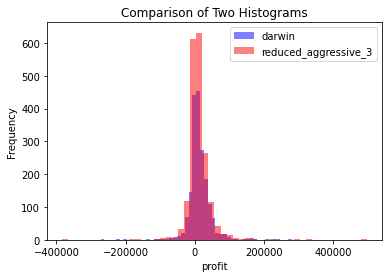

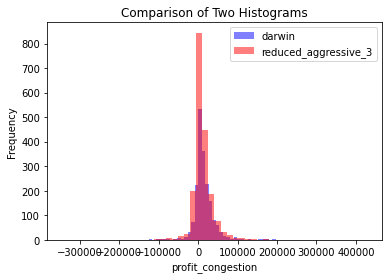

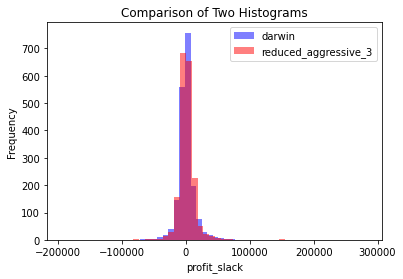

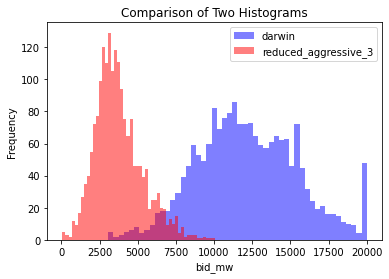

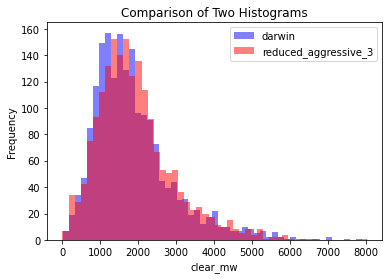

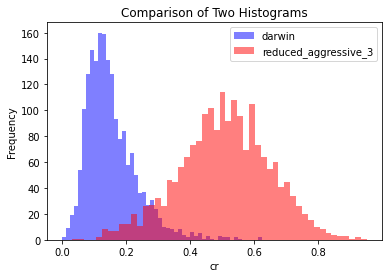

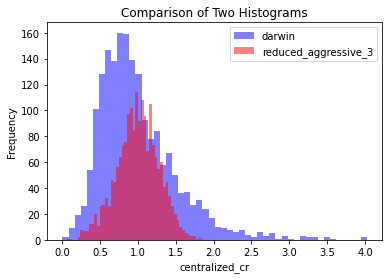

In [420]:

# metric_col = 'profit'
for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr', 'centralized_cr']:
    # Create the histograms
    plt.hist(daily_df[metric_col + '|darwin_reduced_darwin'], bins=50, alpha=0.5, label='darwin', color='blue')
    plt.hist(daily_df[metric_col + '|reduced_aggressive_3_reduced_darwin'], bins=50, alpha=0.5, label='reduced_aggressive_3', color='red')

    # Add labels and title for better understanding
    plt.xlabel(metric_col)
    plt.ylabel('Frequency')
    plt.title('Comparison of Two Histograms')
    plt.legend() # Display the legend to differentiate between groups

    # Show the plot
    plt.show()

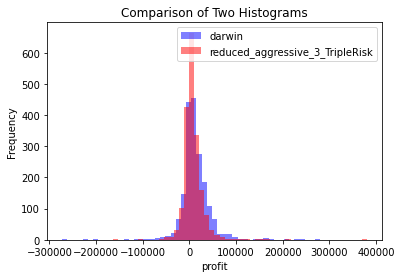

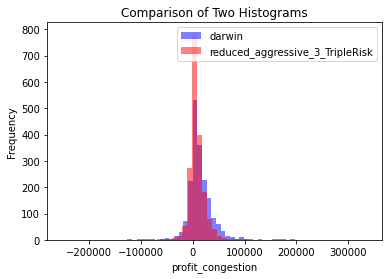

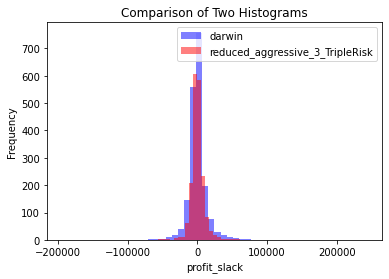

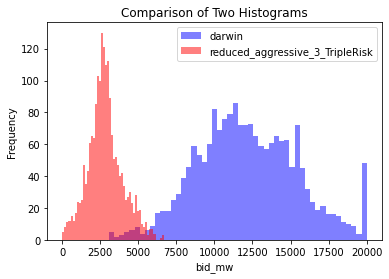

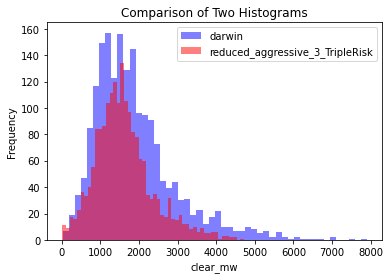

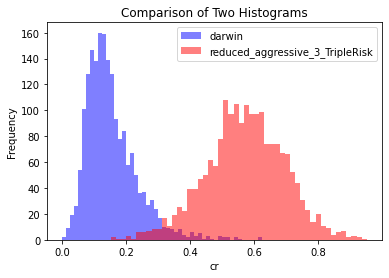

In [273]:
# metric_col = 'profit'
for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']:
    # Create the histograms
    plt.hist(daily_df[metric_col + '|darwin_reduced_darwin'], bins=50, alpha=0.5, label='darwin', color='blue')
    plt.hist(daily_df[metric_col + '|reduced_aggressive_3_reduced_darwinTripleRisk'], bins=50, alpha=0.5, label='reduced_aggressive_3_TripleRisk', color='red')

    # Add labels and title for better understanding
    plt.xlabel(metric_col)
    plt.ylabel('Frequency')
    plt.title('Comparison of Two Histograms')
    plt.legend() # Display the legend to differentiate between groups

    # Show the plot
    plt.show()

In [274]:
display(daily_df[[metric_col+'|diff' for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']]].quantile([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]).round(1))
display(daily_df[[metric_col+'|darwin_reduced_darwin' for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']]].quantile([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]).round(1))
display(daily_df[[metric_col+'|reduced_aggressive_3_reduced_darwin' for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']]].quantile([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]).round(1))
display(daily_df[[metric_col+'|reduced_aggressive_3_reduced_darwinTripleRisk' for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']]].quantile([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]).round(1))

,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff
0.01,-49591.1,-44850.0,-27001.3,-14744.6,-2526.7,0.1
0.05,-25545.2,-23692.6,-10162.2,-12967.8,-920.9,0.2
0.10,-18502.3,-16831.8,-5953.8,-12098.8,-591.1,0.2
0.20,-10784.8,-10507.7,-2720.4,-10672.2,-293.7,0.3
0.30,-7305.0,-6680.4,-1316.9,-9752.4,-143.1,0.3
0.50,-1867.8,-2301.7,732.5,-8309.2,108.0,0.4
0.70,3235.0,1758.3,2882.6,-6958.4,320.8,0.4
0.80,7222.6,5242.8,4529.3,-6171.9,468.2,0.4
0.90,13537.7,11464.3,7993.3,-4933.5,678.8,0.5
0.95,22147.5,19435.7,12459.4,-4296.6,875.3,0.5


,profit|darwin_reduced_darwin,profit_congestion|darwin_reduced_darwin,profit_slack|darwin_reduced_darwin,bid_mw|darwin_reduced_darwin,clear_mw|darwin_reduced_darwin,cr|darwin_reduced_darwin
0.01,-62294.9,-54345.0,-42401.9,4680.0,280.0,0.0
0.05,-22406.4,-13783.9,-16913.7,7004.3,613.6,0.1
0.10,-12403.8,-4927.1,-11378.9,8095.6,800.0,0.1
0.20,-3875.2,198.8,-6316.1,9351.0,1039.9,0.1
0.30,610.5,3368.5,-3788.8,10315.5,1240.0,0.1
0.50,8942.3,10013.1,-56.2,11994.6,1651.0,0.1
0.70,20206.2,19466.6,3572.8,13956.9,2171.0,0.2
0.80,29099.0,28045.8,6694.6,15001.4,2514.8,0.2
0.90,44448.0,40287.1,13754.0,16303.6,3289.3,0.3
0.95,56646.7,53519.3,22007.9,18053.4,4037.9,0.3


,profit|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin
0.01,-62812.4,-49354.4,-33221.9,829.7,229.4,0.2
0.05,-21578.4,-14190.2,-14746.2,1588.5,580.6,0.3
0.10,-13088.5,-7857.5,-10184.4,1999.7,822.2,0.3
0.20,-5936.9,-1783.0,-5652.0,2511.7,1114.8,0.4
0.30,-1044.4,1076.6,-3100.8,2855.3,1335.3,0.4
0.50,6855.1,7285.3,359.2,3502.6,1742.4,0.5
0.70,16944.7,16194.8,4338.6,4282.6,2224.0,0.6
0.80,26219.1,24312.9,7926.4,4910.3,2602.5,0.6
0.90,40883.7,37256.4,13390.3,5894.5,3248.5,0.7
0.95,55997.9,51958.6,20070.0,6662.2,3905.9,0.7


,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|reduced_aggressive_3_reduced_darwinTripleRisk
0.01,-35043.9,-29348.4,-25492.9,371.6,193.0,0.3
0.05,-15993.0,-9847.3,-11479.4,1044.4,538.6,0.4
0.10,-10089.9,-5019.6,-8302.2,1461.6,772.9,0.4
0.20,-4580.2,-718.5,-4733.4,1955.1,1016.8,0.5
0.30,-976.4,1492.4,-2800.0,2301.2,1212.1,0.5
0.50,4925.2,5697.9,80.1,2739.0,1529.4,0.6
0.70,12211.0,11914.2,3140.5,3216.2,1869.2,0.6
0.80,18490.7,17300.9,5762.5,3677.9,2124.7,0.7
0.90,28775.6,25717.8,10005.0,4399.8,2656.2,0.7
0.95,39320.1,35154.9,15234.4,4915.9,3096.5,0.8


In [291]:
display(daily_node_df[[metric_col+'|diff' for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']]].quantile([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]).round(1))
display(daily_node_df[[metric_col+'|darwin_reduced_darwin' for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']]].quantile([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]).round(1))
display(daily_node_df[[metric_col+'|reduced_aggressive_3_reduced_darwin' for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']]].quantile([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]).round(1))
display(daily_node_df[[metric_col+'|reduced_aggressive_3_reduced_darwinTripleRisk' for metric_col in ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw', 'cr']]].quantile([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]).round(1))

,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff
0.01,-3268.3,-3029.3,-1291.6,-450.0,-107.3,-0.2
0.05,-839.7,-713.3,-390.8,-310.0,-45.0,-0.0
0.10,-354.0,-276.8,-177.6,-245.0,-22.7,0.0
0.20,-92.3,-61.0,-46.2,-179.2,-5.0,0.0
0.30,-9.9,-7.0,0.0,-135.0,0.0,0.0
0.50,0.0,0.0,0.0,-80.0,0.0,0.3
0.70,0.0,0.0,12.5,-40.0,5.0,0.5
0.80,67.6,25.6,70.1,-25.0,10.0,0.6
0.90,276.4,168.2,223.7,-10.0,25.0,0.8
0.95,669.8,495.1,460.5,-0.2,45.0,1.0


,profit|darwin_reduced_darwin,profit_congestion|darwin_reduced_darwin,profit_slack|darwin_reduced_darwin,bid_mw|darwin_reduced_darwin,clear_mw|darwin_reduced_darwin,cr|darwin_reduced_darwin
0.01,-2903.0,-2247.0,-1850.4,4.1,0.0,0.0
0.05,-568.1,-303.1,-524.3,10.0,0.0,0.0
0.10,-178.3,-66.4,-207.2,20.0,0.0,0.0
0.20,-14.7,0.0,-39.6,40.0,0.0,0.0
0.30,0.0,0.0,0.0,62.3,0.0,0.0
0.50,0.0,0.0,0.0,115.0,5.0,0.0
0.70,0.0,6.7,0.0,194.1,15.0,0.1
0.80,111.9,92.0,37.3,250.0,35.0,0.2
0.90,538.7,458.8,220.5,345.0,70.0,0.4
0.95,1374.4,1225.8,549.6,430.0,120.0,0.6


,profit|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin
0.01,-2919.2,-2076.8,-1870.0,0.0,0.0,0.0
0.05,-561.8,-304.6,-481.4,0.0,0.0,0.0
0.10,-182.3,-77.9,-178.9,0.0,0.0,0.0
0.20,-17.7,-0.6,-26.8,0.0,0.0,0.0
0.30,0.0,0.0,0.0,0.0,0.0,0.1
0.50,0.0,0.0,0.0,15.0,5.0,0.5
0.70,0.0,0.6,0.0,45.0,15.0,0.8
0.80,85.8,56.5,47.0,75.0,35.0,1.0
0.90,430.4,325.6,231.2,135.0,70.0,1.0
0.95,1147.0,956.5,573.5,205.0,120.0,1.0


KeyError: "None of [Index(['profit|reduced_aggressive_3_reduced_darwinTripleRisk',\n       'profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk',\n       'profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk',\n       'bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk',\n       'clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk',\n       'cr|reduced_aggressive_3_reduced_darwinTripleRisk'],\n      dtype='object')] are in the [columns]"

In [316]:
display(daily_df.sort_values('profit|diff').round(1).head(10))
display(daily_df.sort_values('profit|diff').round(1).tail(10))

,dt,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff,q_profit|darwin_reduced_darwin,q_profit|reduced_aggressive_3_reduced_darwin,q_profit|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit_congestion|darwin_reduced_darwin,q_profit_congestion|reduced_aggressive_3_reduced_darwin,q_profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit_slack|darwin_reduced_darwin,q_profit_slack|reduced_aggressive_3_reduced_darwin,q_profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,q_bid_mw|darwin_reduced_darwin,q_bid_mw|reduced_aggressive_3_reduced_darwin,q_bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,q_clear_mw|darwin_reduced_darwin,q_clear_mw|reduced_aggressive_3_reduced_darwin,q_clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,q_cr|darwin_reduced_darwin,q_cr|reduced_aggressive_3_reduced_darwin,q_cr|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit|diff,q_profit_congestion|diff,q_profit_slack|diff,q_bid_mw|diff,q_clear_mw|diff,q_cr|diff
1355,2024-03-16,240629.8,41628.2,3805.8,176369.4,34261.8,361.0,55402.7,4658.0,2983.7,8289.8,1250.0,416.6,1471.2,420.0,107.5,0.2,0.3,0.3,-199001.6,-142107.6,-50744.7,-7039.8,-1051.2,0.2,1.0,0.9,0.5,1.0,0.9,0.2,1.0,0.7,0.7,0.1,0.0,0.0,0.4,0.0,0.0,0.7,0.1,0.0,0.0,0.0,0.0,0.7,0.0,0.1
1361,2024-03-22,45378.6,-116080.0,-8924.0,54987.5,-106915.8,-10705.5,-5200.7,-6544.0,6517.5,10531.3,1454.8,2208.6,1212.3,704.8,1406.0,0.1,0.5,0.6,-161458.6,-161903.3,-1343.3,-9076.5,-507.5,0.4,0.9,0.0,0.1,1.0,0.0,0.0,0.2,0.2,0.8,0.3,0.0,0.3,0.3,0.1,0.4,0.3,0.4,0.7,0.0,0.0,0.3,0.4,0.1,0.6
1535,2024-09-27,-272433.2,-382829.1,-163730.6,-250850.1,-344411.5,-144980.7,-17723.7,-33592.0,-14314.3,13151.1,4418.3,3735.2,1518.8,1894.8,1858.4,0.1,0.4,0.5,-110395.9,-93561.4,-15868.3,-8732.8,376.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.7,0.8,0.4,0.6,0.7,0.3,0.3,0.3,0.0,0.0,0.0,0.4,0.7,0.4
1819,2025-07-21,-59358.5,-159194.6,-60885.5,-57558.5,-158447.1,-56458.9,-1438.8,-149.4,-3850.6,11184.0,2773.9,2352.3,985.0,1395.6,1353.1,0.1,0.5,0.6,-99836.0,-100888.6,1289.4,-8410.1,410.6,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.5,0.2,0.4,0.3,0.3,0.2,0.3,0.4,0.2,0.5,0.5,0.0,0.0,0.6,0.5,0.8,0.7
283,2020-10-26,85396.6,-1904.5,1197.8,17308.7,6880.1,4826.6,70660.9,-10361.9,-4068.0,14525.2,4102.3,3659.3,1515.2,1672.3,1611.3,0.1,0.4,0.4,-87301.2,-10428.6,-81022.9,-10422.9,157.1,0.3,1.0,0.3,0.4,0.7,0.5,0.5,1.0,0.1,0.2,0.8,0.7,0.8,0.4,0.5,0.6,0.3,0.2,0.1,0.0,0.2,0.0,0.2,0.5,0.3
1488,2024-08-10,124910.2,38736.3,12193.7,76717.6,32517.7,10045.4,49671.8,6770.9,2334.3,11953.7,1900.0,633.3,5229.2,1565.0,521.7,0.4,0.8,0.8,-86173.9,-44199.9,-42900.9,-10053.7,-3664.2,0.4,1.0,0.9,0.7,1.0,0.9,0.6,1.0,0.8,0.7,0.5,0.1,0.0,1.0,0.4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.3,0.0,0.6
362,2021-01-14,94877.1,18308.3,22989.5,92812.5,21031.2,24780.1,3272.6,-1639.8,-835.1,12380.5,4375.7,3659.2,2025.2,1297.8,1360.5,0.2,0.3,0.4,-76568.8,-71781.3,-4912.4,-8004.8,-727.4,0.1,1.0,0.7,0.9,1.0,0.8,0.9,0.7,0.4,0.4,0.5,0.7,0.8,0.7,0.3,0.4,0.6,0.1,0.1,0.0,0.0,0.1,0.5,0.1,0.0
161,2020-06-22,228374.3,153196.2,141714.5,-18089.8,-2286.6,-8678.1,242915.2,153073.2,149096.0,15613.0,7609.4,5178.5,5560.0,4499.3,3615.1,0.4,0.6,0.7,-75178.1,15803.2,-89842.0,-80

,dt,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff,q_profit|darwin_reduced_darwin,q_profit|reduced_aggressive_3_reduced_darwin,q_profit|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit_congestion|darwin_reduced_darwin,q_profit_congestion|reduced_aggressive_3_reduced_darwin,q_profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit_slack|darwin_reduced_darwin,q_profit_slack|reduced_aggressive_3_reduced_darwin,q_profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,q_bid_mw|darwin_reduced_darwin,q_bid_mw|reduced_aggressive_3_reduced_darwin,q_bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,q_clear_mw|darwin_reduced_darwin,q_clear_mw|reduced_aggressive_3_reduced_darwin,q_clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,q_cr|darwin_reduced_darwin,q_cr|reduced_aggressive_3_reduced_darwin,q_cr|reduced_aggressive_3_reduced_darwinTripleRisk,q_profit|diff,q_profit_congestion|diff,q_profit_slack|diff,q_bid_mw|diff,q_clear_mw|diff,q_cr|diff
838,2022-08-31,-134911.9,-71037.0,-56229.7,-2230.9,603.7,-2594.8,-130783.4,-68477.7,-51105.2,13149.9,2562.1,2201.7,1874.5,1703.5,1630.5,0.1,0.7,0.7,63874.9,2834.6,62305.7,-10587.8,-171.0,0.5,0.0,0.0,0.0,0.1,0.3,0.1,0.0,0.0,0.0,0.6,0.2,0.3,0.6,0.5,0.6,0.5,0.9,0.9,1.0,0.7,1.0,0.2,0.3,0.9
1230,2023-11-05,-4766.5,62082.8,11692.7,-8968.0,604.6,2312.4,1980.2,60959.7,7901.8,10087.6,5254.6,3148.4,2182.9,2964.6,1958.4,0.2,0.6,0.6,66849.2,9572.6,58979.5,-4833.0,781.7,0.3,0.2,1.0,0.7,0.1,0.3,0.3,0.6,1.0,0.9,0.3,0.8,0.7,0.7,0.9,0.7,0.8,0.7,0.7,1.0,0.9,1.0,0.9,0.9,0.5
366,2021-01-19,-57734.9,20394.4,-34597.8,1679.5,13210.4,7482.5,-62210.3,7676.5,-46293.7,19998.9,7554.9,5894.5,3106.0,3774.3,3158.4,0.2,0.5,0.5,78129.3,11530.9,69886.8,-12444.0,668.3,0.3,0.0,0.7,0.0,0.2,0.6,0.6,0.0,0.8,0.0,1.0,1.0,1.0,0.9,0.9,1.0,0.6,0.5,0.4,1.0,0.9,1.0,0.1,0.9,0.5
1729,2025-04-21,-98709.5,-14938.9,-21794.0,-100912.2,-19700.6,-21708.7,3082.3,5797.5,660.1,13274.6,3779.5,2782.0,1458.6,1861.7,1350.0,0.1,0.5,0.5,83770.5,81211.6,2715.2,-9495.1,403.1,0.4,0.0,0.1,0.0,0.0,0.0,0.0,0.7,0.7,0.5,0.6,0.6,0.5,0.4,0.5,0.4,0.3,0.4,0.2,1.0,1.0,0.7,0.3,0.8,0.6
1525,2024-09-17,-95473.5,-9487.3,-18698.7,-86541.8,-5896.6,-13390.2,-7554.4,-3011.5,-4541.2,12181.7,2003.2,2243.8,1435.0,660.0,911.5,0.1,0.3,0.4,85986.2,80645.1,4542.9,-10178.5,-775.0,0.2,0.0,0.1,0.0,0.0,0.1,0.0,0.2,0.3,0.2,0.5,0.1,0.3,0.4,0.1,0.2,0.4,0.1,0.1,1.0,1.0,0.8,0.2,0.1,0.1
373,2021-01-26,206031.6,296808.0,212922.1,14749.6,14640.3,11835.6,191885.3,283015.9,201562.0,13441.4,5050.0,3727.8,3476.4,3995.3,3156.6,0.3,0.8,0.8,90776.5,-109.3,91130.6,-8391.4,518.9,0.5,1.0,1.0,1.0,0.6,0.7,0.7,1.0,1.0,1.0,0.7,0.8,0.8,0.9,1.0,1.0,0.9,1.0,1.0,1.0,0.6,1.0,0.5,0.8,1.0
780,2022-06-28,-110509.8,-16696.9,-18868.7,8186.1,11290.2,9527.4,-117682.4,-27656.6,-28072.2,14993.2,2322.6,2117.5,1520.0,1327.6,1375.8,0.1,0.6,0.6,93812.9,3104.1,90025.8,-12670.6,-192.4,0.5,0.0,0.1,0.0,0.4,0.6,0.6,0.0,0.0,0.0,0.8,0.2,0.2,0.4,0.3,0.4,0.3,0.7,0.7,1.0,0.7,1.0,0.1,0.3,0.9
437,2021-04-13,211384.4,333458.6,154410.2,190466.1,292078.6,139313.7,16660.2,35411.1,11864.4,12866.1,5183.4,4592.3,1846.5,1800.0,1802.8,0.1,0.3,0.4,122074.2,101612.5,18750.9,-7682.7,-46.5,0.2,1.0,1.0,1

In [373]:
temp_dt = '2025-04-21'


darwin_segments = get_segment_option('darwin')
result_temp = _calculate_cumulative_return_and_risk_for_one_day(valuationModel[valuationModel['dt'] == temp_dt],
                                                                     prediction='total',
                                                                     segments=darwin_segments)
result_temp['expectedProfit'] = result_temp['cumulativeReturn'] + result_temp['cumulativeRisk']
result_temp['segment'] = np.where(result_temp['incdec'] == 'Decrement', result_temp['decSegment'],
                                   result_temp['incSegment'])
daily_df[daily_df['dt'] == temp_dt].round(1).T

,1729
dt,2025-04-21
profit|darwin_reduced_darwin,-98709.5
profit|reduced_aggressive_3_reduced_darwin,-14938.9
profit|reduced_aggressive_3_reduced_darwinTripleRisk,-21794.0
profit_congestion|darwin_reduced_darwin,-100912.2
profit_congestion|reduced_aggressive_3_reduced_darwin,-19700.6
profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,-21708.7
profit_slack|darwin_reduced_darwin,3082.3
profit_slack|reduced_aggressive_3_reduced_darwin,5797.5
profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,660.1


In [374]:
# daily nodal analysis
print('sort by profit|diff...')
temp = daily_node_incdec_df[(daily_node_incdec_df['dt'] == temp_dt)].sort_values('profit|diff').round(1)
display(temp.loc[(temp['profit|diff'].abs() > 1000), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]])
display(temp.loc[(temp['profit|diff'].abs() > 1000), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]])

# print('sort by bid_mw|diff...')
# temp = daily_node_incdec_df[(daily_node_incdec_df['dt'] == temp_dt)].sort_values('bid_mw|diff').round(1)
# display(temp.loc[(temp['bid_mw|diff'].abs() > 100), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]])
# display(temp.loc[(temp['bid_mw|diff'].abs() > 100), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]])

print('sort by bid_mw|reduced_aggressive_3_reduced_darwin...')
temp = daily_node_incdec_df[(daily_node_incdec_df['dt'] == temp_dt)].sort_values('bid_mw|reduced_aggressive_3_reduced_darwin', ascending=False).round(1)
display(temp.loc[(temp['bid_mw|reduced_aggressive_3_reduced_darwin'].abs() > 100), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]])
display(temp.loc[(temp['bid_mw|reduced_aggressive_3_reduced_darwin'].abs() > 100), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]])

print('sort by bid_mw|darwin_reduced_darwin...')
temp = daily_node_incdec_df[(daily_node_incdec_df['dt'] == temp_dt)].sort_values('bid_mw|darwin_reduced_darwin', ascending=False).round(1)
display(temp.loc[(temp['bid_mw|darwin_reduced_darwin'].abs() > 100), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]])
display(temp.loc[(temp['bid_mw|darwin_reduced_darwin'].abs() > 100), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]])


sort by profit|diff...


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
223993,1533.0,Increment,-10231.4,-14472.1,-17709.5,-10042.8,-14340.9,-17528.7,-166.7,-107.6,-151.0,-4240.7,-4298.1,59.1
223896,338.0,Decrement,2075.1,0.0,63.1,2022.0,0.0,37.8,79.6,0.0,25.2,-2075.1,-2022.0,-79.6
223912,540.0,Decrement,-15073.4,-16349.9,-5345.6,-16494.0,-17953.5,-5929.1,1587.7,1777.9,647.5,-1276.5,-1459.4,190.2
223915,546.0,Increment,-2675.7,-1195.0,-1503.7,-2208.9,-1015.1,-1217.0,-453.7,-172.8,-277.8,1480.6,1193.7,280.9
223958,1117.0,Increment,775.1,2408.8,1523.3,1138.7,3061.0,1917.6,-280.1,-527.2,-314.1,1633.7,1922.2,-247.0
223917,547.0,Increment,2260.7,3917.9,1252.2,2376.2,4045.2,1543.9,-9.6,9.0,-217.4,1657.2,1668.9,18.5
223928,835.0,Increment,1470.7,3554.6,1315.7,1321.3,3178.4,1262.6,159.1,407.2,79.1,2083.9,1857.1,248.1
223944,955.0,Decrement,-7107.8,147.9,-18.8,-7511.4,80.3,-139.2,320.2,66.5,123.8,7255.7,7591.7,-253.7
223998,1568.0,Increment,-70800.4,2204.9,-4257.9,-70350.1,2323.9,-4010.0,-61.0,-39.1,-129.1,73005.3,72674.0,21.9


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
223993,1533.0,Increment,150.0,20.0,23.3,15.0,15.0,18.3,0.1,0.8,0.8,-130.0,0.0,0.6
223896,338.0,Decrement,95.0,0.0,5.0,40.0,0.0,3.3,0.4,NaN,0.7,-95.0,-40.0,NaN
223912,540.0,Decrement,340.0,305.0,120.0,285.0,295.0,113.3,0.8,1.0,0.9,-35.0,10.0,0.1
223915,546.0,Increment,266.7,20.0,31.7,40.0,20.0,28.3,0.1,1.0,0.9,-246.7,-20.0,0.9
223958,1117.0,Increment,385.0,231.7,153.4,115.0,206.7,128.4,0.3,0.9,0.8,-153.3,91.7,0.6
223917,547.0,Increment,448.6,290.0,158.3,158.6,230.0,125.0,0.4,0.8,0.8,-158.6,71.4,0.4
223928,835.0,Increment,130.0,75.6,60.0,15.0,50.6,40.0,0.1,0.7,0.7,-54.4,35.6,0.6
223944,955.0,Decrement,235.0,15.0,18.3,90.0,15.0,18.3,0.4,1.0,1.0,-220.0,-75.0,0.6
223998,1568.0,Increment,325.0,20.0,31.7,110.0,20.0,31.7,0.3,1.0,1.0,-305.0,-90.0,0.7


sort by bid_mw|reduced_aggressive_3_reduced_darwin...


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
223912,540.0,Decrement,-15073.4,-16349.9,-5345.6,-16494.0,-17953.5,-5929.1,1587.7,1777.9,647.5,-1276.5,-1459.4,190.2
223917,547.0,Increment,2260.7,3917.9,1252.2,2376.2,4045.2,1543.9,-9.6,9.0,-217.4,1657.2,1668.9,18.5
223958,1117.0,Increment,775.1,2408.8,1523.3,1138.7,3061.0,1917.6,-280.1,-527.2,-314.1,1633.7,1922.2,-247.0
223913,542.0,Increment,153.6,558.6,406.8,127.3,681.6,609.2,31.3,-113.7,-193.3,405.1,554.3,-145.0
223931,847.0,Decrement,-627.5,-784.5,-386.9,-1263.1,-1555.8,-775.9,710.4,867.7,440.1,-157.0,-292.7,157.3
223955,1080.0,Increment,12.8,135.2,28.0,9.7,14.7,-1.0,5.8,134.9,35.0,122.4,5.0,129.0
223997,1568.0,Decrement,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
223922,703.0,Increment,0.0,82.5,24.7,0.0,91.6,44.7,0.0,20.2,-10.0,82.5,91.6,20.2
223959,1145.0,Increment,44.6,541.8,201.5,-6.4,14.7,27.5,53.0,576.3,186.2,497.2,21.2,523.3
223939,917.0,Decrement,-99.9,-206.9,-27.1,-135.8,-270.8,-72.1,27.6,46.3,38.1,-107.0,-135.0,18.7


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
223912,540.0,Decrement,340.0,305.0,120.0,285.0,295.0,113.3,0.8,1.0,0.9,-35.0,10.0,0.1
223917,547.0,Increment,448.6,290.0,158.3,158.6,230.0,125.0,0.4,0.8,0.8,-158.6,71.4,0.4
223958,1117.0,Increment,385.0,231.7,153.4,115.0,206.7,128.4,0.3,0.9,0.8,-153.3,91.7,0.6
223913,542.0,Increment,250.0,160.0,86.7,10.0,50.0,35.0,0.0,0.3,0.4,-90.0,40.0,0.3
223931,847.0,Decrement,410.0,145.0,75.0,65.0,100.0,56.7,0.2,0.7,0.8,-265.0,35.0,0.5
223955,1080.0,Increment,195.0,130.0,73.3,5.0,20.0,8.3,0.0,0.2,0.1,-65.0,15.0,0.1
223997,1568.0,Decrement,375.1,125.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,-250.1,0.0,0.0
223922,703.0,Increment,210.0,125.0,70.0,0.0,55.0,26.7,0.0,0.4,0.4,-85.0,55.0,0.4
223959,1145.0,Increment,125.0,120.0,56.7,5.0,60.0,21.7,0.0,0.5,0.4,-5.0,55.0,0.5
223939,917.0,Decrement,285.0,110.0,76.7,5.0,20.0,21.7,0.0,0.2,0.3,-175.0,15.0,0.2


sort by bid_mw|darwin_reduced_darwin...


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
223917,547.0,Increment,2260.7,3917.9,1252.2,2376.2,4045.2,1543.9,-9.6,9.0,-217.4,1657.2,1668.9,18.5
223914,546.0,Decrement,-615.9,-435.4,-263.7,-1608.5,-973.0,-521.2,999.2,534.9,256.6,180.5,635.4,-464.3
223931,847.0,Decrement,-627.5,-784.5,-386.9,-1263.1,-1555.8,-775.9,710.4,867.7,440.1,-157.0,-292.7,157.3
223958,1117.0,Increment,775.1,2408.8,1523.3,1138.7,3061.0,1917.6,-280.1,-527.2,-314.1,1633.7,1922.2,-247.0
223997,1568.0,Decrement,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
223912,540.0,Decrement,-15073.4,-16349.9,-5345.6,-16494.0,-17953.5,-5929.1,1587.7,1777.9,647.5,-1276.5,-1459.4,190.2
223998,1568.0,Increment,-70800.4,2204.9,-4257.9,-70350.1,2323.9,-4010.0,-61.0,-39.1,-129.1,73005.3,72674.0,21.9
223899,348.0,Increment,474.7,712.0,237.3,545.3,817.9,272.6,-55.2,-82.7,-27.6,237.3,272.6,-27.6
223962,1164.0,Increment,2025.3,1427.0,2242.8,2330.2,1607.1,2374.2,-279.6,-163.2,-107.4,-598.3,-723.1,116.4
223988,1494.0,Decrement,-1232.1,-1426.4,-901.6,-1433.8,-1765.0,-1079.2,138.1,257.8,137.3,-194.2,-331.2,119.7


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
223917,547.0,Increment,448.6,290.0,158.3,158.6,230.0,125.0,0.4,0.8,0.8,-158.6,71.4,0.4
223914,546.0,Decrement,415.0,90.0,53.3,170.0,80.0,45.0,0.4,0.9,0.8,-325.0,-90.0,0.5
223931,847.0,Decrement,410.0,145.0,75.0,65.0,100.0,56.7,0.2,0.7,0.8,-265.0,35.0,0.5
223958,1117.0,Increment,385.0,231.7,153.4,115.0,206.7,128.4,0.3,0.9,0.8,-153.3,91.7,0.6
223997,1568.0,Decrement,375.1,125.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,-250.1,0.0,0.0
223912,540.0,Decrement,340.0,305.0,120.0,285.0,295.0,113.3,0.8,1.0,0.9,-35.0,10.0,0.1
223998,1568.0,Increment,325.0,20.0,31.7,110.0,20.0,31.7,0.3,1.0,1.0,-305.0,-90.0,0.7
223899,348.0,Increment,312.2,75.0,50.7,10.0,15.0,5.0,0.0,0.2,0.1,-237.2,5.0,0.2
223962,1164.0,Increment,300.0,80.0,86.7,35.0,25.0,41.7,0.1,0.3,0.5,-220.0,-10.0,0.2
223988,1494.0,Decrement,300.0,40.0,43.3,20.0,35.0,31.7,0.1,0.9,0.7,-260.0,15.0,0.8


In [302]:
# hourly nodal analysis

temp_node = 681
temp_incdec = 'Increment'  # Increment, Decrement
print('sort by profit|diff...')
temp = hourly_node_incdec_df[(hourly_node_incdec_df['dt'] == temp_dt)&(hourly_node_incdec_df['node_num'] == temp_node)&(hourly_node_incdec_df['incdec'] == temp_incdec)].sort_values('profit|diff').round(1)
display(temp.loc[(temp['profit|diff'].abs() > 500), ['hr', 'node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]])
display(temp.loc[(temp['profit|diff'].abs() > 500), ['hr', 'node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]])

print('sort by bid_mw|diff...')
temp = hourly_node_incdec_df[(hourly_node_incdec_df['dt'] == temp_dt)&(hourly_node_incdec_df['node_num'] == temp_node)&(hourly_node_incdec_df['incdec'] == temp_incdec)].sort_values('bid_mw|diff').round(1)
display(temp.loc[(temp['bid_mw|diff'].abs() > 10), ['hr', 'node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]])
display(temp.loc[(temp['bid_mw|diff'].abs() > 10), ['hr', 'node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]])


sort by profit|diff...


,hr,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
1638278,20.0,681.0,Increment,-23758.2,-38013.2,-12671.1,-22325.1,-35720.2,-11906.7,-1280.3,-2048.5,-682.8,-14254.9,-13395.1,-768.2
1638317,21.0,681.0,Increment,-27583.9,-38617.5,-12872.5,-25864.2,-36209.9,-12070.0,-1592.1,-2229.0,-743.0,-11033.6,-10345.7,-636.8
1638355,22.0,681.0,Increment,-30659.0,-40878.7,-13626.2,-28695.3,-38260.4,-12753.5,-1822.6,-2430.1,-810.0,-10219.7,-9565.1,-607.5
1638385,23.0,681.0,Increment,-2858.4,-4764.0,-1588.0,-2645.6,-4409.3,-1469.8,-161.1,-268.6,-89.5,-1905.6,-1763.7,-107.4


,hr,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
1638278,20.0,681.0,Increment,35.0,40.0,13.3,25.0,40.0,13.3,0.7,1.0,1.0,5.0,15.0,0.3
1638317,21.0,681.0,Increment,40.0,40.0,13.3,25.0,35.0,11.7,0.6,0.9,0.9,0.0,10.0,0.2
1638355,22.0,681.0,Increment,40.0,40.0,13.3,30.0,40.0,13.3,0.8,1.0,1.0,0.0,10.0,0.2
1638385,23.0,681.0,Increment,40.0,40.0,13.3,15.0,25.0,8.3,0.4,0.6,0.6,0.0,10.0,0.2


sort by bid_mw|diff...


,hr,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
1637513,6.0,681.0,Increment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1637570,7.0,681.0,Increment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1637630,8.0,681.0,Increment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1637697,9.0,681.0,Increment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1637845,12.0,681.0,Increment,0.0,0.0,34.2,0.0,0.0,-4.6,0.0,0.0,66.5,0.0,0.0,0.0
1637797,11.0,681.0,Increment,0.0,0.0,4.0,0.0,0.0,-2.4,0.0,0.0,53.3,0.0,0.0,0.0


,hr,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
1637513,6.0,681.0,Increment,20.0,0.0,1.7,0.0,0.0,0.0,0.0,NaN,0.0,-20.0,0.0,NaN
1637570,7.0,681.0,Increment,30.0,10.0,6.7,0.0,0.0,0.0,0.0,0.0,0.0,-20.0,0.0,0.0
1637630,8.0,681.0,Increment,30.0,10.0,8.3,0.0,0.0,0.0,0.0,0.0,0.0,-20.0,0.0,0.0
1637697,9.0,681.0,Increment,30.0,10.0,8.3,0.0,0.0,0.0,0.0,0.0,0.0,-20.0,0.0,0.0
1637845,12.0,681.0,Increment,25.0,5.0,8.3,0.0,0.0,5.0,0.0,0.0,0.6,-20.0,0.0,0.0
1637797,11.0,681.0,Increment,30.0,15.0,13.3,0.0,0.0,8.3,0.0,0.0,0.6,-15.0,0.0,0.0


In [280]:
temp = result_temp[(result_temp['dt'] == temp_dt)&(result_temp['hr']==12)&(result_temp['node_num'] == temp_node)&(result_temp['incdec'] == temp_incdec)].sort_values('segment').round(1)
temp

,dt,hr,node_num,incdec,rt_total_mean,da_total_mean,node_name,zone,da_congestion,da_total,da_slack,rt_congestion,rt_total,rt_slack,quantile_DA,DAQuantile,op_rate_inc_a,op_rate_dec_a,op_rate_inc_f,op_rate_dec_f,bid_ref_price,offer_ref_price,DAProbability,DA_MiddlePoint,DAweight,interrimSegment,return,risk,cumulativeReturn,cumulativeRisk,decSegment,incSegment,id,expectedProfit,segment
29656,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q95,38.3,-0.4,-1.2,1.4,0.4,-32.0,-37.4,1.0,36.5,0.0,3,1.4,-0.7,29.5,-4.9,2,14,1,24.5,2
26824,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q90,34.7,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.9,33.2,0.1,4,1.4,-0.6,28.1,-4.2,3,13,1,23.9,3
23992,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q80,29.3,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.8,27.9,0.1,6,2.9,-0.8,25.3,-3.2,5,11,1,22.1,5
21160,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q70,26.5,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.7,25.6,0.1,7,3.0,-0.6,22.4,-2.4,6,10,1,19.9,6
18328,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q60,24.6,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.6,23.9,0.1,8,3.1,-0.5,19.4,-1.9,7,9,1,17.5,7
15496,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q50,23.1,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.5,22.6,0.1,9,3.1,-0.4,16.3,-1.4,8,8,1,15.0,8
9832,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q40,22.0,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.4,21.5,0.1,10,3.2,-0.4,13.2,-0.9,9,7,1,12.3,9
7000,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q30,21.0,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.3,19.9,0.1,11,3.2,-0.3,10.1,-0.6,10,6,1,9.5,10
4168,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q20,18.9,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.2,18.6,0.1,12,1.7,-0.1,6.8,-0.3,11,5,1,6.5,11
1336,2024-03-16,12,704,Decrement,57.0,24.3,SPS.SPINSPUR,SPS,7.0,25.2,18.9,1110.4,1340.3,213.9,da_total_q10,17.4,-0.4,-1.2,1.4,0.4,-32.0,-37.4,0.1,15.3,0.0,14,1.8,-0.1,3.5,-0.1,13,3,1,3.4,13


In [376]:
groupby_cols = ['node_num', 'incdec',]
metric_cols = ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw']

node_incdec_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)

for col in temp_model_portfolio_lst: 
    node_incdec_df[('cr', col)] = node_incdec_df[('clear_mw', col)]/node_incdec_df[('bid_mw', col)]
    node_incdec_df[('PPBMW', col)] = node_incdec_df[('profit', col)]/node_incdec_df[('bid_mw', col)]

node_incdec_df = node_incdec_df/node_incdec_df.sum()
node_incdec_df = node_incdec_df.reset_index()

for col in metric_cols + ['cr', 'PPBMW']:
    node_incdec_df[(col, 'diff')] = node_incdec_df[(col, temp_model_portfolio_lst[1])] - node_incdec_df[(col, temp_model_portfolio_lst[0])]

node_incdec_df.columns = node_incdec_df.columns.map('|'.join).str.strip('|')


In [386]:
temp.quantile([0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])

,node_num,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,PPBMW|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,PPBMW|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,PPBMW|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff,PPBMW|diff
0.01,29.95,-0.00100,-0.001,-0.001,-0.001,-0.001,-0.001,-0.01300,-0.00500,-0.006,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.00400,0.000,-0.005,0.000,-0.006,-0.002,-0.002,-0.011,-0.001,-0.001,-0.001,-0.005
0.05,103.00,0.00000,0.000,0.000,0.000,0.000,0.000,-0.00600,-0.00300,-0.003,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.00100,0.000,-0.002,0.000,-0.002,-0.001,-0.001,-0.005,-0.000,0.000,0.000,-0.002
0.10,200.50,-0.00000,0.000,0.000,0.000,0.000,0.000,-0.00400,-0.00100,-0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.00100,0.000,-0.001,0.000,-0.001,0.000,0.000,-0.003,0.000,0.000,0.000,-0.001
0.50,902.00,0.00000,-0.000,0.000,0.000,0.000,0.000,0.00000,-0.00000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
0.90,1490.50,0.00100,0.001,0.001,0.001,0.001,0.001,0.00500,0.00300,0.003,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.00200,0.001,0.002,0.001,0.002,-0.000,0.000,0.003,0.000,-0.000,0.000,0.001
0.95,1569.25,0.00200,0.002,0.002,0.002,0.002,0.002,0.00800,0.00400,0.004,0.002,0.002,0.002,0.002,0.002,0.002,0.001,0.00200,0.001,0.003,0.001,0.003,0.001,0.000,0.005,0.000,0.000,0.000,0.002
0.99,1659.05,0.00605,0.007,0.006,0.006,0.007,0.006,0.02005,0.00905,0.010,0.004,0.004,0.003,0.004,0.004,0.004,0.001,0.00619,0.001,0.008,0.001,0.007,0.002,0.002,0.011,0.001,0.001,0.001,0.006


In [393]:
temp = node_incdec_df.round(3).sort_values('profit|diff')
print('sort by profit|diff...')


display(temp.loc[(temp['profit|diff'] > 0.004)&(temp['profit|darwin_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].head(10))
display(temp.loc[(temp['profit|diff'] > 0.004)&(temp['profit|darwin_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].head(10))

display(temp.loc[(temp['profit|diff'] < -0.004)&(temp['profit|darwin_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].tail(10))
display(temp.loc[(temp['profit|diff'] < -0.004)&(temp['profit|darwin_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].tail(10))


display(temp.loc[(temp['profit|diff'] > 0.004)&(temp['profit|darwin_reduced_darwin'] < -0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].head(10))
display(temp.loc[(temp['profit|diff'] > 0.004)&(temp['profit|darwin_reduced_darwin'] < -0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].head(10))

display(temp.loc[(temp['profit|diff'] < -0.004)&(temp['profit|darwin_reduced_darwin'] < -0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].tail(10))
display(temp.loc[(temp['profit|diff'] < -0.004)&(temp['profit|darwin_reduced_darwin'] < -0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].tail(10))



# display(temp.loc[(temp['PPBMW|diff'] > 0.001)&(temp['profit|reduced_aggressive_3_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].head(10))
# display(temp.loc[(temp['PPBMW|diff'] > 0.001)&(temp['profit|reduced_aggressive_3_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].head(10))

# display(temp.loc[(temp['PPBMW|diff'] < -0.001)&(temp['profit|reduced_aggressive_3_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].tail(10))
# display(temp.loc[(temp['PPBMW|diff'] < -0.001)&(temp['profit|reduced_aggressive_3_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].tail(10))



# temp = node_incdec_df.round(3).sort_values('bid_mw|diff')
# print('sort by bid_mw|diff...')

# display(temp.loc[(temp['bid_mw|diff'].abs() > 0.001), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].head(10))
# display(temp.loc[(temp['bid_mw|diff'].abs() > 0.001), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].head(10))

# display(temp.loc[(temp['bid_mw|diff'].abs() > 0.001), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].tail(10))
# display(temp.loc[(temp['bid_mw|diff'].abs() > 0.001), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].tail(10))

# print('sort by profit|diff...')

# temp = node_incdec_df.round(3).sort_values('profit|diff')
# display(temp.loc[(temp['profit|diff'].abs() > 0.001), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].head(10))
# display(temp.loc[(temp['profit|diff'].abs() > 0.001), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].head(10))

# display(temp.loc[(temp['profit|diff'].abs() > 0.001), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].tail(10))
# display(temp.loc[(temp['profit|diff'].abs() > 0.001), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].tail(10))


sort by profit|diff...


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
1953,1272.0,Increment,0.011,0.017,0.010,0.011,0.016,0.010,0.035,0.027,0.022,0.005,0.005,-0.007
1214,858.0,Decrement,0.009,0.014,0.018,0.009,0.014,0.017,-0.012,-0.001,-0.008,0.005,0.005,0.011
1885,1236.0,Increment,0.008,0.012,0.011,0.008,0.013,0.011,-0.007,0.001,0.007,0.005,0.005,0.007
2010,1307.0,Increment,0.015,0.020,0.012,0.013,0.018,0.010,0.027,0.015,0.015,0.005,0.005,-0.011
1262,883.0,Decrement,0.006,0.011,0.006,0.006,0.010,0.006,0.001,0.000,-0.005,0.005,0.005,-0.001
2297,1468.0,Decrement,0.010,0.016,0.008,0.007,0.013,0.006,0.025,0.012,0.004,0.006,0.006,-0.012
2090,1349.0,Decrement,0.018,0.029,0.027,0.020,0.033,0.029,-0.050,-0.030,-0.031,0.011,0.013,0.020


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
1953,1272.0,Increment,0.002,0.005,0.003,0.004,0.006,0.004,0.001,0.0,0.0,0.002,0.001,-0.0
1214,858.0,Decrement,0.008,0.007,0.007,0.006,0.006,0.006,0.000,0.0,0.0,-0.000,-0.000,0.0
1885,1236.0,Increment,0.004,0.006,0.005,0.005,0.006,0.006,0.000,0.0,0.0,0.001,0.002,0.0
2010,1307.0,Increment,0.002,0.002,0.002,0.002,0.002,0.002,0.000,0.0,0.0,0.000,0.000,0.0
1262,883.0,Decrement,0.002,0.003,0.003,0.003,0.003,0.003,0.001,0.0,0.0,0.001,0.000,-0.0
2297,1468.0,Decrement,0.001,0.002,0.001,0.001,0.002,0.001,0.001,0.0,0.0,0.001,0.000,-0.0
2090,1349.0,Decrement,0.005,0.008,0.007,0.007,0.008,0.007,0.001,0.0,0.0,0.003,0.001,-0.0


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
977,704.0,Decrement,0.017,0.006,0.005,0.019,0.01,0.008,-0.06,-0.03,-0.027,-0.011,-0.009,0.03


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
977,704.0,Decrement,0.009,0.007,0.007,0.011,0.008,0.007,0.001,0.0,0.0,-0.002,-0.003,-0.0


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
2325,1484.0,Increment,-0.011,-0.016,-0.01,-0.011,-0.016,-0.008,0.013,0.012,0.0,-0.005,-0.006,-0.001


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
2325,1484.0,Increment,0.001,0.002,0.001,0.002,0.003,0.002,0.001,0.001,0.0,0.001,0.001,-0.0


In [396]:

display(temp.loc[(temp['profit|diff'] < -0.004)&(temp['profit|reduced_aggressive_3_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].tail(10))
display(temp.loc[(temp['profit|diff'] < -0.004)&(temp['profit|reduced_aggressive_3_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].tail(10))

display(temp.loc[(temp['profit|diff'] > 0.004)&(temp['profit|reduced_aggressive_3_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].head(10))
display(temp.loc[(temp['profit|diff'] > 0.004)&(temp['profit|reduced_aggressive_3_reduced_darwin'] > 0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].head(10))


display(temp.loc[(temp['profit|diff'] < -0.004)&(temp['profit|reduced_aggressive_3_reduced_darwin'] < -0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].tail(10))
display(temp.loc[(temp['profit|diff'] < -0.004)&(temp['profit|reduced_aggressive_3_reduced_darwin'] < -0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].tail(10))

display(temp.loc[(temp['profit|diff'] > 0.004)&(temp['profit|reduced_aggressive_3_reduced_darwin'] < -0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col]].head(10))
display(temp.loc[(temp['profit|diff'] > 0.004)&(temp['profit|reduced_aggressive_3_reduced_darwin'] < -0.005), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].head(10))


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
977,704.0,Decrement,0.017,0.006,0.005,0.019,0.01,0.008,-0.06,-0.03,-0.027,-0.011,-0.009,0.03


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
977,704.0,Decrement,0.009,0.007,0.007,0.011,0.008,0.007,0.001,0.0,0.0,-0.002,-0.003,-0.0


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
1953,1272.0,Increment,0.011,0.017,0.010,0.011,0.016,0.010,0.035,0.027,0.022,0.005,0.005,-0.007
1214,858.0,Decrement,0.009,0.014,0.018,0.009,0.014,0.017,-0.012,-0.001,-0.008,0.005,0.005,0.011
1885,1236.0,Increment,0.008,0.012,0.011,0.008,0.013,0.011,-0.007,0.001,0.007,0.005,0.005,0.007
2010,1307.0,Increment,0.015,0.020,0.012,0.013,0.018,0.010,0.027,0.015,0.015,0.005,0.005,-0.011
1262,883.0,Decrement,0.006,0.011,0.006,0.006,0.010,0.006,0.001,0.000,-0.005,0.005,0.005,-0.001
2297,1468.0,Decrement,0.010,0.016,0.008,0.007,0.013,0.006,0.025,0.012,0.004,0.006,0.006,-0.012
2090,1349.0,Decrement,0.018,0.029,0.027,0.020,0.033,0.029,-0.050,-0.030,-0.031,0.011,0.013,0.020


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
1953,1272.0,Increment,0.002,0.005,0.003,0.004,0.006,0.004,0.001,0.0,0.0,0.002,0.001,-0.0
1214,858.0,Decrement,0.008,0.007,0.007,0.006,0.006,0.006,0.000,0.0,0.0,-0.000,-0.000,0.0
1885,1236.0,Increment,0.004,0.006,0.005,0.005,0.006,0.006,0.000,0.0,0.0,0.001,0.002,0.0
2010,1307.0,Increment,0.002,0.002,0.002,0.002,0.002,0.002,0.000,0.0,0.0,0.000,0.000,0.0
1262,883.0,Decrement,0.002,0.003,0.003,0.003,0.003,0.003,0.001,0.0,0.0,0.001,0.000,-0.0
2297,1468.0,Decrement,0.001,0.002,0.001,0.001,0.002,0.001,0.001,0.0,0.0,0.001,0.000,-0.0
2090,1349.0,Decrement,0.005,0.008,0.007,0.007,0.008,0.007,0.001,0.0,0.0,0.003,0.001,-0.0


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff
2325,1484.0,Increment,-0.011,-0.016,-0.01,-0.011,-0.016,-0.008,0.013,0.012,0.0,-0.005,-0.006,-0.001


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
2325,1484.0,Increment,0.001,0.002,0.001,0.002,0.003,0.002,0.001,0.001,0.0,0.001,0.001,-0.0


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff


In [410]:
groupby_cols = ['node_num', 'incdec',]
metric_cols = ['profit', 'profit_congestion', 'profit_slack', 'bid_mw', 'clear_mw']

node_incdec_df = hourly_nodal_incdec_df.groupby(['model_portfolio'] + groupby_cols)[metric_cols].sum().reset_index().pivot(groupby_cols, 'model_portfolio', metric_cols).fillna(0)

for col in temp_model_portfolio_lst: 
    node_incdec_df[('cr', col)] = node_incdec_df[('clear_mw', col)]/node_incdec_df[('bid_mw', col)]
    node_incdec_df[('PPBMW', col)] = node_incdec_df[('profit', col)]/node_incdec_df[('bid_mw', col)]

# node_incdec_df = node_incdec_df/node_incdec_df.sum()
# node_incdec_df = node_incdec_df.reset_index()
node_incdec_df = node_incdec_df.fillna(0)

for col in metric_cols + ['cr', 'PPBMW']:
    node_incdec_df[(col, 'diff')] = node_incdec_df[(col, temp_model_portfolio_lst[1])] - node_incdec_df[(col, temp_model_portfolio_lst[0])]

node_incdec_df.columns = node_incdec_df.columns.map('|'.join).str.strip('|')


temp = node_incdec_df.round(3).sort_values('PPBMW|diff').reset_index()


In [411]:
temp.quantile([0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]).round(2)

,node_num,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,PPBMW|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,PPBMW|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,PPBMW|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,bid_mw|diff,clear_mw|diff,cr|diff,PPBMW|diff
0.01,29.95,-25585.00,-24604.83,-14425.30,-24927.18,-22505.65,-12114.18,-16090.35,-14476.91,-9351.14,5.00,0.00,0.00,0.00,0.00,0.00,0.00,-5.84,0.00,-17.46,0.00,-20.01,-53584.10,-55251.88,-12883.02,-60729.20,-2493.43,-0.08,-14.58
0.05,103.00,-5039.61,-7471.30,-4791.30,-2892.44,-4393.78,-2796.20,-7753.21,-7060.94,-4419.12,75.00,5.00,13.33,0.00,0.00,3.33,0.00,-1.66,0.00,-5.93,0.23,-6.49,-18343.42,-17459.77,-4458.14,-26060.80,-799.48,0.00,-5.33
0.10,200.50,-2086.36,-3082.75,-2183.90,-806.82,-1248.03,-948.95,-4263.64,-3722.48,-2570.14,180.00,30.00,36.67,5.00,10.00,18.33,0.02,-0.88,0.19,-3.48,0.37,-3.73,-8885.09,-8739.22,-2334.34,-17091.10,-375.00,0.12,-3.22
0.50,902.00,743.83,520.93,496.58,929.56,507.07,571.62,0.00,57.35,67.14,2953.30,885.30,714.08,410.00,427.10,391.70,0.13,0.36,0.50,1.10,0.56,1.29,-18.32,-73.61,97.56,-1861.25,10.00,0.34,0.66
0.90,1490.50,27891.02,23035.77,16158.97,26836.63,21779.70,16463.31,5466.76,7221.82,4413.62,23912.25,7026.40,5483.95,3476.80,3727.75,3137.15,0.26,2.60,0.70,7.50,0.72,7.13,5168.26,3664.74,4325.19,-113.05,539.50,0.50,5.31
0.95,1569.25,49104.83,43628.25,29737.39,52706.14,44252.17,31395.94,9620.65,12178.34,7133.66,37920.88,11288.62,8660.28,5767.33,5839.55,4896.97,0.33,3.92,0.81,11.18,0.80,10.41,10446.87,8949.41,7079.85,-45.00,911.92,0.58,8.24
0.99,1659.05,145976.59,144292.08,90266.20,156744.80,146502.18,101178.99,24731.36,25884.92,15796.51,86701.23,25266.37,18260.87,13290.53,13372.13,10975.96,0.54,10.36,1.00,30.14,1.00,23.35,33232.05,28093.38,14503.81,0.00,2250.89,0.89,22.69


In [415]:

display(temp.loc[(temp['bid_mw|reduced_aggressive_3_reduced_darwin'] > 900)&(temp['bid_mw|darwin_reduced_darwin'] > 2900), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col or 'PPBMW' in col]].head(20))
display(temp.loc[(temp['bid_mw|reduced_aggressive_3_reduced_darwin'] > 900)&(temp['bid_mw|darwin_reduced_darwin'] > 2900), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].head(20))


display(temp.loc[(temp['bid_mw|reduced_aggressive_3_reduced_darwin'] > 900)&(temp['bid_mw|darwin_reduced_darwin'] > 2900), ['node_num', 'incdec'] + [col for col in temp.columns if 'profit' in col or 'PPBMW' in col]].tail(20))
display(temp.loc[(temp['bid_mw|reduced_aggressive_3_reduced_darwin'] > 900)&(temp['bid_mw|darwin_reduced_darwin'] > 2900), ['node_num', 'incdec'] + [col for col in temp.columns if 'mw' in col or 'cr' in col]].tail(20))



,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,PPBMW|darwin_reduced_darwin,PPBMW|reduced_aggressive_3_reduced_darwin,PPBMW|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,PPBMW|diff
26,1080.0,Increment,-76809.547,-58913.440,-30474.880,-78937.975,-60383.680,-31490.094,3718.115,3012.974,2189.791,-11.185,-25.756,-20.008,17896.106,18554.295,-705.141,-14.571
40,727.0,Increment,-29511.857,-50561.109,-23741.820,-33693.402,-56725.754,-22001.893,8223.024,12700.300,3598.983,-2.525,-13.129,-7.143,-21049.253,-23032.352,4477.277,-10.604
42,1184.0,Increment,-21781.241,-18293.918,-6993.975,-22854.488,-21504.784,-9250.775,1374.525,3678.586,2825.286,-2.514,-13.030,-5.098,3487.322,1349.704,2304.061,-10.515
44,1514.0,Increment,87446.644,10291.129,16142.147,85576.747,14518.720,16490.245,3098.879,116.345,2131.792,12.888,2.535,6.885,-77155.514,-71058.026,-2982.533,-10.353
45,1484.0,Increment,-274799.696,-335912.804,-143955.455,-279657.794,-352777.242,-135240.795,16189.192,33643.654,217.992,-9.596,-19.926,-18.235,-61113.107,-73119.448,17454.461,-10.329
46,8.0,Decrement,-110033.806,-155376.622,-55067.238,-100686.197,-141754.794,-48837.985,-6356.412,-9229.654,-1994.275,-3.388,-13.681,-5.473,-45342.816,-41068.598,-2873.242,-10.293
49,284.0,Increment,3417.699,-12356.988,-3652.686,1285.411,542.934,319.166,3248.431,-10913.807,-2905.520,0.924,-9.122,-4.590,-15774.687,-742.478,-14162.238,-10.046
61,1533.0,Decrement,-23360.853,-55450.256,-11070.602,-25017.036,-51304.316,-8646.625,2642.900,-2751.233,-1116.559,-1.589,-10.681,-3.249,-32089.403,-26287.280,-5394.133,-9.091
64,1463.0,Increment,-85912.089,-68501.910,-26863.202,-78958.984,-61878.154,-25887.353,-3356.670,-276.373,2941.847,-8.438,-17.083,-10.083,17410.179,17080.830,3080.297,-8.644
67,1325.0,Increment,2112.001,-7896.048,-8299.022,-2535.788,-11100.285,-9552.115,5842.191,3980.076,2019.760,0.401,-7.981,-11.702,-10008.050,-8564.497,-1862.115,-8.382


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
26,1080.0,Increment,6867.3,2287.4,1523.167,1279.5,1432.4,907.300,0.186,0.626,0.596,-4579.9,152.9,0.440
40,727.0,Increment,11688.6,3851.2,3323.733,1444.3,1871.5,1786.800,0.124,0.486,0.538,-7837.4,427.2,0.362
42,1184.0,Increment,8662.5,1404.0,1372.033,555.6,679.0,684.333,0.064,0.484,0.499,-7258.5,123.4,0.419
44,1514.0,Increment,6785.3,4060.0,2344.600,1535.0,2480.0,1560.733,0.226,0.611,0.666,-2725.3,945.0,0.385
45,1484.0,Increment,28635.5,16858.3,7894.333,6990.0,10480.0,5312.100,0.244,0.622,0.673,-11777.2,3490.0,0.378
46,8.0,Decrement,32476.2,11357.3,10060.967,7116.3,6997.3,6378.200,0.219,0.616,0.634,-21118.9,-119.0,0.397
49,284.0,Increment,3700.0,1354.6,795.833,465.6,728.1,435.267,0.126,0.538,0.547,-2345.4,262.5,0.412
61,1533.0,Decrement,14697.2,5191.5,3407.633,1548.7,2025.0,1656.667,0.105,0.390,0.486,-9505.7,476.3,0.285
64,1463.0,Increment,10181.2,4010.0,2664.167,1189.0,1871.4,1408.967,0.117,0.467,0.529,-6171.2,682.4,0.350
67,1325.0,Increment,5267.1,989.4,709.200,660.0,485.0,432.033,0.125,0.490,0.609,-4277.7,-175.0,0.365


,node_num,incdec,profit|darwin_reduced_darwin,profit|reduced_aggressive_3_reduced_darwin,profit|reduced_aggressive_3_reduced_darwinTripleRisk,profit_congestion|darwin_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwin,profit_congestion|reduced_aggressive_3_reduced_darwinTripleRisk,profit_slack|darwin_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwin,profit_slack|reduced_aggressive_3_reduced_darwinTripleRisk,PPBMW|darwin_reduced_darwin,PPBMW|reduced_aggressive_3_reduced_darwin,PPBMW|reduced_aggressive_3_reduced_darwinTripleRisk,profit|diff,profit_congestion|diff,profit_slack|diff,PPBMW|diff
2520,1442.0,Increment,29062.479,13033.308,8798.325,25569.968,12104.124,8040.417,4594.908,1758.794,1496.092,3.402,14.357,10.084,-16029.171,-13465.844,-2836.114,10.955
2523,1445.0,Increment,-10504.482,11929.554,5409.390,-12108.387,9141.390,3981.403,2236.574,3499.738,1981.246,-2.847,8.372,6.705,22434.037,21249.776,1263.164,11.218
2526,765.0,Decrement,27684.003,40248.794,18305.903,17192.088,23373.874,13830.709,11479.721,18200.945,5498.245,4.421,15.843,9.268,12564.791,6181.787,6721.223,11.422
2531,1382.0,Decrement,3370.881,20721.692,13583.799,1800.419,22397.110,12426.771,1849.329,-1025.736,1675.315,1.018,13.108,12.626,17350.811,20596.691,-2875.064,12.090
2533,996.0,Decrement,29838.975,30894.028,16375.401,27303.591,30312.829,15249.559,4255.844,2324.992,2040.039,7.740,20.258,15.950,1055.053,3009.239,-1930.853,12.518
2536,1300.0,Increment,37607.558,65917.015,20852.551,35066.655,61162.644,20052.329,4924.022,8459.833,3452.559,6.329,19.333,10.115,28309.457,26095.989,3535.811,13.004
2539,1516.0,Increment,25942.259,79718.702,18275.774,31485.159,88869.458,25212.158,-787.461,-2085.685,-2860.465,4.064,17.131,7.073,53776.443,57384.298,-1298.224,13.066
2540,1301.0,Increment,257492.865,286420.551,110246.904,241180.785,266446.613,103086.808,22342.412,27786.917,13344.840,20.362,33.463,22.199,28927.686,25265.828,5444.505,13.101
2544,526.0,Decrement,57395.178,55589.608,33364.421,56549.867,54813.669,35862.338,4551.614,3679.953,-421.467,2.778,16.459,12.076,-1805.570,-1736.198,-871.661,13.680
2549,1468.0,Decrement,232264.513,323647.668,111171.742,193334.928,281046.116,101099.628,30095.024,34568.968,5968.756,13.624,28.248,16.502,91383.156,87711.188,4473.944,14.623


,node_num,incdec,bid_mw|darwin_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwin,bid_mw|reduced_aggressive_3_reduced_darwinTripleRisk,clear_mw|darwin_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwin,clear_mw|reduced_aggressive_3_reduced_darwinTripleRisk,cr|darwin_reduced_darwin,cr|reduced_aggressive_3_reduced_darwin,cr|reduced_aggressive_3_reduced_darwinTripleRisk,bid_mw|diff,clear_mw|diff,cr|diff
2520,1442.0,Increment,8542.1,907.8,872.467,685.0,495.0,425.800,0.080,0.545,0.488,-7634.3,-190.0,0.465
2523,1445.0,Increment,3690.0,1425.0,806.800,245.0,360.0,220.000,0.066,0.253,0.273,-2265.0,115.0,0.186
2526,765.0,Decrement,6262.3,2540.5,1975.100,1217.5,1385.5,1148.433,0.194,0.545,0.581,-3721.8,168.0,0.351
2531,1382.0,Decrement,3312.0,1580.9,1075.833,565.0,800.0,640.000,0.171,0.506,0.595,-1731.1,235.0,0.335
2533,996.0,Decrement,3855.1,1525.0,1026.667,1242.2,1195.0,723.333,0.322,0.784,0.705,-2330.1,-47.2,0.461
2536,1300.0,Increment,5942.2,3409.5,2061.500,1790.0,2659.5,1541.500,0.301,0.780,0.748,-2532.7,869.5,0.479
2539,1516.0,Increment,6383.2,4653.6,2583.967,1778.2,2785.0,1700.567,0.279,0.598,0.658,-1729.6,1006.8,0.320
2540,1301.0,Increment,12645.7,8559.3,4966.400,4262.8,5901.7,3500.667,0.337,0.690,0.705,-4086.4,1638.9,0.352
2544,526.0,Decrement,20656.9,3377.5,2762.800,2919.2,2053.5,1729.967,0.141,0.608,0.626,-17279.4,-865.7,0.467
2549,1468.0,Decrement,17047.9,11457.5,6736.933,4374.2,6017.9,3916.933,0.257,0.525,0.581,-5590.4,1643.7,0.269
